# Data set: Smoking and Drinking Dataset with body signal

## Abstracto

Este conjunto de datos, recopilado del Servicio Nacional de Seguro de Salud en Corea con la exclusión de toda información personal y datos sensibles, ofrece una visión detallada de diversas características relacionadas con la salud.

Las columnas abarcan información como género, edad, altura , y peso en kilogramos. Además, se incluyen mediciones clínicas cruciales como la presión arterial sistólica y diastólica, niveles de glucosa en ayunas, colesterol total, colesterol HDL y LDL, triglicéridos, hemoglobina, y diversos parámetros relacionados con la salud auditiva y visual.

El conjunto de datos también aborda aspectos del estilo de vida, clasificando el estado de fumador en tres categorías distintas y registrando el consumo de alcohol. Para evaluar la salud renal, se incluyen mediciones de proteínas en la orina y creatinina sérica. Además, se proporciona información sobre enzimas hepáticas como SGOT, SGOT_ALT, y gamma_GTP, que son indicadores importantes de la función hepática.

Este conjunto de datos representa una valiosa herramienta para explorar la relación entre factores demográficos, hábitos de vida y medidas clínicas con la salud cardiovascular y renal.

## Definición de objetivo:
Descubrir, a partir de los datos proporcionados por el Servicio Nacional de Seguro de Salud en Corea, si podemos realizar una clasificación efectiva en términos de hábitos de tabaquismo o consumo de alcohol, y determinar el grado de certeza de dicha clasificación. Este objetivo busca comprender cómo los factores demográficos, hábitos de vida y medidas clínicas pueden contribuir a la identificación precisa de patrones relacionados con el tabaquismo y el consumo de alcohol en la población estudiada.

## Contexto comercial:
Este análisis tiene relevancia en el ámbito de la salud pública y la medicina preventiva. Comprender la relación entre los hábitos de tabaquismo y consumo de alcohol con los factores demográficos y medidas clínicas es crucial para diseñar intervenciones efectivas y personalizadas. La información resultante puede ser utilizada por profesionales de la salud y responsables de políticas para implementar estrategias específicas de prevención y promoción de la salud.

## Problema comercial:
Es la necesidad de identificar patrones significativos que vinculen el tabaquismo y el consumo de alcohol con variables demográficas y medidas clínicas. Este conocimiento permitirá desarrollar estrategias de intervención más específicas y eficientes.

## Contexto Analitico:
Nos enfrentamos a un conjunto de datos rico y diverso que abarca múltiples dimensiones de la salud y los hábitos de vida. Utilizaremos técnicas de análisis exploratorio de datos (EDA) para comprender la distribución y la relación entre las variables. Posteriormente, aplicaremos técnicas de clasificación para lograr la identificación y predicción de hábitos de tabaquismo y consumo de alcohol. La limpieza de datos y la gestión de valores atípicos serán pasos cruciales para garantizar la calidad de los resultados analíticos. Este enfoque analítico se centrará en extraer conocimientos significativos que respalden la toma de decisiones en el ámbito de la salud pública.

El link del que se obtuvo el datasets es:

https://www.kaggle.com/datasets/sooyoungher/smoking-drinking-dataset/data

## Columnas:	Descripción

* Sex:	male, female
* age: 	redondeado hacia arriba 5 años
* height	redondeado hacia arriba 5 cm[cm]
* weight	[kg]
* sight_left	eyesight(left)
* sight_right	eyesight(right)
* hear_left	hearing left, 1(normal), 2(abnormal)
* hear_right	hearing right, 1(normal), 2(abnormal)
* SBP	Systolic blood pressure[mmHg]
* DBP	Diastolic blood pressure[mmHg]
* BLDS	BLDS or FSG(fasting blood glucose)[mg/dL]
* tot_chole	total cholesterol[mg/dL]
* HDL_chole	HDL cholesterol[mg/dL]
* LDL_chole	LDL cholesterol[mg/dL]
* triglyceride	triglyceride[mg/dL]
* hemoglobin	hemoglobin[g/dL]
* urine_protein	protein in urine, 1(-), 2(+/-), 3(+1), 4(+2), 5(+3), 6(+4)
* serum_creatinine	serum(blood) creatinine[mg/dL]
* SGOT_AST	SGOT(Glutamate-oxaloacetate transaminase) AST(Aspartate transaminase)[IU/L]
* SGOT_ALT	ALT(Alanine transaminase)[IU/L]
* gamma_GTP	y-glutamyl transpeptidase[IU/L]
* SMK_stat_type_cd	Estado fumador, 1(nunca), 2(solia fumar pero dejo), 3(todavia fuma)
* DRK_YN	Drinker or Not

## Preguntas/Hipótesis que queremos responder mediante el análisis de datos

1.  ¿Que datos son necesarios?
2.  ¿Que variables están correlacionadas?
3.  ¿Que variables nos ayudan a predecir si un nuevo caso es bebedor o no?
4.  ¿Qué modelo puede ayudarnos a predecir si es bebedor o no? ¿Cuáles son sus metricas?
5. ¿Qué podemos hacer para mejorar el desempeño de nuestro modelo? ¿Cuál es el mejor modelo?



## Importamos librerias

In [ ]:
# Tratamiento de datos
# ------------------------------------------------------------------------------
import numpy as np                    # Importar Numpy
import pandas as pd                   # Importar Pandas
import scipy as sp

from prettytable import PrettyTable

# Gráficos
# ------------------------------------------------------------------------------
import matplotlib as mpl              # Importar MatPlotLib
import matplotlib.pyplot as plt       # El modulo Pyplot de Matplotlib
import seaborn as sns                 # Importar Seaborn
import plotly.express as px

mpl.style.use('bmh')    # Establecemos un nuevo estilo

# Preprocesado y modelado
# ------------------------------------------------------------------------------
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
from sklearn.utils import resample
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV

#from sklearn.preprocessing import scale
from sklearn import preprocessing  # Import label encoder
from sklearn.model_selection import train_test_split #para separar en train y test
# Modelos de Clasificacion:

# RANDOM FOREST
from sklearn.ensemble import RandomForestClassifier
# ARBOL DEL DECISION
from sklearn.tree import DecisionTreeClassifier
# XGBOOST
import xgboost

# Métricas
# ------------------------------------------------------------------------------
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import roc_curve, roc_auc_score


# Configuración warnings
# ------------------------------------------------------------------------------
import warnings
warnings.filterwarnings('ignore')

## Cargamos Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
url = '/content/drive/MyDrive/Entrega_Final/Copia de smoking_driking_dataset_Ver01.csv'
data_raw = pd.read_csv(url) #leer el archivo .csv para cargar en el notebook
data_raw.head()

,sex,age,height,weight,waistline,sight_left,sight_right,hear_left,hear_right,SBP,...,LDL_chole,triglyceride,hemoglobin,urine_protein,serum_creatinine,SGOT_AST,SGOT_ALT,gamma_GTP,SMK_stat_type_cd,DRK_YN
0,Male,35,170,75,90.0,1.0,1.0,1.0,1.0,120.0,...,126.0,92.0,17.1,1.0,1.0,21.0,35.0,40.0,1.0,Y
1,Male,30,180,80,89.0,0.9,1.2,1.0,1.0,130.0,...,148.0,121.0,15.8,1.0,0.9,20.0,36.0,27.0,3.0,N
2,Male,40,165,75,91.0,1.2,1.5,1.0,1.0,120.0,...,74.0,104.0,15.8,1.0,0.9,47.0,32.0,68.0,1.0,N
3,Male,50,175,80,91.0,1.5,1.2,1.0,1.0,145.0,...,104.0,106.0,17.6,1.0,1.1,29.0,34.0,18.0,1.0,N
4,Male,50,165,60,80.0,1.0,1.2,1.0,1.0,138.0,...,117.0,104.0,13.8,1.0,0.8,19.0,12.0,25.0,1.0,N


In [ ]:
data= data_raw.copy()

In [ ]:
data.shape

(991346, 24)

# 1.  ¿Que datos son necesarios?

Realizamos un análisis exploratorio de nuestro Datos: EDA

Ahora utilizaremos la función "**info**" para explorar un poco más como es la estructura general de nuestros datos.

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 991346 entries, 0 to 991345
Data columns (total 24 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   sex               991346 non-null  object 
 1   age               991346 non-null  int64  
 2   height            991346 non-null  int64  
 3   weight            991346 non-null  int64  
 4   waistline         991346 non-null  float64
 5   sight_left        991346 non-null  float64
 6   sight_right       991346 non-null  float64
 7   hear_left         991346 non-null  float64
 8   hear_right        991346 non-null  float64
 9   SBP               991346 non-null  float64
 10  DBP               991346 non-null  float64
 11  BLDS              991346 non-null  float64
 12  tot_chole         991346 non-null  float64
 13  HDL_chole         991346 non-null  float64
 14  LDL_chole         991346 non-null  float64
 15  triglyceride      991346 non-null  float64
 16  hemoglobin        99

Utilizaremos la función "**describe**" que nos proporcionara un resumen estadistico de las columnas numérica.

In [ ]:
data.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
age,991346.0,47.61,14.18,20.0,35.0,45.0,60.0,85.0
height,991346.0,162.24,9.28,130.0,155.0,160.0,170.0,190.0
weight,991346.0,63.28,12.51,25.0,55.0,60.0,70.0,140.0
waistline,991346.0,81.23,11.85,8.0,74.1,81.0,87.8,999.0
sight_left,991346.0,0.98,0.61,0.1,0.7,1.0,1.2,9.9
sight_right,991346.0,0.98,0.60,0.1,0.7,1.0,1.2,9.9
hear_left,991346.0,1.03,0.17,1.0,1.0,1.0,1.0,2.0
hear_right,991346.0,1.03,0.17,1.0,1.0,1.0,1.0,2.0
SBP,991346.0,122.43,14.54,67.0,112.0,120.0,131.0,273.0
DBP,991346.0,76.05,9.89,32.0,70.0,76.0,82.0,185.0


In [ ]:
data.describe(include='object')

,sex,DRK_YN
count,991346,991346
unique,2,2
top,Male,N
freq,526415,495858


Verificamos cuáles columnas son Categoricas y cuáles Numéricas

In [ ]:
numerical_features = [feature for feature in data.columns if (data[feature].dtype != 'O') ]

categorical_features = [feature for feature in data.columns if (data[feature].dtype == 'O') ]

# Imprimimos resultados
print('Tenemos {} columnas numericas : {}'.format(len(numerical_features), numerical_features))
print('Tenemos {} columnas categoricas : {}'.format(len(categorical_features), categorical_features))

Tenemos 22 columnas numericas : ['age', 'height', 'weight', 'waistline', 'sight_left', 'sight_right', 'hear_left', 'hear_right', 'SBP', 'DBP', 'BLDS', 'tot_chole', 'HDL_chole', 'LDL_chole', 'triglyceride', 'hemoglobin', 'urine_protein', 'serum_creatinine', 'SGOT_AST', 'SGOT_ALT', 'gamma_GTP', 'SMK_stat_type_cd']
Tenemos 2 columnas categoricas : ['sex', 'DRK_YN']


Vemos que esta division no tiene en cuenta las varibles categoricas con valores numerico.

In [ ]:
# Inicializar listas para almacenar nombres de columnas
numerical_features = []
categorical_features_num = []
categorical_features = []

# Iterar sobre las columnas del DataFrame
for columna in data.columns:
    if (data[columna].dtype != 'O') & (data[columna].nunique() > 10) :
        numerical_features.append(columna)
        continue
    if (data[columna].dtype != 'O') & (data[columna].nunique() < 10):
        categorical_features_num.append(columna)
        continue
    else:
        # Si hay una excepción, la columna contiene valores no numéricos
        categorical_features.append(columna)

# Mostrar los resultados
print("Variables numéricas puras:", numerical_features)
print("Variables categóricas con valores numéricos:", categorical_features_num)
print("Variables categóricas puras:", categorical_features)

Variables numéricas puras: ['age', 'height', 'weight', 'waistline', 'sight_left', 'sight_right', 'SBP', 'DBP', 'BLDS', 'tot_chole', 'HDL_chole', 'LDL_chole', 'triglyceride', 'hemoglobin', 'serum_creatinine', 'SGOT_AST', 'SGOT_ALT', 'gamma_GTP']
Variables categóricas con valores numéricos: ['hear_left', 'hear_right', 'urine_protein', 'SMK_stat_type_cd']
Variables categóricas puras: ['sex', 'DRK_YN']


Primero, debemos codificar como etiquetas las variables categóricas "sex" y "DRK_YN" para convertirlas en variables numéricas y cambiar los valores de "SMK_stat_type_cd", de manera que podamos gestionarlos de manera más efectiva.

In [ ]:
data["sex"] = data["sex"].map({"Male": 1, "Female": 0})
data["DRK_YN"] = data["DRK_YN"].map({"Y": 1, "N": 0})

smk_stat_mapping = {1: 0, 2: 1, 3: 2}
data['SMK_stat_type_cd'] = data['SMK_stat_type_cd'].map(smk_stat_mapping)

## Chequeamos valores faltantes

In [ ]:
data.isna().sum()

sex                 0
age                 0
height              0
weight              0
waistline           0
sight_left          0
sight_right         0
hear_left           0
hear_right          0
SBP                 0
DBP                 0
BLDS                0
tot_chole           0
HDL_chole           0
LDL_chole           0
triglyceride        0
hemoglobin          0
urine_protein       0
serum_creatinine    0
SGOT_AST            0
SGOT_ALT            0
gamma_GTP           0
SMK_stat_type_cd    0
DRK_YN              0
dtype: int64

Observamos que no hay valores faltantes en nuestros datos. Sin embargo, identificamos la presencia de algunos valores atípicos, como 999.0 o 9999.0. Estos valores son excepcionalmente altos y probablemente no sean realistas ni posibles; en términos sencillos, son inválidos.

Dado que todos estos valores atípicos son idénticos y no aportan información valiosa para nuestro análisis, hemos decidido eliminarlos. Esta medida nos permitirá trabajar con un conjunto de datos más limpio y confiable, sin la interferencia de valores que no agregan valor a nuestra investigación.


In [ ]:
posible_na = ["waistline", "sight_left", "sight_right", "SGOT_AST", "gamma_GTP"]
print(posible_na)

['waistline', 'sight_left', 'sight_right', 'SGOT_AST', 'gamma_GTP']


Guardamos los valores maximos de las columnas dentro de **posible_na** en un nuevo dataframe llamado **data_na** y los eliminamos de nuestro dataframe.

Los valores guardados en **posible_na** luego deben ser analizados y asi tratarlos de una manera adecuada

In [ ]:
cantidad_datos_raw=data.shape[0]
cantidad_datos_raw

991346

In [ ]:
data.shape

(991346, 24)

In [ ]:
columnas_extremas = [ "waistline","sight_left", "sight_right", "SGOT_AST", "gamma_GTP"]

In [ ]:
data_na = pd.DataFrame()

for columna in columnas_extremas:
    # Concatenar los DataFrames a lo largo de las filas (eje 0)
    data_na = pd.concat([data_na, data[(data[columna] == 9999.0) | (data[columna] == 999.0) | (data[columna] == 9.9)]])
    data = data[(data[columna] != 9999.0) & (data[columna] != 999.0) & (data[columna] != 9.9)]


In [ ]:
cantidad_datos_na = data_na.shape[0]
cantidad_datos_data = data.shape[0]

In [ ]:
print("Cantidad de datos faltantes en data_na:", cantidad_datos_na)
print("Cantidad de datos en data:", cantidad_datos_data)
print("Diferencia entre la suma de datos faltantes en data_na y data y la cantidad total de datos:", cantidad_datos_na + cantidad_datos_data - cantidad_datos_raw)
print("Porcentaje de datos faltantes en data_na en comparación con la cantidad total de datos:", cantidad_datos_na / cantidad_datos_raw * 100, '%')


Cantidad de datos faltantes en data_na: 6038
Cantidad de datos en data: 985308
Diferencia entre la suma de datos faltantes en data_na y data y la cantidad total de datos: 0
Porcentaje de datos faltantes en data_na en comparación con la cantidad total de datos: 0.6090708995648341 %


Eliminar las filas con valores atípicos del DataFrame original

## Chequeamos valores duplicados

In [ ]:
data.duplicated().sum()

26

Eliminamos los valores duplicados

In [ ]:
data = data.drop_duplicates(keep='first')


## Analizamos los valores únicos de cada columna

In [ ]:
data.nunique()

sex                    2
age                   14
height                13
weight                24
waistline            734
sight_left            23
sight_right           23
hear_left              2
hear_right             2
SBP                  170
DBP                  126
BLDS                 496
tot_chole            468
HDL_chole            223
LDL_chole            432
triglyceride        1650
hemoglobin           190
urine_protein          6
serum_creatinine     181
SGOT_AST             555
SGOT_ALT             591
gamma_GTP            937
SMK_stat_type_cd       3
DRK_YN                 2
dtype: int64

## Columnas Numericas

* Variable discreta
* Variable continua


Vamos a comenzar con un análisis exploratorio de las columnas numericas discretas. Nos ayudaremos de distintos gráficos para visualizar las variables y sus distribuciones

### Variable discreta

In [ ]:
numerical_features

['age',
 'height',
 'weight',
 'waistline',
 'sight_left',
 'sight_right',
 'SBP',
 'DBP',
 'BLDS',
 'tot_chole',
 'HDL_chole',
 'LDL_chole',
 'triglyceride',
 'hemoglobin',
 'serum_creatinine',
 'SGOT_AST',
 'SGOT_ALT',
 'gamma_GTP']

In [ ]:
## Columnas discretas
discrete_feature=[feature for feature in numerical_features if len(data[feature].unique())<25 ]
print("Discrete Variables : {}".format(discrete_feature))

Discrete Variables : ['age', 'height', 'weight', 'sight_left', 'sight_right']


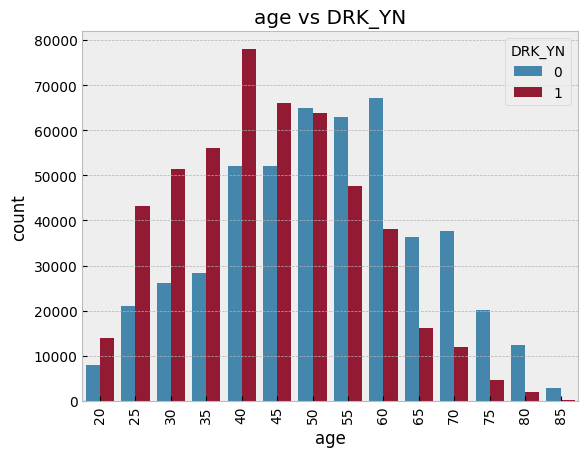

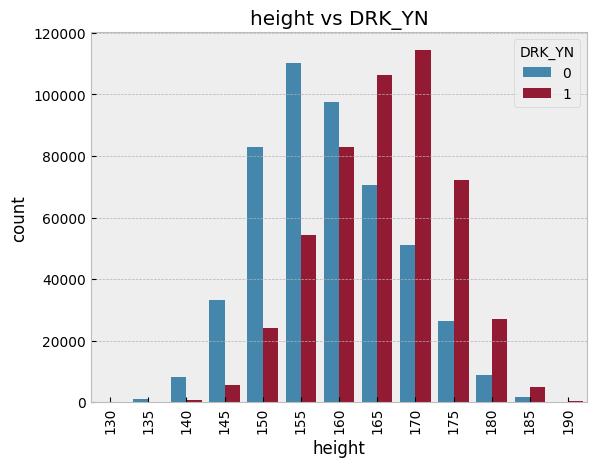

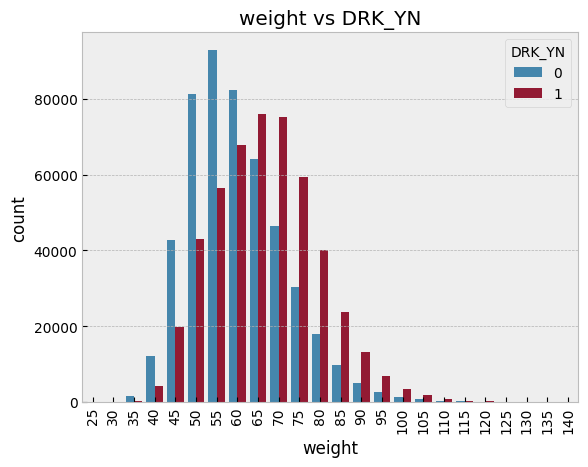

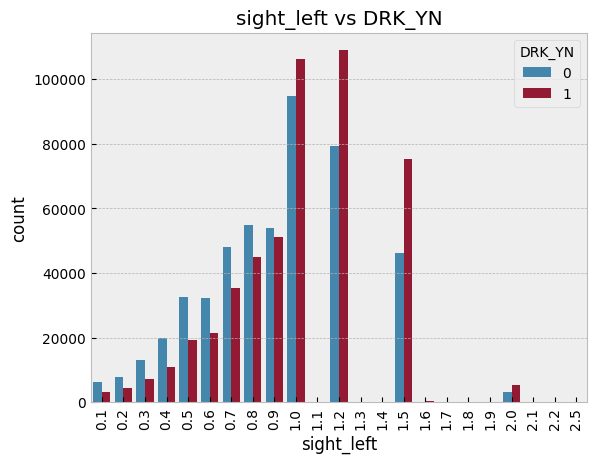

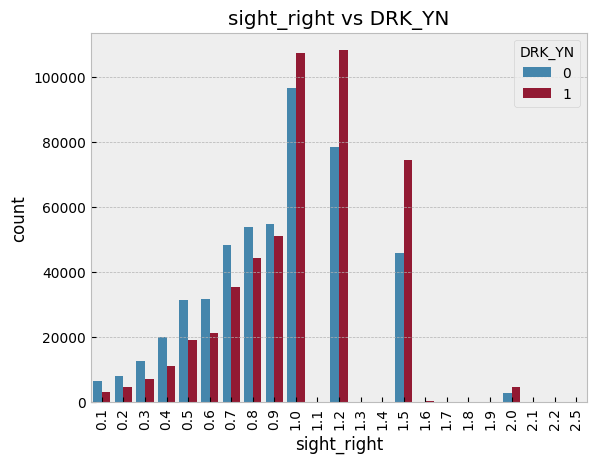

In [ ]:
for feature in discrete_feature:
    sns.color_palette("pastel")
    sns.countplot(x=feature, data=data, hue = 'DRK_YN')
    plt.title('{} vs DRK_YN'.format(feature))
    plt.xticks(rotation=90)
    plt.show()

Parece que algunas de las variables mostradas son de tipo categórico, donde las categorías se representan con valores numéricos. Esto es evidente en: 'hear_left', 'hear_right', 'urine_protein' y 'SMK_stat_type_cd'.

Además, es importante tener en cuenta que los valores de las variables 'age' y 'height' están redondeados hacia arriba a los múltiplos de 5, para años y centímetros respectivamente.

**Distribuciones:**

* **'age':** Observamos una tendencia normal con una mayor frecuencia de datos entre 50 y 60 años para no bebedores, mientras que para bebedores se observa un pico a los 40 años. Las distribuciones parecen desfasadas entre sí.
* **'height':** También notamos un desfase entre las distribuciones, donde la distribución para bebedores se encuentra desplazada hacia valores mayores en comparación con los no bebedores.
* **'weight':** Al igual que en el caso de 'height', la distribución para bebedores está desplazada hacia valores mayores en comparación con los no bebedores.

Algunas distribuciones son muy similares o incluso idénticas:

* **'sight_left'** y **'sight_right'**: Tanto para bebedores como para no bebedores, la forma de la distribución es creciente hasta llegar a 1.0, donde comienzan a omitirse valores y la cantidad desciende. La frecuencia de valores menores a 1.0 es mayor para no bebedores, mientras que es lo contrario para valores iguales o mayores a 1.0.
* Lo mismo sucede con: 'hear_left' y 'hear_right'.

Estas observaciones sugieren una posible simetría o correspondencia entre las variables 'sight_left' y 'sight_right', así como entre 'hear_left' y 'hear_right'.

### Variable continuas

In [ ]:
continuous_feature=[feature for feature in numerical_features if feature not in discrete_feature]
print("Continuous feature Count {}".format(len(continuous_feature)))

Continuous feature Count 13


In [ ]:
continuous_feature

['waistline',
 'SBP',
 'DBP',
 'BLDS',
 'tot_chole',
 'HDL_chole',
 'LDL_chole',
 'triglyceride',
 'hemoglobin',
 'serum_creatinine',
 'SGOT_AST',
 'SGOT_ALT',
 'gamma_GTP']

In [ ]:
data[continuous_feature].head()

,waistline,SBP,DBP,BLDS,tot_chole,HDL_chole,LDL_chole,triglyceride,hemoglobin,serum_creatinine,SGOT_AST,SGOT_ALT,gamma_GTP
0,90.0,120.0,80.0,99.0,193.0,48.0,126.0,92.0,17.1,1.0,21.0,35.0,40.0
1,89.0,130.0,82.0,106.0,228.0,55.0,148.0,121.0,15.8,0.9,20.0,36.0,27.0
2,91.0,120.0,70.0,98.0,136.0,41.0,74.0,104.0,15.8,0.9,47.0,32.0,68.0
3,91.0,145.0,87.0,95.0,201.0,76.0,104.0,106.0,17.6,1.1,29.0,34.0,18.0
4,80.0,138.0,82.0,101.0,199.0,61.0,117.0,104.0,13.8,0.8,19.0,12.0,25.0


## Outlier Checking

Visualicemos los gráficos de caja de cada variable para ver sus distribuciones y posibles datos outliers

In [1]:
r=4
c=4
i=1

fig = plt.figure(figsize = (12,10))

for feature in continuous_feature:
    plt.subplot(r,c,i)
    plt.xlabel(feature)
    sns.boxplot(data[feature])
    i = i + 1
plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

Vamos a proceder con la eliminación de valores atípicos en nuestros datos.

Implementaré un código diseñado para identificar y eliminar los valores atípicos presentes en nuestras variables continuas. Para cada columna que contiene este tipo de características, realizaremos el cálculo del rango intercuartílico (IQR), que consiste en la diferencia entre el tercer cuartil y el primer cuartil. Posteriormente, estableceremos límites superior e inferior basados en el IQR para definir cuáles puntos se considerarán outliers.

Cualquier punto que caiga fuera de estos límites será identificado y eliminado de nuestro conjunto de datos. Esta acción tiene como objetivo permitirnos trabajar con datos más robustos y ajustados, evitando así la influencia negativa que los valores extremos podrían tener en nuestro análisis. Este proceso contribuirá a una interpretación más precisa y confiable de nuestros resultados.

Tambien me parecio interesante guardar los datos eliminados del dataset con el que vamos a trabajar en un nuevo dataset llamado *'outlier_height_por_iqr'*

In [ ]:
dimension_data_anterior = data.shape[0]
dimension_data_anterior

985282

In [ ]:
outlier_height_por_iqr=pd.DataFrame()

for column in continuous_feature:
  iqr = data[column].quantile(0.75) - data[column].quantile(0.25) #3er cuartil - 1er cuartil
  limite_superior = data[column].quantile(0.75) + 1.5*iqr
  limite_inferior = data[column].quantile(0.25) - 1.5*iqr
  outlier_height_por_iqr = pd.concat([outlier_height_por_iqr, data[(data[column] > limite_superior) | (data[column]< limite_inferior)]])
  data = data.loc[(data[column] <= limite_superior) & (data[column] >= limite_inferior)]

In [ ]:
outlier_height_por_iqr.head()

,sex,age,height,weight,waistline,sight_left,sight_right,hear_left,hear_right,SBP,...,LDL_chole,triglyceride,hemoglobin,urine_protein,serum_creatinine,SGOT_AST,SGOT_ALT,gamma_GTP,SMK_stat_type_cd,DRK_YN
89,1,70,165,75,110.0,0.5,0.7,1.0,1.0,183.0,...,140.0,184.0,17.0,3.0,1.1,67.0,62.0,292.0,1,1
101,0,55,155,85,109.0,0.7,0.6,1.0,1.0,120.0,...,136.0,105.0,14.3,1.0,0.5,29.0,27.0,47.0,0,0
133,1,25,185,120,110.0,0.7,1.5,1.0,1.0,140.0,...,183.0,120.0,15.3,1.0,1.1,26.0,31.0,36.0,0,1
294,1,25,175,105,114.0,1.0,0.9,1.0,1.0,125.0,...,140.0,135.0,16.3,1.0,1.3,35.0,90.0,81.0,0,1
450,1,25,185,100,110.8,1.5,1.5,1.0,1.0,128.0,...,174.0,94.0,15.7,1.0,0.9,21.0,32.0,55.0,0,1


In [ ]:
outlier_dimension = outlier_height_por_iqr.shape[0]
data_dimension=data.shape[0]

In [ ]:
print("Dimensiones de los datos originales:")  # Imprime las dimensiones de los datos originales
print(data_dimension)  # Imprime las dimensiones de los datos originales
print("Dimensiones de los datos con valores atípicos:")  # Imprime las dimensiones de los datos con valores atípicos
print(outlier_dimension)  # Imprime las dimensiones de los datos con valores atípicos
print("Suma de las dimensiones de los datos originales y con valores atípicos:")  # Imprime la suma de las dimensiones de los datos originales y con valores atípicos
print(data_dimension + outlier_dimension)  # Imprime la suma de las dimensiones de los datos originales y con valores atípicos
print("Diferencia entre las dimensiones de los datos originales y con valores atípicos respecto a las dimensiones anteriores:")  # Imprime la diferencia entre las dimensiones de los datos originales y con valores atípicos respecto a las dimensiones anteriores
print(data_dimension + outlier_dimension - dimension_data_anterior)  # Imprime la diferencia entre las dimensiones de los datos originales y con valores atípicos respecto a las dimensiones anteriores


Dimensiones de los datos originales:
660913
Dimensiones de los datos con valores atípicos:
324369
Suma de las dimensiones de los datos originales y con valores atípicos:
985282
Diferencia entre las dimensiones de los datos originales y con valores atípicos respecto a las dimensiones anteriores:
0


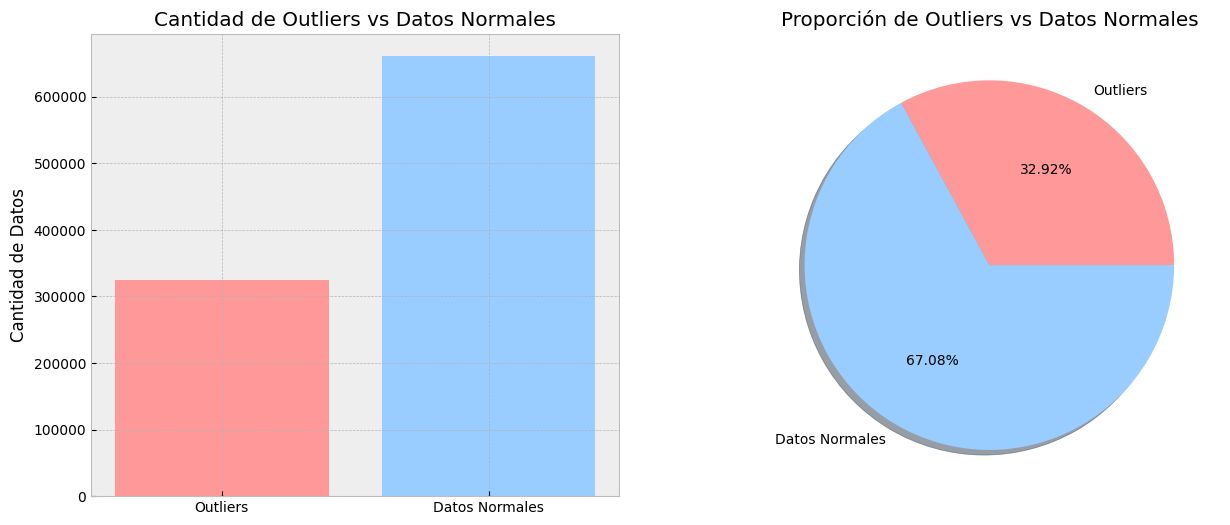

In [ ]:
# Colores más suaves
bar_colors = ['#FF9999', '#99CCFF']  # Tonos pastel de rojo y azul
pie_colors = ['#FF9999', '#99CCFF']  # Tonos pastel de rojo y azul

# Gráfico de barras
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
plt.bar(x=['Outliers', 'Datos Normales'], height=[outlier_dimension, data_dimension], color=bar_colors)
plt.title('Cantidad de Outliers vs Datos Normales')
plt.ylabel('Cantidad de Datos')

# Gráfico circular (pie chart)
plt.subplot(1, 2, 2)
labels = ['Outliers', 'Datos Normales']
sizes = [outlier_dimension, data_dimension]
plt.pie(sizes, labels=labels, autopct='%1.2f%%', colors=pie_colors, shadow=True)
plt.title('Proporción de Outliers vs Datos Normales')

plt.show()

Vemos que tras eliminar los valores considerados outliers la cantidad de valores se redujo considerablemente. El 32.92% de los datos son considerados outliers.

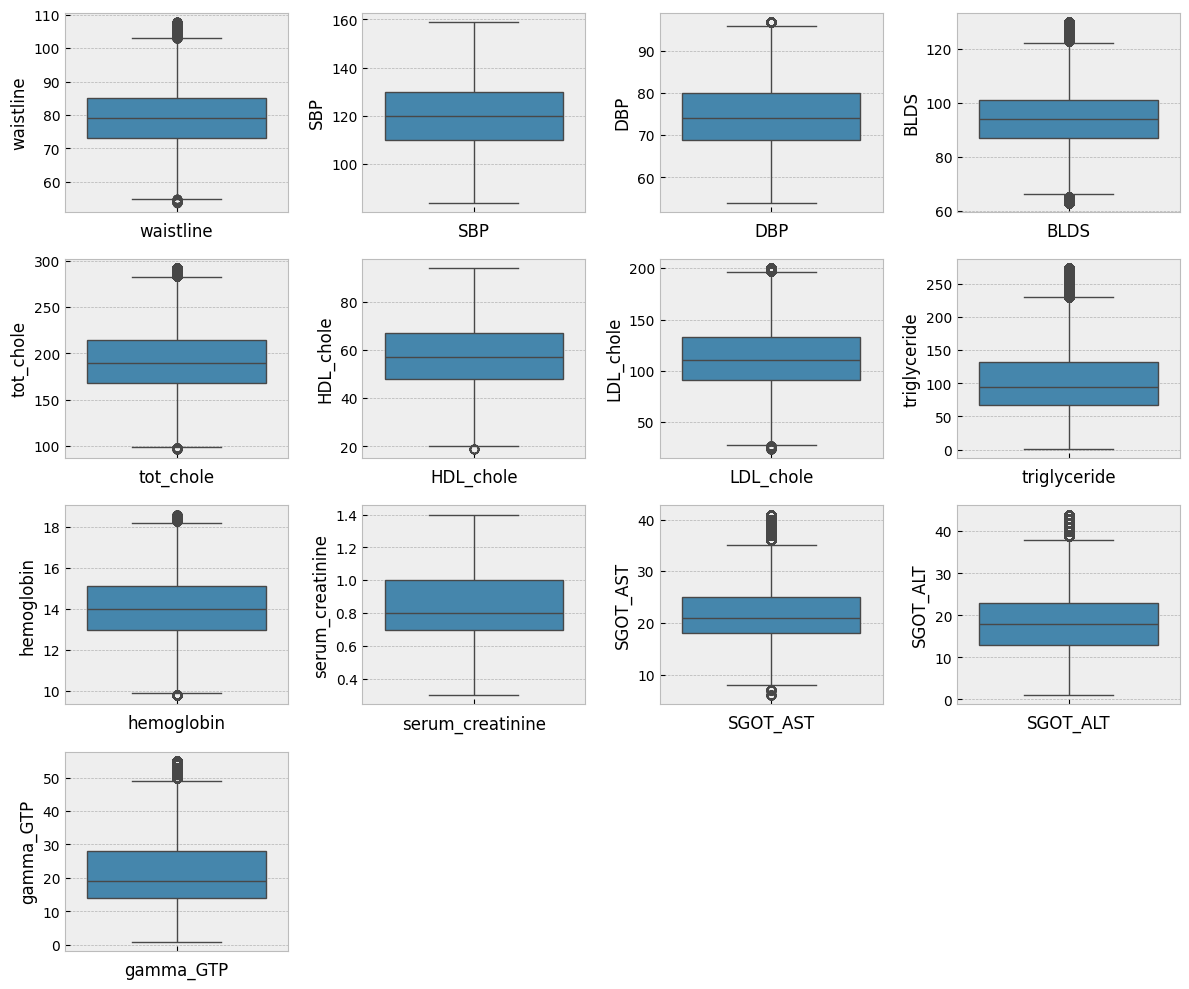

In [ ]:
c=4
i=1

fig = plt.figure(figsize = (12,10))

for feature in continuous_feature:
    plt.subplot(r,c,i)
    plt.xlabel(feature)
    sns.boxplot(data[feature])
    i = i + 1
plt.tight_layout()
plt.show()

## Analisis Exploratorio bivariado con DRK_YN como Variable objetivo

Realizamos un Analisis Exploratorio bivariado, para visualizar la relación entre las variables numéricas continuas con la variable objetivo: bebedor. 0 representa que no es bebedor y 1 que es bebedor

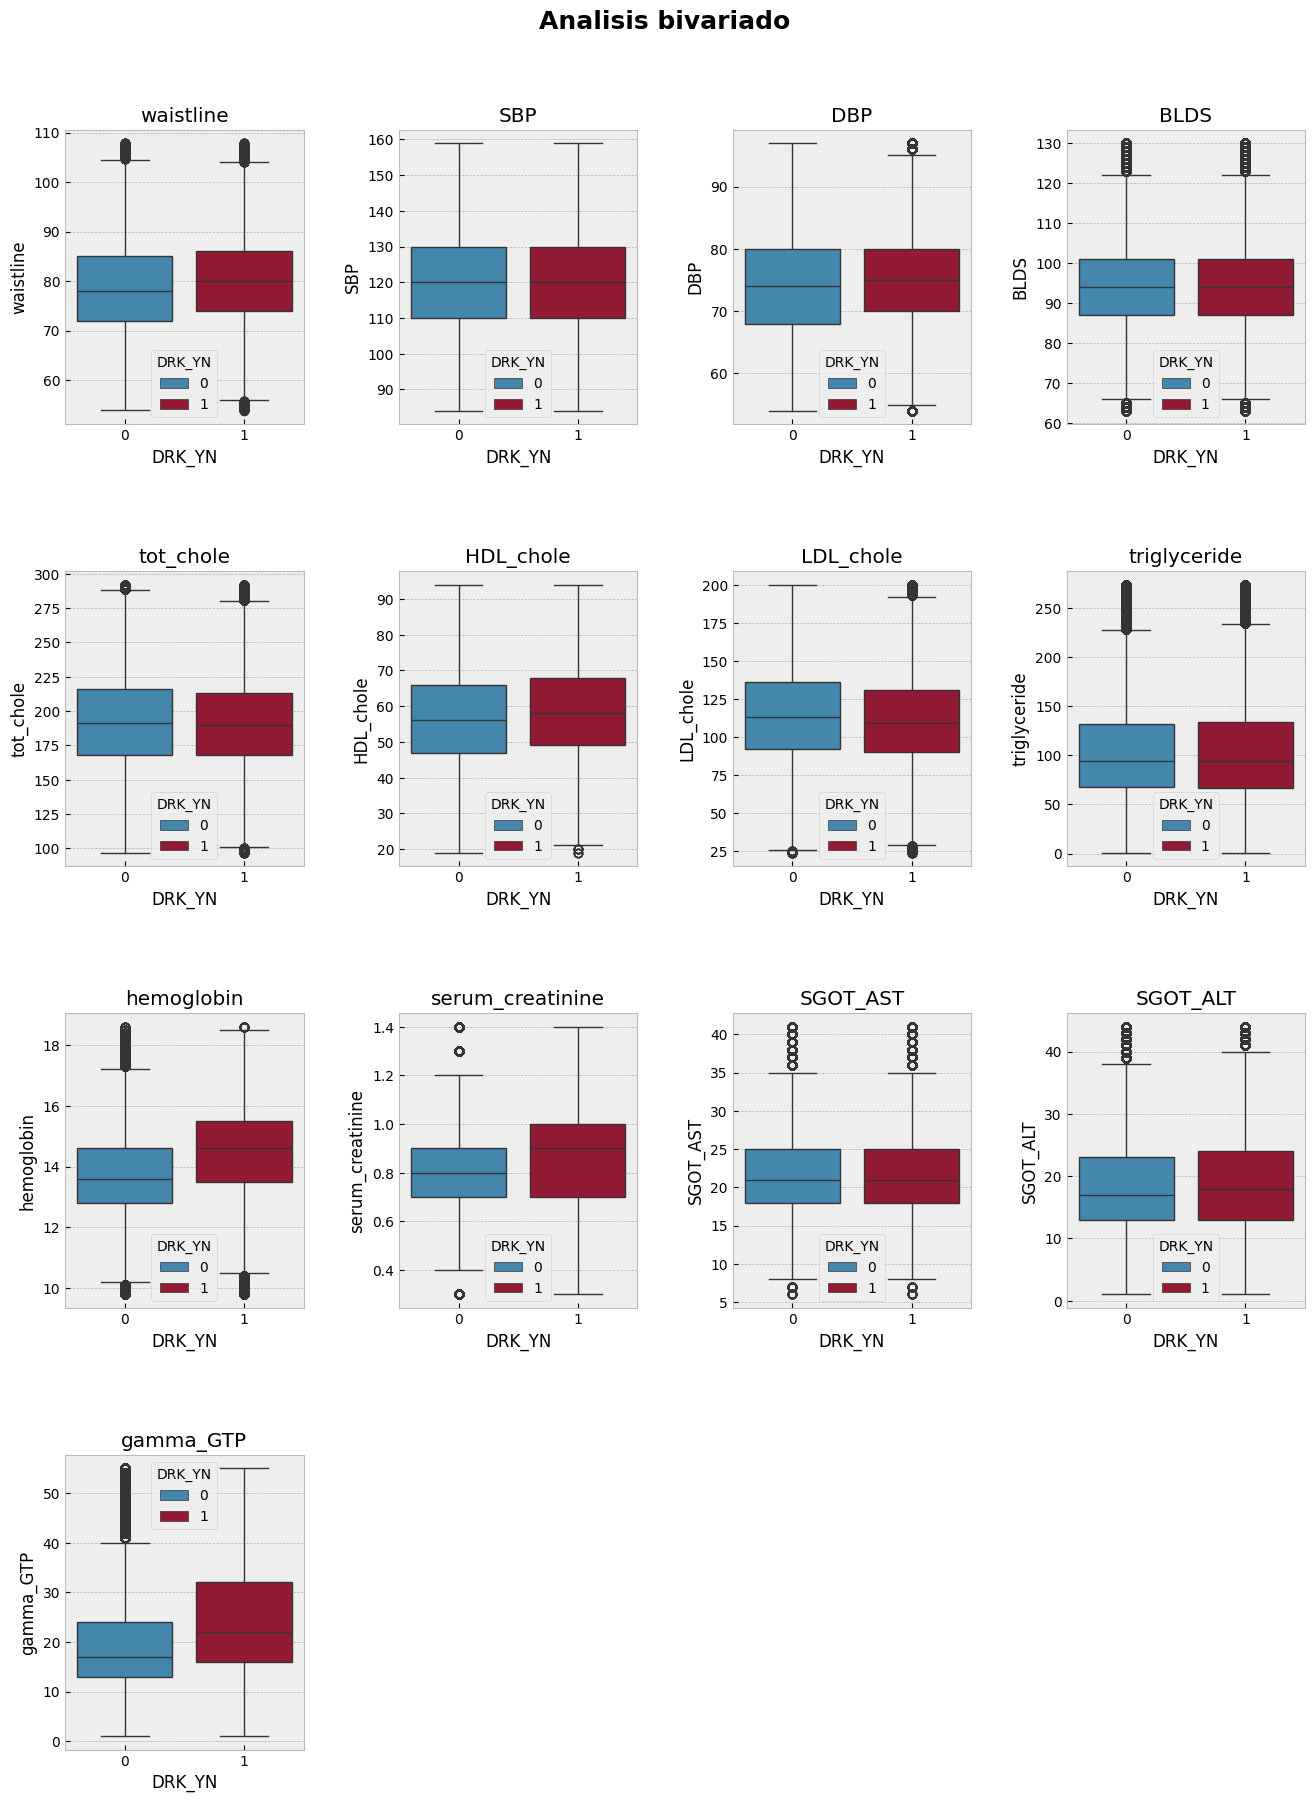

In [ ]:
fig = plt.figure(figsize=[16,20])
fig.suptitle('Analisis bivariado', fontsize=18, fontweight='bold')
fig.subplots_adjust(top=0.92);
fig.subplots_adjust(hspace=0.5, wspace=0.4);
for i ,col in enumerate(continuous_feature):
    a = fig.add_subplot(4,4, i+1)
    a=sns.boxplot(x = 'DRK_YN' , y =col , hue= 'DRK_YN' , ax=a  , data = data )
    a.set_title(col)

In [ ]:
data.columns

Index(['sex', 'age', 'height', 'weight', 'waistline', 'sight_left',
       'sight_right', 'hear_left', 'hear_right', 'SBP', 'DBP', 'BLDS',
       'tot_chole', 'HDL_chole', 'LDL_chole', 'triglyceride', 'hemoglobin',
       'urine_protein', 'serum_creatinine', 'SGOT_AST', 'SGOT_ALT',
       'gamma_GTP', 'SMK_stat_type_cd', 'DRK_YN'],
      dtype='object')

* Vemos que las distribuciones de algunas variables son muy similares tanto para DRK_YN igual 0 como para 1.
  * Es el caso de las varibles: **' SBP '**, **' BLDS '**, **' tot_chole '**, **' HDL_chole '**, **' triglyceride '**, **' SGOT_AST '**, **' SGOT_ALT '**.
* El caso de **' hemoglobin '**, **' serum_creatinine '**, **' gamma_GTP '** vemos que en los 3 casos las distribuciones para los bebedores estan desplazadas hacia valores mayores respecto de las distribuciones de los no bebedores.


Para complementar los gráficos anteriores visualicemos los histogramas respectivos

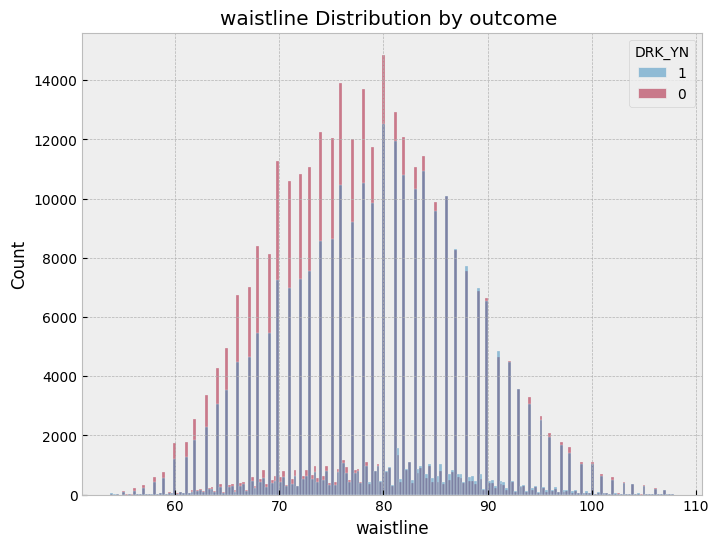

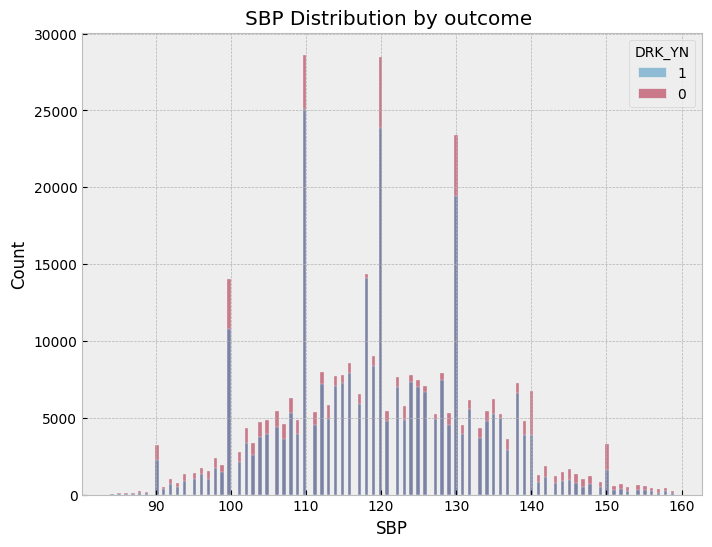

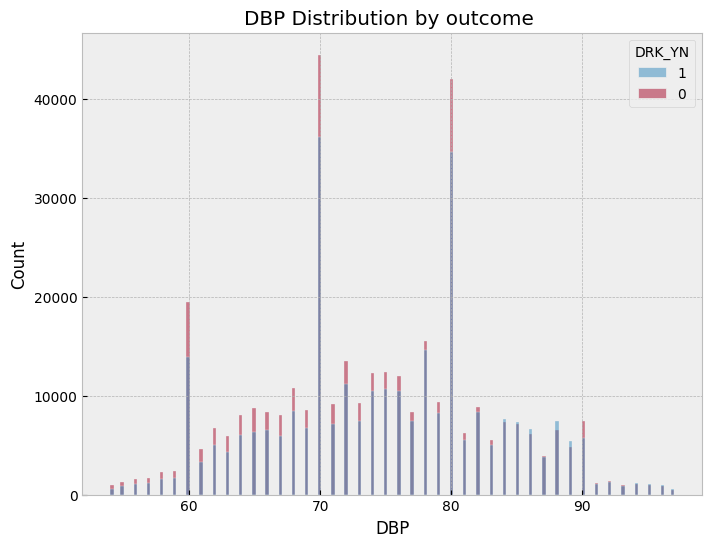

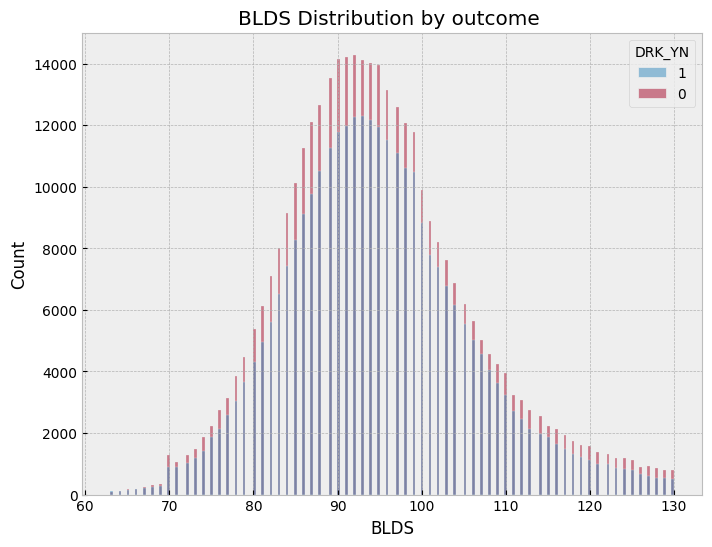

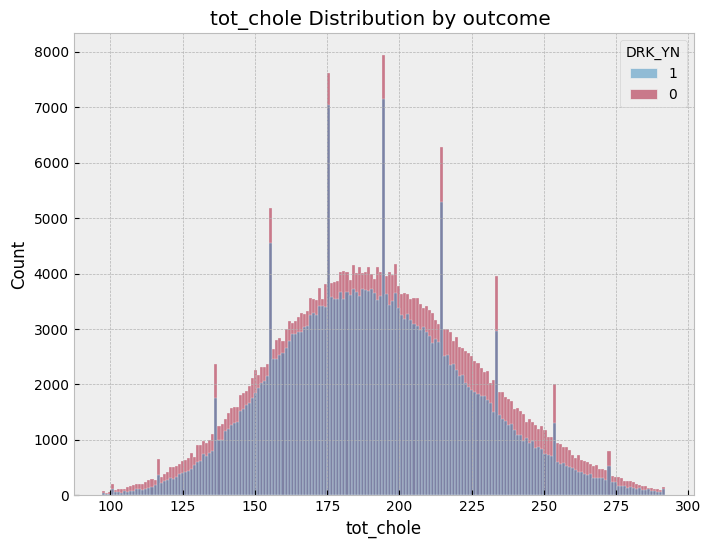

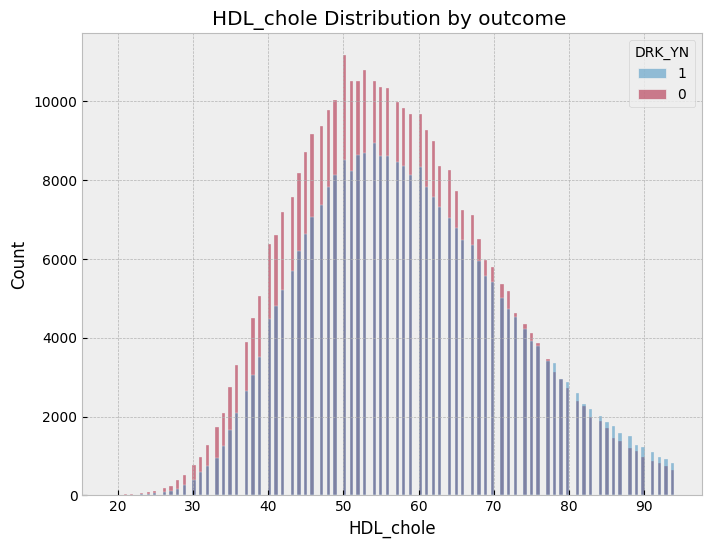

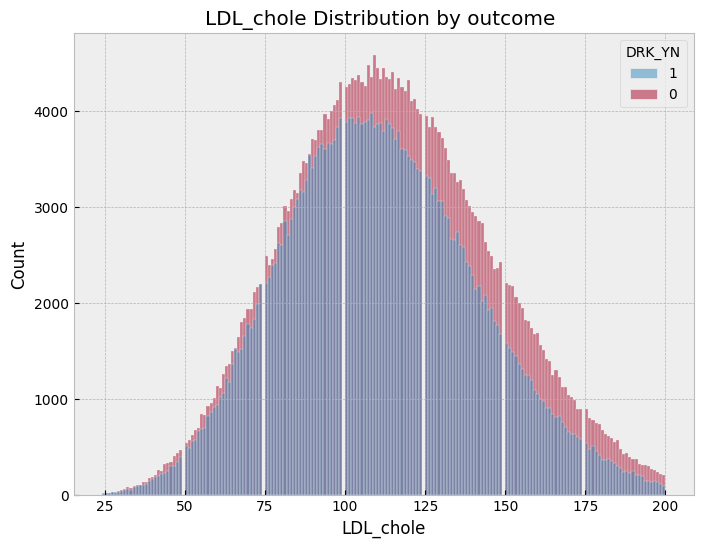

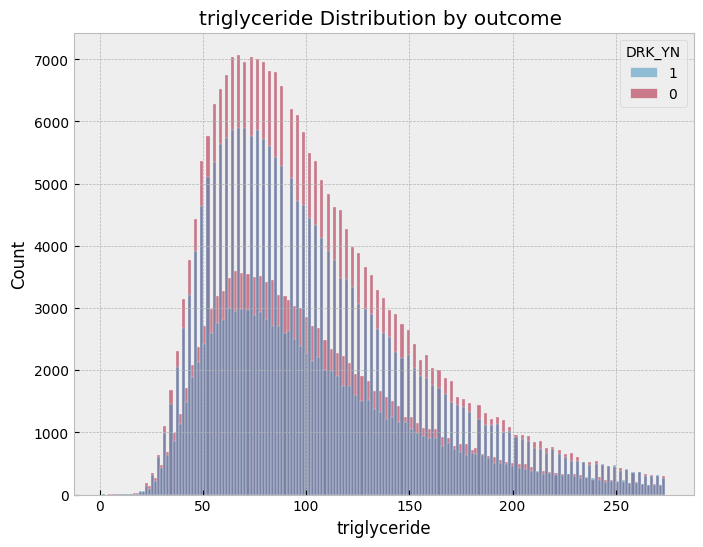

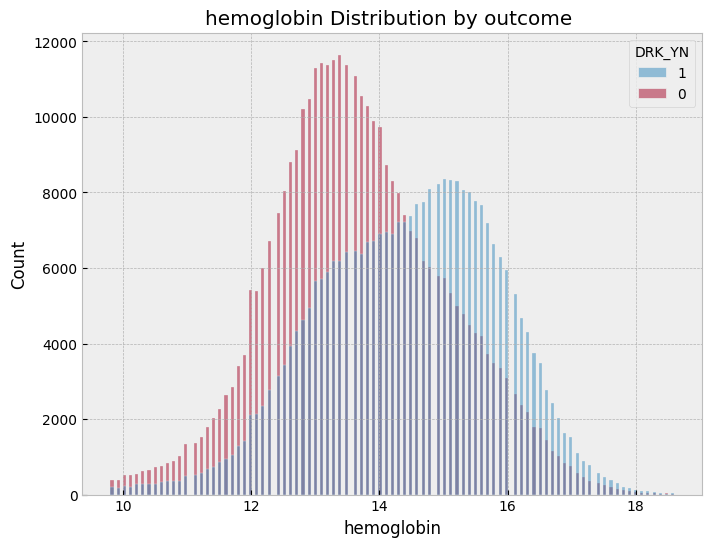

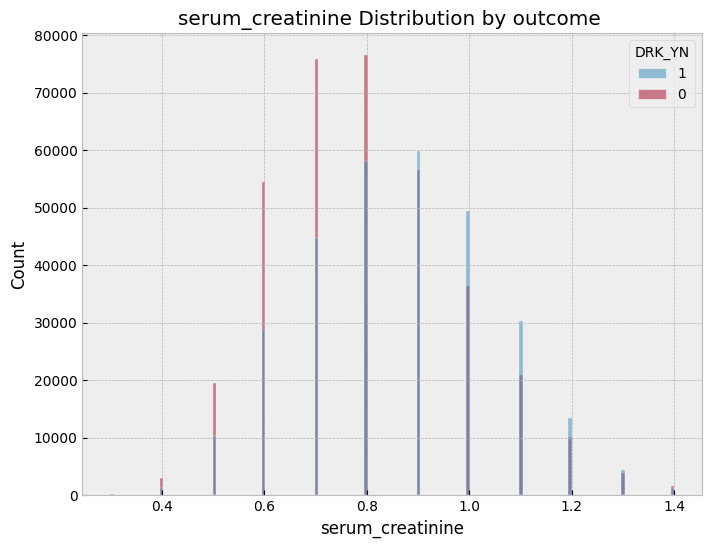

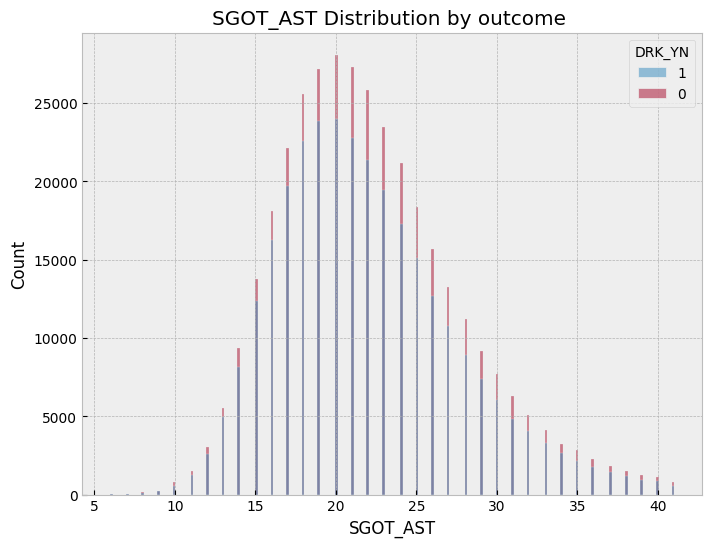

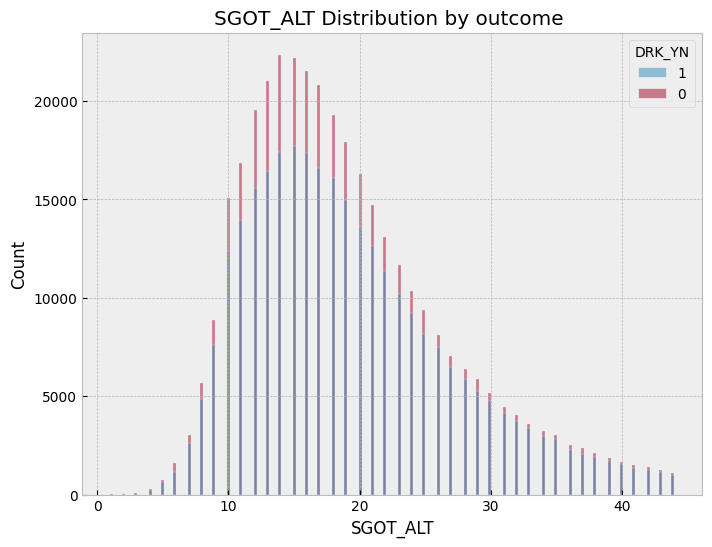

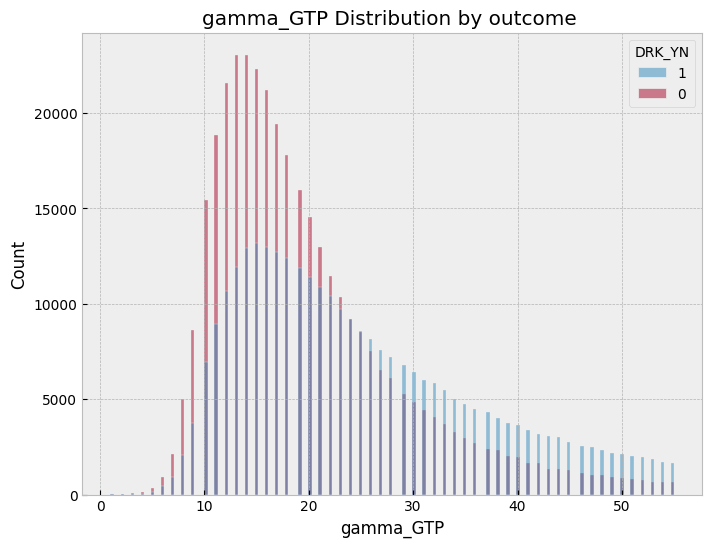

In [ ]:
#custom_cmap = sns.color_palette("dark", as_cmap=True)

fig_size = (8, 6)

for feature in continuous_feature:
    plt.figure(figsize=fig_size)
    sns.histplot(data=data, x=feature, hue='DRK_YN', hue_order=[1, 0], alpha=0.5)
    plt.xlabel(feature)
    plt.ylabel("Count")
    plt.title('{} Distribution by outcome '.format(feature))
    plt.show()

Como habiamos mencionado antes, podemos visualizar que ....

## 'SMK_stat_type_cd'

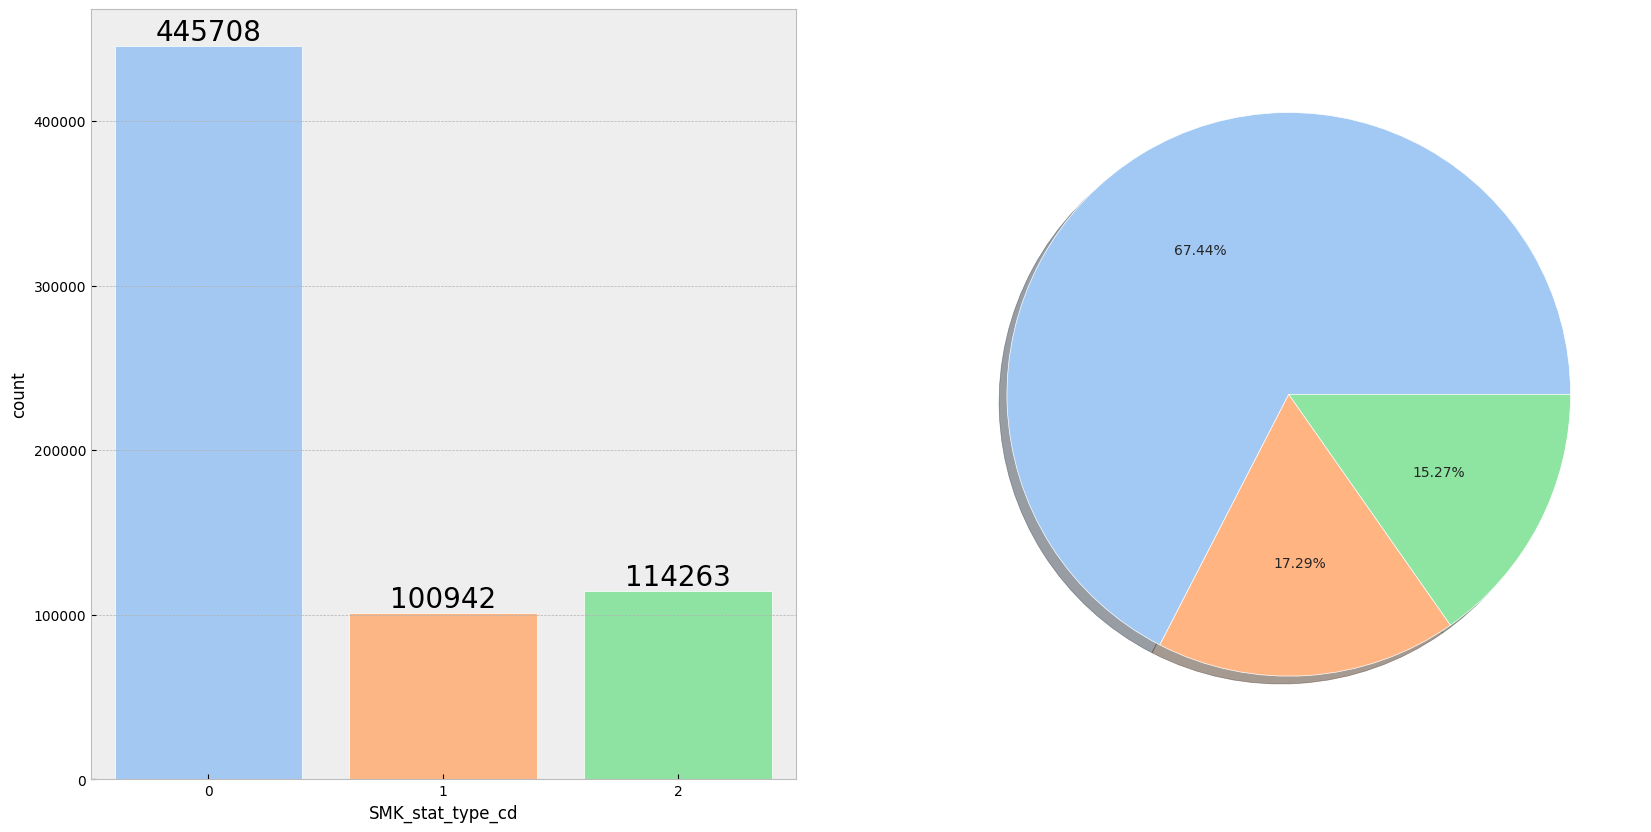

In [ ]:
f, ax = plt.subplots(1, 2, figsize=(20, 10))
sns.set_style('ticks')

# Definir la paleta de colores
colors = sns.color_palette('pastel', len(data['SMK_stat_type_cd'].unique()))

# Gráfico de barras
sns.countplot(x='SMK_stat_type_cd', data=data, palette=colors, saturation=.95, ax=ax[0])
for container in ax[0].containers:
    ax[0].bar_label(container, color='black', size=20)

# Gráfico circular (pie chart)
ax[1].pie(x=data['SMK_stat_type_cd'].value_counts(), autopct='%1.2f%%', colors=colors, shadow=True)

plt.show()

Vemos que la variable 'SMK_stat_type_cd' hay un predominio de casos 0, es decir , aproximadamente 4 veces más que en los casos de 1 y 2.
Recordemos que 'SMK_stat_type_cd' hace referencia a Estado fumador, 0(nunca), 1(solia fumar pero dejo), 2(todavia fuma)

## 'DRK_YN'

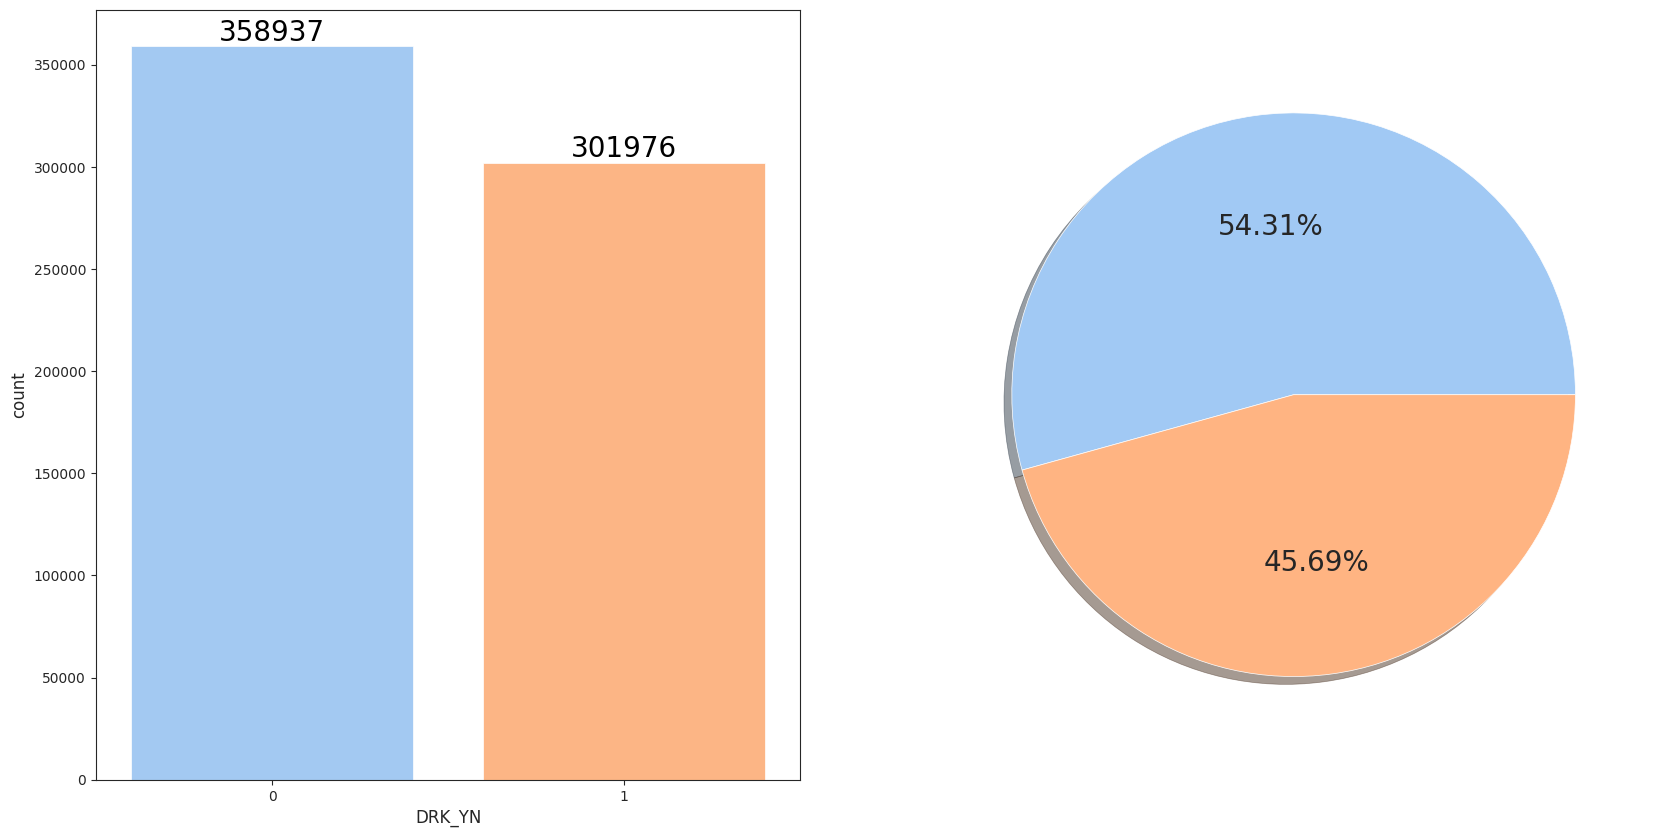

In [ ]:
f, ax = plt.subplots(1, 2, figsize=(20, 10))
sns.set_style('ticks')

# Definir la paleta de colores
colors = sns.color_palette('pastel', len(data['DRK_YN'].unique()))

# Gráfico de barras
sns.countplot(x='DRK_YN', data=data, palette=colors, saturation=.95, ax=ax[0])
for container in ax[0].containers:
    ax[0].bar_label(container, color='black', size=20)

# Gráfico circular (pie chart)
ax[1].pie(x=data['DRK_YN'].value_counts(), autopct='%1.2f%%', colors=colors, shadow=True, textprops={'fontsize': 20})

plt.show()

##**Observaciones**

Observamos que la cantidad de casos de no bebedores es 5% mayor que los casos de bebedores

# ¿Que variables están correlacionadas?

Realizamos la Matriz de correlacion

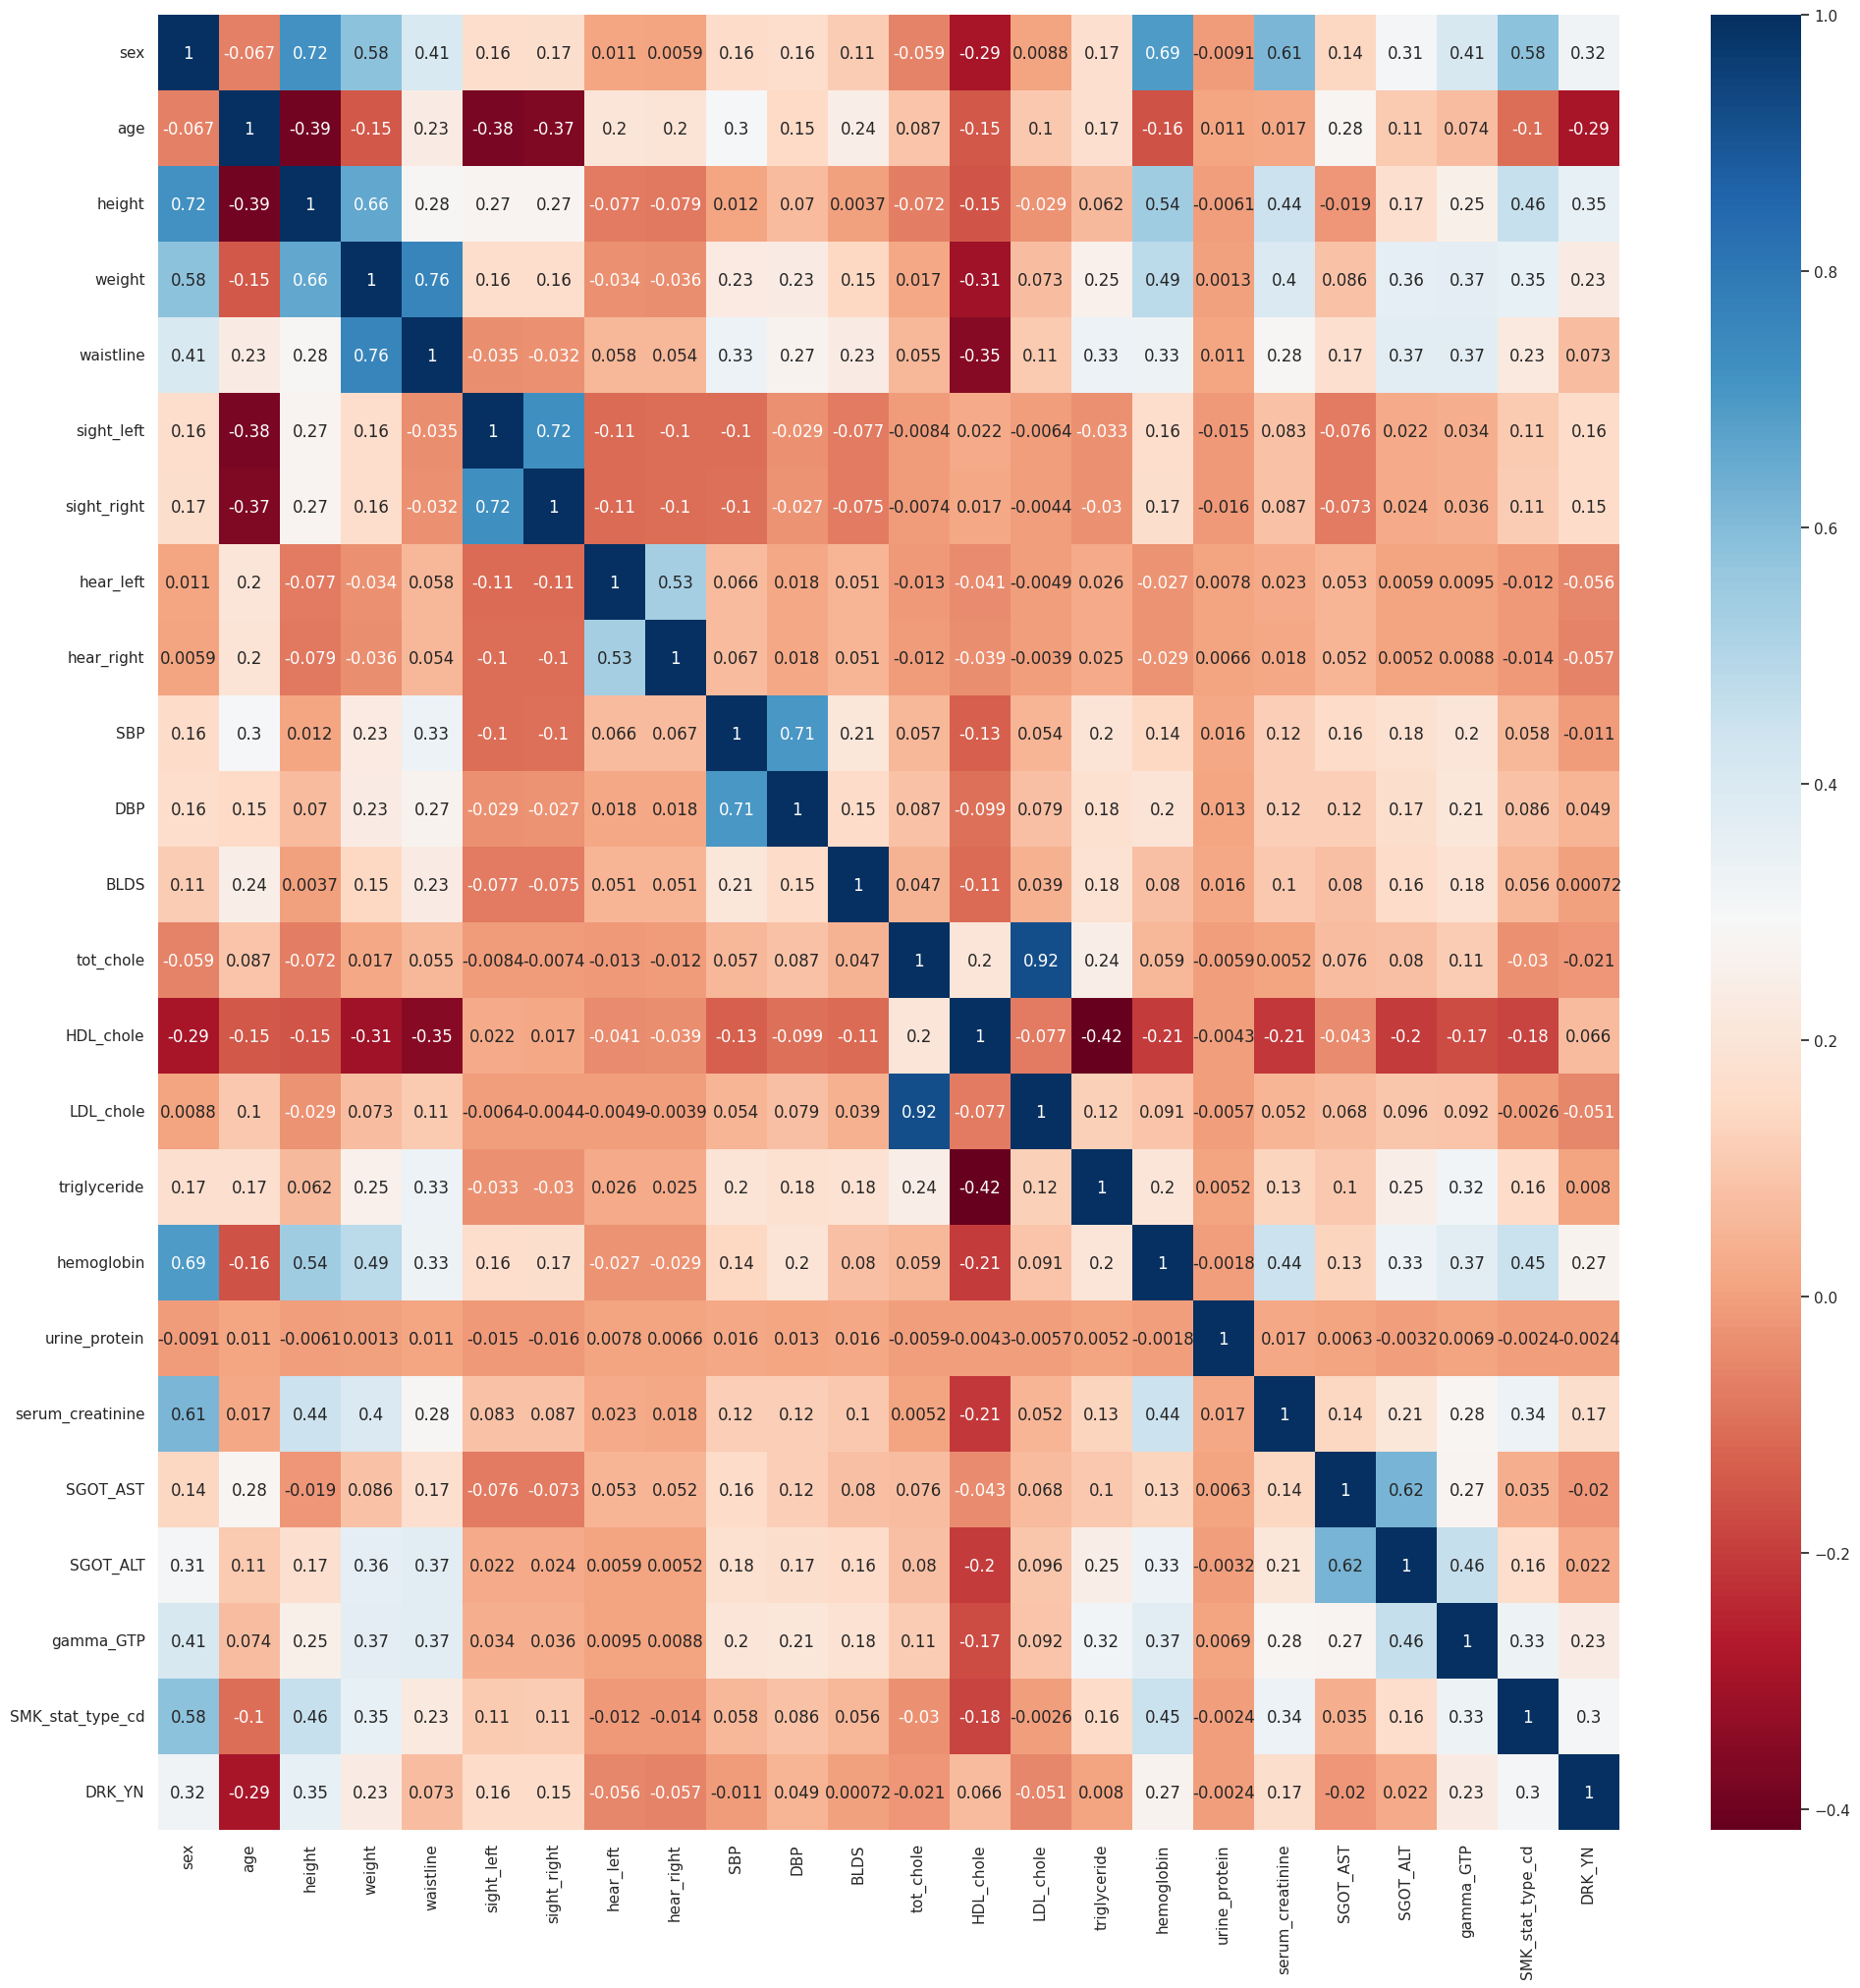

In [ ]:
def high_correlated_cols(dataframe, plot=False, corr_th=0.90):
    """
    Identify columns in a DataFrame with high correlation to each other.

    Args:
        dataframe (pd.DataFrame): The DataFrame containing the data.
        plot (bool, optional): Whether to plot the correlation matrix. Default is False.
        corr_th (float, optional): The correlation threshold above which columns are considered highly correlated. Default is 0.90.

    Returns:
        list: A list of column names that are highly correlated.
    """
    corr = dataframe.corr()
    cor_matrix = corr.abs()
    upper_triangle_matrix = cor_matrix.where(np.triu(np.ones(cor_matrix.shape), k=1).astype(bool))
    drop_list = [col for col in upper_triangle_matrix.columns if any(upper_triangle_matrix[col] > corr_th)]
    if plot:
        import seaborn as sns
        import matplotlib.pyplot as plt
        sns.set(rc={'figure.figsize': (24, 24)})
        sns.heatmap(corr, cmap="RdBu", annot=True)
        plt.show(block=True)
    return drop_list

high_corr_cols = high_correlated_cols(data, True)

In [ ]:
corr = data.corr()

In [ ]:
print(corr[['DBP','BLDS','tot_chole','HDL_chole']].describe())

             DBP       BLDS  tot_chole  HDL_chole
count  24.000000  24.000000  24.000000  24.000000
mean    0.163836   0.120061   0.117495  -0.078463
std     0.234455   0.210507   0.270231   0.268937
min    -0.099366  -0.110742  -0.071708  -0.416009
25%     0.041578   0.033439  -0.009213  -0.204742
50%     0.119237   0.079718   0.051019  -0.119802
75%     0.185042   0.162721   0.087374  -0.030227
max     1.000000   1.000000   1.000000   1.000000


In [ ]:
import pandas as pd
import numpy as np

def high_correlated_cols(dataframe, n=10, corr_th=0.60):
    """
    Identify columns in a DataFrame with high correlation to each other.

    Args:
        dataframe (pd.DataFrame): The DataFrame containing the data.
        n (int, optional): Number of top correlated pairs to return. Default is 10.
        corr_th (float, optional): The correlation threshold above which columns are considered highly correlated. Default is 0.90.

    Returns:
        pd.DataFrame: A DataFrame with the top correlated pairs sorted by correlation value.
    """
    corr = dataframe.corr().abs()
    upper_triangle_matrix = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    correlated_pairs = (upper_triangle_matrix
                        .stack()
                        .sort_values(ascending=False)
                        .reset_index())
    correlated_pairs.columns = ['Variable 1', 'Variable 2', 'Correlation']
    correlated_pairs = correlated_pairs[correlated_pairs['Correlation'] > corr_th]
    return correlated_pairs.head(n)

high_corr_table = (high_correlated_cols(data))
print(high_corr_table)


   Variable 1        Variable 2  Correlation
0   tot_chole         LDL_chole     0.921157
1      weight         waistline     0.756922
2  sight_left       sight_right     0.723683
3         sex            height     0.719692
4         SBP               DBP     0.705437
5         sex        hemoglobin     0.692051
6      height            weight     0.660370
7    SGOT_AST          SGOT_ALT     0.623373
8         sex  serum_creatinine     0.613129


# 3.  ¿Que variables son más importantes para predecir si un nuevo caso es bebedor o no?

Vamos a elegir un método de feature selection para reducir la dimensionalidad del dataset

Vemos algunos de los métodos para reducir la dimensionalidad.
Los metodos que veremos son:
1. Forward Selection
2. Backward elimination

In [ ]:
data.columns

Index(['sex', 'age', 'height', 'weight', 'waistline', 'sight_left',
       'sight_right', 'hear_left', 'hear_right', 'SBP', 'DBP', 'BLDS',
       'tot_chole', 'HDL_chole', 'LDL_chole', 'triglyceride', 'hemoglobin',
       'urine_protein', 'serum_creatinine', 'SGOT_AST', 'SGOT_ALT',
       'gamma_GTP', 'SMK_stat_type_cd', 'DRK_YN'],
      dtype='object')

In [ ]:
X = data.drop("DRK_YN", axis=1)       # feature matrix
y = data['DRK_YN']               # target feature
data.head()

,sex,age,height,weight,waistline,sight_left,sight_right,hear_left,hear_right,SBP,...,LDL_chole,triglyceride,hemoglobin,urine_protein,serum_creatinine,SGOT_AST,SGOT_ALT,gamma_GTP,SMK_stat_type_cd,DRK_YN
0,1,35,170,75,90.0,1.0,1.0,1.0,1.0,120.0,...,126.0,92.0,17.1,1.0,1.0,21.0,35.0,40.0,0,1
1,1,30,180,80,89.0,0.9,1.2,1.0,1.0,130.0,...,148.0,121.0,15.8,1.0,0.9,20.0,36.0,27.0,2,0
3,1,50,175,80,91.0,1.5,1.2,1.0,1.0,145.0,...,104.0,106.0,17.6,1.0,1.1,29.0,34.0,18.0,0,0
4,1,50,165,60,80.0,1.0,1.2,1.0,1.0,138.0,...,117.0,104.0,13.8,1.0,0.8,19.0,12.0,25.0,0,0
5,1,50,165,55,75.0,1.2,1.5,1.0,1.0,142.0,...,95.0,232.0,13.8,3.0,0.8,29.0,40.0,37.0,2,1


In [ ]:
X.shape

(660913, 23)

In [ ]:
y.shape

(660913,)

## Forward selection

In [ ]:
import statsmodels.api as sm
def forward_selection(data, target, significance_level=0.01):
    initial_features = data.columns.tolist()
    best_features = []
    while (len(initial_features)>0):
        remaining_features = list(set(initial_features)-set(best_features))
        new_pval = pd.Series(index=remaining_features)
        for new_column in remaining_features:
            model = sm.OLS(target, sm.add_constant(data[best_features+[new_column]])).fit()
            new_pval[new_column] = model.pvalues[new_column]
        min_p_value = new_pval.min()
        if(min_p_value<significance_level):
            best_features.append(new_pval.idxmin())
        else:
            break
    return best_features

Esta función anterior acepta datos, variable objetivo y nivel de significancia como argumentos y devuelve la lista final de características significativas basadas en valores p a través de la selección hacia adelante.

In [ ]:
forward_selection(X,y)

['hemoglobin',
 'weight',
 'HDL_chole',
 'tot_chole',
 'SGOT_AST',
 'height',
 'age',
 'LDL_chole',
 'gamma_GTP',
 'sex',
 'SGOT_ALT',
 'SMK_stat_type_cd',
 'DBP',
 'BLDS',
 'serum_creatinine',
 'triglyceride',
 'SBP',
 'waistline',
 'sight_left']

Vemos que las variables que considerq más relevante son : *'height',
 'HDL_chole',
 'gamma_GTP',
 'tot_chole',
 'sex',
 'age',
 'SMK_stat_type_cd',
 'SGOT_ALT',
 'SGOT_AST',
 'DBP',
 'BLDS',
 'waistline',
 'serum_creatinine',
 'triglyceride',
 'LDL_chole',
 'SBP',
 'weight',
 'hemoglobin',
 'sight_left'*

### Implementacion usando funciones de Python

In [ ]:
!pip install mlxtend

In [ ]:
import sys
import joblib
sys.modules['sklearn.externals.joblib'] = joblib

In [ ]:
#Librerias
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn.linear_model import LinearRegression
# Sequential Forward Selection(sfs)
sfs = SFS(LinearRegression(),
          k_features=11,
          forward=True,
          floating=False,
          scoring = 'r2',
          cv = 0)

La función SequentialFeatureSelector() acepta los siguientes argumentos principales:

* LinearRegression() es un estimador de todo el proceso. Del mismo modo, puede ser cualquier algoritmo basado en clasificación.

* k_features indica el número de características que se seleccionarán. Puede ser cualquier valor aleatorio, pero el valor óptimo se puede encontrar analizando y visualizando las puntuaciones para diferentes números de características.

* argumentos hacia adelante y flotantes forward = Verdadero y floating = Falso son para la técnica de selección hacia adelante.

* El argumento de puntuación especifica el criterio de evaluación que se utilizará. Para problemas de regresión, solo hay una puntuación $r^2$ en la implementación predeterminada. De manera similar, para la clasificación, puede ser exactitud, precisión, recuperación, puntaje f1, etc.

* El argumento cv es para la validación cruzada usando k-fold.

In [ ]:
sfs.fit(X, y)
sfs.k_feature_names_     #Lista final de features

('sex',
 'age',
 'height',
 'DBP',
 'BLDS',
 'HDL_chole',
 'LDL_chole',
 'SGOT_AST',
 'SGOT_ALT',
 'gamma_GTP',
 'SMK_stat_type_cd')

En este caso la cantidad de variables se vio reducida a: 'sex',
 'age',
 'height',
 'DBP',
 'BLDS',
 'HDL_chole',
 'LDL_chole',
 'SGOT_AST',
 'SGOT_ALT',
 'gamma_GTP',
 'SMK_stat_type_cd'

## Backward selection

In [ ]:
def backward_elimination(data, target,significance_level = 0.05):
    features = data.columns.tolist()
    while(len(features)>0):
        features_with_constant = sm.add_constant(data[features])
        p_values = sm.OLS(target, features_with_constant).fit().pvalues[1:]
        max_p_value = p_values.max()
        if(max_p_value >= significance_level):
            excluded_feature = p_values.idxmax()
            features.remove(excluded_feature)
        else:
            break
    return features

In [ ]:
backward_elimination(X,y)

['sex',
 'age',
 'height',
 'weight',
 'waistline',
 'sight_left',
 'hear_right',
 'SBP',
 'DBP',
 'BLDS',
 'tot_chole',
 'HDL_chole',
 'LDL_chole',
 'triglyceride',
 'hemoglobin',
 'serum_creatinine',
 'SGOT_AST',
 'SGOT_ALT',
 'gamma_GTP',
 'SMK_stat_type_cd']

# Guardamos nuestro nuevo dataset
Luego de todas las modificaciones realizadas, guardamos y exportamos nuestro dataset en un nuevo archivo

In [ ]:
ruta_archivo_csv = '/content/drive/MyDrive/Entrega_Final/dataset_preprocesado.csv'

# Exporta el DataFrame a un archivo CSV
data.to_csv(ruta_archivo_csv, index=False)

print("¡El dataset preprocesado ha sido exportado exitosamente como CSV!")

¡El dataset preprocesado ha sido exportado exitosamente como CSV!


# 4- Ingenieria de Atributos


En esta sección dedicada a la Ingeniería de Atributos, se llevaron a cabo una serie de procesos fundamentales para mejorar la calidad y la relevancia de los datos utilizados en nuestro análisis. En primer lugar, se importaron los datos preprocesados de la etapa inicial, lo que nos permitió trabajar con información ya tratada y lista para su posterior manipulación.

Posteriormente, se procedió a la separación de las variables en dos grupos distintos: aquellas que requerían escalado y aquellas destinadas al proceso de encoding. Esta segmentación nos facilitó la aplicación de las técnicas adecuadas a cada tipo de variable, optimizando así el tratamiento de los datos y preparándolos para su inclusión en los modelos de aprendizaje automático.

Finalmente, se llevó a cabo la reestructuración del dataset final, integrando de manera coherente y organizada las variables escaladas y codificadas, lo que resultó en un conjunto de datos completo y listo para ser utilizado en las etapas subsiguientes de nuestro análisis. Estas acciones en el proceso de Ingeniería de Atributos son fundamentales para garantizar la calidad y la eficacia de nuestros modelos predictivos.

In [ ]:
url = '/content/drive/MyDrive/Entrega_Final/dataset_preprocesado.csv'
df = pd.read_csv(url)
df

,sex,age,height,weight,waistline,sight_left,sight_right,hear_left,hear_right,SBP,...,LDL_chole,triglyceride,hemoglobin,urine_protein,serum_creatinine,SGOT_AST,SGOT_ALT,gamma_GTP,SMK_stat_type_cd,DRK_YN
0,1,35,170,75,90.0,1.0,1.0,1.0,1.0,120.0,...,126.0,92.0,17.1,1.0,1.0,21.0,35.0,40.0,0,1
1,1,30,180,80,89.0,0.9,1.2,1.0,1.0,130.0,...,148.0,121.0,15.8,1.0,0.9,20.0,36.0,27.0,2,0
2,1,50,175,80,91.0,1.5,1.2,1.0,1.0,145.0,...,104.0,106.0,17.6,1.0,1.1,29.0,34.0,18.0,0,0
3,1,50,165,60,80.0,1.0,1.2,1.0,1.0,138.0,...,117.0,104.0,13.8,1.0,0.8,19.0,12.0,25.0,0,0
4,1,50,165,55,75.0,1.2,1.5,1.0,1.0,142.0,...,95.0,232.0,13.8,3.0,0.8,29.0,40.0,37.0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
660908,0,50,150,50,72.6,1.0,1.0,1.0,1.0,116.0,...,105.0,125.0,15.2,1.0,0.8,28.0,26.0,29.0,0,0
660909,1,45,175,80,92.1,1.5,1.5,1.0,1.0,114.0,...,125.0,132.0,15.0,1.0,1.0,26.0,36.0,27.0,0,0
660910,1,35,170,75,86.0,1.0,1.5,1.0,1.0,119.0,...,84.0,45.0,15.8,1.0,1.1,14.0,17.0,15.0,0,0
660911,1,25,175,60,72.0,1.5,1.0,1.0,1.0,119.0,...,73.0,53.0,14.5,1.0,0.8,21.0,14.0,17.0,0,0


In [ ]:
# Restablecer el índice del DataFrame y eliminar el índice anterior
df.reset_index(drop=True, inplace=True)

In [ ]:
numerical_features =['age', 'height', 'weight', 'waistline', 'sight_left', 'sight_right',
                     'SBP', 'DBP', 'BLDS', 'tot_chole', 'HDL_chole', 'LDL_chole', 'triglyceride',
                     'hemoglobin', 'serum_creatinine', 'SGOT_AST', 'SGOT_ALT', 'gamma_GTP']

In [ ]:
variables_a_eliminar = ['urine_protein', 'SMK_stat_type_cd', 'sex', 'hear_left', 'hear_right','DRK_YN']

numerical_features = [var for var in numerical_features if var not in variables_a_eliminar]

var_scale = numerical_features

In [ ]:
var_scale

['age',
 'height',
 'weight',
 'waistline',
 'sight_left',
 'sight_right',
 'SBP',
 'DBP',
 'BLDS',
 'tot_chole',
 'HDL_chole',
 'LDL_chole',
 'triglyceride',
 'hemoglobin',
 'serum_creatinine',
 'SGOT_AST',
 'SGOT_ALT',
 'gamma_GTP']

In [ ]:
from sklearn import preprocessing
min_max_scaler = preprocessing.MinMaxScaler()

In [ ]:
inputs=min_max_scaler.fit_transform(df[var_scale]) #Datos de entrenamiento

In [ ]:
inputs

array([[0.23076923, 0.66666667, 0.5       , ..., 0.42857143, 0.79069767,
        0.72222222],
       [0.15384615, 0.83333333, 0.55      , ..., 0.4       , 0.81395349,
        0.48148148],
       [0.46153846, 0.75      , 0.55      , ..., 0.65714286, 0.76744186,
        0.31481481],
       ...,
       [0.23076923, 0.66666667, 0.5       , ..., 0.22857143, 0.37209302,
        0.25925926],
       [0.07692308, 0.75      , 0.35      , ..., 0.42857143, 0.30232558,
        0.2962963 ],
       [0.46153846, 0.5       , 0.45      , ..., 0.51428571, 0.97674419,
        0.64814815]])

In [ ]:
df_1 = pd.DataFrame(inputs,columns = var_scale)

In [ ]:
target=np.array(df['DRK_YN'])
target

array([1, 0, 0, ..., 0, 0, 1])

In [ ]:
df_1.head()

,age,height,weight,waistline,sight_left,sight_right,SBP,DBP,BLDS,tot_chole,HDL_chole,LDL_chole,triglyceride,hemoglobin,serum_creatinine,SGOT_AST,SGOT_ALT,gamma_GTP
0,0.230769,0.666667,0.50,0.669131,0.375000,0.375000,0.480000,0.604651,0.537313,0.492308,0.386667,0.579545,0.333333,0.829545,0.636364,0.428571,0.790698,0.722222
1,0.153846,0.833333,0.55,0.650647,0.333333,0.458333,0.613333,0.651163,0.641791,0.671795,0.480000,0.704545,0.439560,0.681818,0.545455,0.400000,0.813953,0.481481
2,0.461538,0.750000,0.55,0.687616,0.583333,0.458333,0.813333,0.767442,0.477612,0.533333,0.760000,0.454545,0.384615,0.886364,0.727273,0.657143,0.767442,0.314815
3,0.461538,0.583333,0.35,0.484288,0.375000,0.458333,0.720000,0.651163,0.567164,0.523077,0.560000,0.528409,0.377289,0.454545,0.454545,0.371429,0.255814,0.444444
4,0.461538,0.583333,0.30,0.391867,0.458333,0.583333,0.773333,0.883721,0.537313,0.620513,0.773333,0.403409,0.846154,0.454545,0.454545,0.657143,0.906977,0.666667


In [ ]:
variables_a_eliminar_1 = ['urine_protein', 'sex', 'hear_left', 'hear_right', 'SMK_stat_type_cd','DRK_YN']

In [ ]:
df[variables_a_eliminar_1].head()

,urine_protein,sex,hear_left,hear_right,SMK_stat_type_cd,DRK_YN
0,1.0,1,1.0,1.0,0,1
1,1.0,1,1.0,1.0,2,0
2,1.0,1,1.0,1.0,0,0
3,1.0,1,1.0,1.0,0,0
4,3.0,1,1.0,1.0,2,1


In [ ]:
df[variables_a_eliminar_1].value_counts()

urine_protein  sex  hear_left  hear_right  SMK_stat_type_cd  DRK_YN
1.0            0    1.0        1.0         0                 0         218072
                                                             1          92971
               1    1.0        1.0         2                 1          68766
                                           1                 1          56061
                                           0                 1          51011
                                                                        ...  
4.0            0    2.0        2.0         1                 0              1
               1    2.0        1.0         0                 1              1
                                           2                 0              1
5.0            0    1.0        2.0         1                 0              1
6.0            1    2.0        1.0         2                 0              1
Name: count, Length: 218, dtype: int64

In [ ]:
df['urine_protein'].value_counts()

urine_protein
1.0    630918
2.0     18741
3.0      8083
4.0      2465
5.0       583
6.0       123
Name: count, dtype: int64

In [ ]:
col_category =['urine_protein', 'sex', 'hear_left', 'hear_right', 'SMK_stat_type_cd']

In [ ]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

# Supongamos que tenemos un DataFrame llamado 'data' con una columna categórica llamada 'color'
data_encoding = df[variables_a_eliminar_1]

## One-Hot Encoding

# Crear una instancia del codificador
ohe = OneHotEncoder()

# Ajustar y transformar los datos
ohe_data = ohe.fit_transform(data_encoding[['sex', 'SMK_stat_type_cd']]).toarray()

# Crear un DataFrame con las columnas codificadas
ohe_df = pd.DataFrame(ohe_data, columns=ohe.get_feature_names_out())

# Concatenar el DataFrame original con el DataFrame codificado
data_ohe = pd.concat([data_encoding, ohe_df], axis=1)

print(data_ohe)

## Label Encoding

# Crear una instancia del codificador
le = LabelEncoder()

# Ajustar y transformar los datos
data_encoding['urine_protein'] = le.fit_transform(data_encoding['urine_protein'])

print(data_encoding)

        urine_protein  sex  hear_left  hear_right  SMK_stat_type_cd  DRK_YN  \
0                 1.0    1        1.0         1.0                 0       1   
1                 1.0    1        1.0         1.0                 2       0   
2                 1.0    1        1.0         1.0                 0       0   
3                 1.0    1        1.0         1.0                 0       0   
4                 3.0    1        1.0         1.0                 2       1   
...               ...  ...        ...         ...               ...     ...   
660908            1.0    0        1.0         1.0                 0       0   
660909            1.0    1        1.0         1.0                 0       0   
660910            1.0    1        1.0         1.0                 0       0   
660911            1.0    1        1.0         1.0                 0       0   
660912            1.0    1        1.0         1.0                 2       1   

        sex_0  sex_1  SMK_stat_type_cd_0  SMK_stat_

In [ ]:
data_ohe.head()

,urine_protein,sex,hear_left,hear_right,SMK_stat_type_cd,DRK_YN,sex_0,sex_1,SMK_stat_type_cd_0,SMK_stat_type_cd_1,SMK_stat_type_cd_2
0,1.0,1,1.0,1.0,0,1,0.0,1.0,1.0,0.0,0.0
1,1.0,1,1.0,1.0,2,0,0.0,1.0,0.0,0.0,1.0
2,1.0,1,1.0,1.0,0,0,0.0,1.0,1.0,0.0,0.0
3,1.0,1,1.0,1.0,0,0,0.0,1.0,1.0,0.0,0.0
4,3.0,1,1.0,1.0,2,1,0.0,1.0,0.0,0.0,1.0


In [ ]:
variables_a_eliminar_1 = ['urine_protein',  'hear_left', 'hear_right','DRK_YN']

In [ ]:
df_final =pd.concat([df_1,df[variables_a_eliminar_1],data_ohe[['sex_1','SMK_stat_type_cd_0','SMK_stat_type_cd_1','SMK_stat_type_cd_2']]], axis=1)
df_final.head()

,age,height,weight,waistline,sight_left,sight_right,SBP,DBP,BLDS,tot_chole,...,SGOT_ALT,gamma_GTP,urine_protein,hear_left,hear_right,DRK_YN,sex_1,SMK_stat_type_cd_0,SMK_stat_type_cd_1,SMK_stat_type_cd_2
0,0.230769,0.666667,0.50,0.669131,0.375000,0.375000,0.480000,0.604651,0.537313,0.492308,...,0.790698,0.722222,1.0,1.0,1.0,1,1.0,1.0,0.0,0.0
1,0.153846,0.833333,0.55,0.650647,0.333333,0.458333,0.613333,0.651163,0.641791,0.671795,...,0.813953,0.481481,1.0,1.0,1.0,0,1.0,0.0,0.0,1.0
2,0.461538,0.750000,0.55,0.687616,0.583333,0.458333,0.813333,0.767442,0.477612,0.533333,...,0.767442,0.314815,1.0,1.0,1.0,0,1.0,1.0,0.0,0.0
3,0.461538,0.583333,0.35,0.484288,0.375000,0.458333,0.720000,0.651163,0.567164,0.523077,...,0.255814,0.444444,1.0,1.0,1.0,0,1.0,1.0,0.0,0.0
4,0.461538,0.583333,0.30,0.391867,0.458333,0.583333,0.773333,0.883721,0.537313,0.620513,...,0.906977,0.666667,3.0,1.0,1.0,1,1.0,0.0,0.0,1.0


In [ ]:
df_final.isnull().sum()

age                   0
height                0
weight                0
waistline             0
sight_left            0
sight_right           0
SBP                   0
DBP                   0
BLDS                  0
tot_chole             0
HDL_chole             0
LDL_chole             0
triglyceride          0
hemoglobin            0
serum_creatinine      0
SGOT_AST              0
SGOT_ALT              0
gamma_GTP             0
urine_protein         0
hear_left             0
hear_right            0
DRK_YN                0
sex_1                 0
SMK_stat_type_cd_0    0
SMK_stat_type_cd_1    0
SMK_stat_type_cd_2    0
dtype: int64

# 5.  ¿Qué modelo puede ayudarnos a predecir si es bebedor o no? ¿Cuáles son sus metricas?

En este nuevo apartado, nos proponemos investigar si existen diferencias significativas en el rendimiento de los modelos de clasificación al utilizar todas las variables disponibles en comparación con un conjunto reducido de variables seleccionadas. Para abordar esta cuestión, seleccionaremos dos algoritmos de clasificación y los entrenaremos con los datos elegidos, evaluando su desempeño en comparación con el entrenamiento utilizando todas las variables disponibles. Este análisis nos permitirá determinar si la reducción de variables tiene un impacto en la precisión y eficacia de los modelos, proporcionando información valiosa sobre la importancia de la selección de variables en el proceso de modelado predictivo.

Además, continuaremos nuestro análisis probando los dos algoritmos seleccionados y realizando un análisis exhaustivo de su desempeño. Evaluaremos métricas clave como precisión, recall, F1-score y curvas ROC para comprender mejor cómo se comportan los modelos en diferentes escenarios.

Por último, utilizaremos técnicas de optimización para buscar los hiperparámetros que maximicen el desempeño de estos algoritmos. Ajustar los hiperparámetros de manera óptima es crucial para obtener modelos más precisos y eficientes, y esta etapa nos permitirá explorar cómo mejorar aún más la capacidad predictiva de nuestros modelos de clasificación.


Opté por utilizar los algoritmos de Arbol de Decisión y Random Forest Classifier y analizamos su desempeño en cuanto a las variables input.

## Con todas las Variable: DecisionTreeClassifier y Modelo Random Forest Classifier con hiperparametros por defecto

Se implementara el df_final con todas las columnas.

In [ ]:
X_1 = df_final.drop("DRK_YN", axis=1)       # feature matrix
y_1 = df_final['DRK_YN']               # target feature
df_final.head()

,age,height,weight,waistline,sight_left,sight_right,SBP,DBP,BLDS,tot_chole,...,SGOT_ALT,gamma_GTP,urine_protein,hear_left,hear_right,DRK_YN,sex_1,SMK_stat_type_cd_0,SMK_stat_type_cd_1,SMK_stat_type_cd_2
0,0.230769,0.666667,0.50,0.669131,0.375000,0.375000,0.480000,0.604651,0.537313,0.492308,...,0.790698,0.722222,1.0,1.0,1.0,1,1.0,1.0,0.0,0.0
1,0.153846,0.833333,0.55,0.650647,0.333333,0.458333,0.613333,0.651163,0.641791,0.671795,...,0.813953,0.481481,1.0,1.0,1.0,0,1.0,0.0,0.0,1.0
2,0.461538,0.750000,0.55,0.687616,0.583333,0.458333,0.813333,0.767442,0.477612,0.533333,...,0.767442,0.314815,1.0,1.0,1.0,0,1.0,1.0,0.0,0.0
3,0.461538,0.583333,0.35,0.484288,0.375000,0.458333,0.720000,0.651163,0.567164,0.523077,...,0.255814,0.444444,1.0,1.0,1.0,0,1.0,1.0,0.0,0.0
4,0.461538,0.583333,0.30,0.391867,0.458333,0.583333,0.773333,0.883721,0.537313,0.620513,...,0.906977,0.666667,3.0,1.0,1.0,1,1.0,0.0,0.0,1.0


In [ ]:
y_1.shape

(660913,)

In [ ]:
from sklearn.model_selection import train_test_split
# Dividir el conjunto de datos en entrenamiento 80% y prueba 20%
X_train, X_test, y_train, y_test = train_test_split(X_1, y_1, test_size=0.2, random_state=42)

### DecisionTreeClassifier utilizando todas las variables y hiperparámetros por defecto:

En esta sección, nos adentraremos en el entrenamiento del algoritmo DecisionTreeClassifier empleando todas las variables disponibles en nuestro dataset, y cabe destacar que en este escenario los hiperparámetros se mantienen en sus valores por defecto. El objetivo principal es evaluar el desempeño de este modelo de árbol de decisión al utilizar la totalidad de las variables, sin realizar ajustes específicos en sus parámetros.
Una vez completado el proceso de entrenamiento, procederemos a analizar el rendimiento del modelo a través de la matriz de confusión y las métricas derivadas de la misma. La matriz de confusión nos proporcionará una visión detallada de las predicciones del DecisionTreeClassifier, permitiéndonos evaluar su capacidad para clasificar correctamente las distintas clases del problema.

Esta evaluación nos brindará información valiosa sobre la efectividad del DecisionTreeClassifier en su configuración estándar y nos servirá como punto de referencia para futuras comparaciones y ajustes.

In [ ]:
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

# ajustar arbol de decisión simple con hiperparametros (defecto)
clf = DecisionTreeClassifier(random_state=1234)
print(type(clf))

# Entrenar el modelo de árbol de decisión
model = clf.fit(X_train, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred = model.predict(X_test)

<class 'sklearn.tree._classes.DecisionTreeClassifier'>


#### Métricas: DecisionTreeClassifier

In [ ]:
# Evaluar el rendimiento del modelo
accuracy = accuracy_score(y_test, y_pred)
classification_report_str_DT = classification_report(y_test, y_pred)

print("Accuracy:", accuracy)
print("\nClassification Report:\n", classification_report_str_DT)

Accuracy: 0.6277660516102676

Classification Report:
               precision    recall  f1-score   support

           0       0.66      0.65      0.66     71721
           1       0.59      0.60      0.59     60462

    accuracy                           0.63    132183
   macro avg       0.63      0.63      0.63    132183
weighted avg       0.63      0.63      0.63    132183



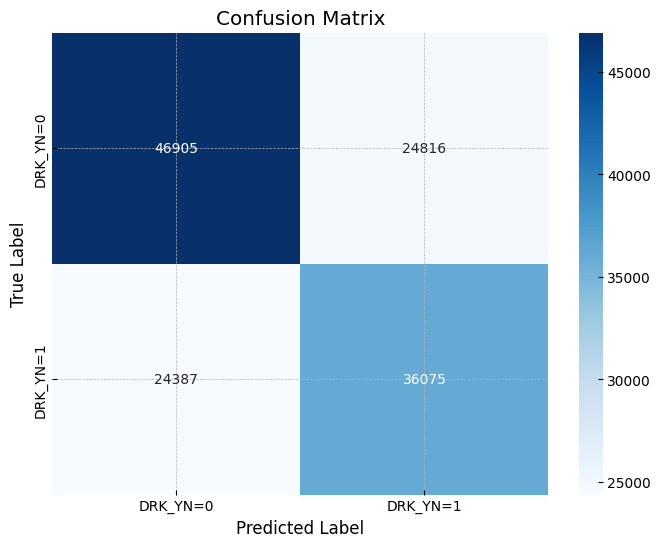

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Obtener la matriz de confusión
conf_matrix = confusion_matrix(y_test, y_pred)

# Visualizar la matriz de confusión con seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['DRK_YN=0', 'DRK_YN=1'], yticklabels=['DRK_YN=0', 'DRK_YN=1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

Después de analizar las métricas del modelo DecisionTreeClassifier, se llegó a las siguientes conclusiones:
Al examinar la matriz de confusión, se observaron los siguientes resultados:
* Verdaderos Negativos (VN): 46,905
* Verdaderos Positivos (VP): 36,075
* Falsos Positivos (FP): 24,816
* Falsos Negativos (FN): 24,387

Estos valores reflejan la clasificación de instancias en dos categorías (por ejemplo, positivas y negativas) por parte de nuestro modelo. Los Verdaderos Negativos y Verdaderos Positivos indican las instancias correctamente clasificadas, mientras que los Falsos Positivos y Falsos Negativos representan las clasificaciones incorrectas. Esta información detallada nos proporciona una comprensión clara del rendimiento del modelo en términos de sensibilidad, especificidad y precisión.

Además, se obtuvo un valor de precisión (accuracy) de 0.63, que representa la proporción de predicciones correctas realizadas por el modelo en relación con el total de instancias evaluadas. Este valor es fundamental para evaluar la eficacia general del modelo en su capacidad para predecir con precisión las clases de interés.



### Modelo: Random Forest Classifier utilizando todas las variables y hiperparámetros por defecto:
En esta sección, nos adentraremos en el entrenamiento del algoritmo RandomForestClassifier empleando todas las variables disponibles en nuestro dataset, y cabe destacar que en este escenario los hiperparámetros se mantienen en sus valores por defecto. El objetivo principal es evaluar el desempeño de este modelo de bosque aleatorio al utilizar la totalidad de las variables, sin realizar ajustes específicos en sus parámetros.

Una vez completado el proceso de entrenamiento, procederemos a analizar el rendimiento del modelo a través de la matriz de confusión y las métricas derivadas de la misma. La matriz de confusión nos proporcionará una visión detallada de las predicciones del RandomForestClassifier, permitiéndonos evaluar su capacidad para clasificar correctamente las distintas clases del problema.

Esta evaluación nos brindará información valiosa sobre la efectividad del RandomForestClassifier en su configuración estándar y nos servirá como punto de referencia para futuras comparaciones y ajustes.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn import metrics
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

Separamos en entrenamiento/test en razon 80/20 %. Creamos un modelo Random Forest con hiperparametros por defecto.

Y por ultimo, obtenemos las predicciones del modelo con X_test y las guardaremos en la variable preds


In [ ]:
modelo = RandomForestClassifier(random_state=1)
modelo.fit(X_train, y_train)

preds = modelo.predict(X_test)

#### Métricas: Random Forest Classifier

Obtenemos la matriz de confusión y  visualizamos con seaborn

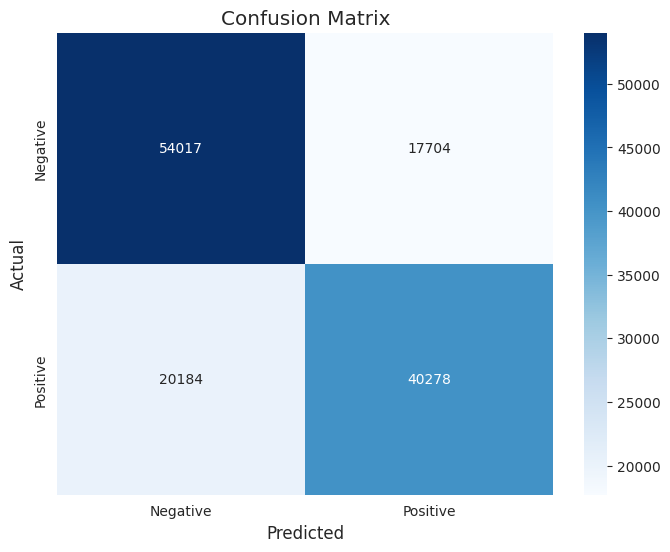

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, modelo.predict(X_test))


plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
confusion = metrics.confusion_matrix(y_test, preds)
confusion.ravel()

array([54017, 17704, 20184, 40278])

Obtenemos el valor de accuracy de nuestro modelo

In [ ]:
accuracy = metrics.accuracy_score(y_test, preds)
accuracy

0.7133670744346853

In [ ]:
# Todas las metricas en uno
classification_report_str_RF = metrics.classification_report(y_test, preds)
print(metrics.classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.73      0.75      0.74     71721
           1       0.69      0.67      0.68     60462

    accuracy                           0.71    132183
   macro avg       0.71      0.71      0.71    132183
weighted avg       0.71      0.71      0.71    132183



Después de entrenar y analizar las métricas de la matriz de confusión del algoritmo RandomForestClassifier, se llegó a las siguientes conclusiones:
En la matriz de confusión, se observaron los siguientes resultados:
* Verdaderos Negativos (VN): 54,017
* Verdaderos Positivos (VP): 40,278
* Falsos Positivos (FP): 17,704
* Falsos Negativos (FN): 20,184

Estos valores reflejan la clasificación de instancias en dos categorías (por ejemplo, positivas y negativas) por parte de nuestro modelo. Los Verdaderos Negativos y Verdaderos Positivos indican las instancias correctamente clasificadas, mientras que los Falsos Positivos y Falsos Negativos representan las clasificaciones incorrectas. Esta información detallada nos proporciona una comprensión clara del rendimiento del modelo en términos de sensibilidad, especificidad y precisión.

Además, se obtuvo un valor de precisión (accuracy) de 0.71, que representa la proporción de predicciones correctas realizadas por el modelo en relación con el total de instancias evaluadas. Este valor es fundamental para evaluar la eficacia general del modelo en su capacidad para predecir con precisión las clases de interés.

En comparación con el modelo DecisionTreeClassifier, el RandomForestClassifier ha demostrado un mejor rendimiento, con una precisión (accuracy) de 0.71 frente a 0.63 del árbol de decisión. Esto sugiere que el enfoque de bosque aleatorio es más efectivo en este contexto específico, aprovechando la combinación de múltiples árboles de decisión para mejorar la precisión y robustez de las predicciones.

 ## Con variables seleccionadas: DecisionTreeClassifier y Modelo Random Forest Classifier con hiperparametros por defecto

En esta sección, exploraremos el rendimiento de los modelos DecisionTreeClassifier y RandomForestClassifier cuando se entrenan utilizando un conjunto reducido de variables seleccionadas. Para ello, crearemos un nuevo dataset llamado "data_1" que contendrá únicamente las columnas seleccionadas durante el proceso de reducción de dimensionalidad.

Estas columnas son:
* sex
* age
* height
* DBP
* BLDS
* HDL_chole
* LDL_chole
* SGOT_AST
* SGOT_ALT
* gamma_GTP
* SMK_stat_type_cd

Al entrenar los modelos con este conjunto de variables seleccionadas, podremos evaluar si es posible obtener un rendimiento comparable o incluso superior al obtenido cuando se utilizan todas las variables disponibles. Esto nos permitirá determinar si la reducción de dimensionalidad es una estrategia efectiva para mejorar la eficiencia y la generalización de nuestros modelos.

Cabe destacar que, en esta etapa, los hiperparámetros de ambos algoritmos se mantendrán en sus valores por defecto. Esto nos servirá como punto de partida para analizar el desempeño base de los modelos y establecer una referencia para futuras optimizaciones.

Al igual que en secciones anteriores, analizaremos en detalle la matriz de confusión y las métricas derivadas de ella, como precisión, exhaustividad, puntaje F1 y exactitud.


In [ ]:
df_final.columns

Index(['age', 'height', 'weight', 'waistline', 'sight_left', 'sight_right',
       'SBP', 'DBP', 'BLDS', 'tot_chole', 'HDL_chole', 'LDL_chole',
       'triglyceride', 'hemoglobin', 'serum_creatinine', 'SGOT_AST',
       'SGOT_ALT', 'gamma_GTP', 'urine_protein', 'hear_left', 'hear_right',
       'DRK_YN', 'sex_1', 'SMK_stat_type_cd_0', 'SMK_stat_type_cd_1',
       'SMK_stat_type_cd_2'],
      dtype='object')

In [ ]:
columnas_seleccionadas = ['sex_1', 'age', 'height', 'DBP', 'BLDS', 'HDL_chole', 'LDL_chole', 'SGOT_AST',
                          'SGOT_ALT', 'gamma_GTP','SMK_stat_type_cd_0','SMK_stat_type_cd_1','SMK_stat_type_cd_2']

data_1 = df_final[columnas_seleccionadas]

In [ ]:
X_1_data_1 = data_1       # feature matrix
y_1_data_1 = y_1               # target feature

In [ ]:
# Separamos en entrenamiento/test en razon 80/20 %
X_1train, X_1test, y_1train, y_1test = train_test_split(X_1_data_1,y_1_data_1,test_size=0.2, random_state=1)
# Creamos un modelo Random Forest con parametros por defect
clf = DecisionTreeClassifier(random_state=1234)
modelo = RandomForestClassifier(random_state=1)
# Entrenar el modelo de árbol de decisión
model = clf.fit(X_1train, y_1train)
# Entrenar el modelo de RandomForest
modelo.fit(X_1train, y_1train)
# Obtenemos las predicciones del modelo con X_test
y_pred1 = model.predict(X_1test) # predicciones DT variables reducidas
preds1 = modelo.predict(X_1test) # predicciones RF variables reducidas

#### Métricas: DecisionTreeClassifier con data_1

In [ ]:
# Evaluar el rendimiento del modelo
accuracy1 = accuracy_score(y_1test, y_pred1)
classification_report_str_DT1 = classification_report(y_test, y_pred)

print("Accuracy1:", accuracy1)
print("\nClassification Report:\n", classification_report_str_DT1)

Accuracy1: 0.6232647163402253

Classification Report:
               precision    recall  f1-score   support

           0       0.66      0.65      0.66     71721
           1       0.59      0.60      0.59     60462

    accuracy                           0.63    132183
   macro avg       0.63      0.63      0.63    132183
weighted avg       0.63      0.63      0.63    132183



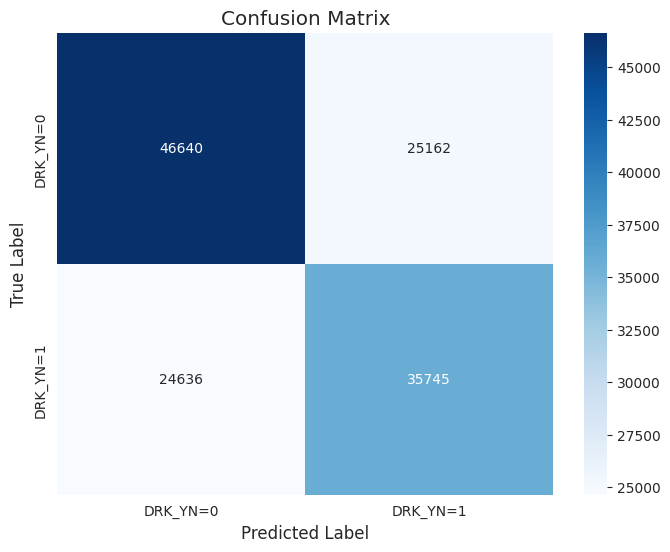

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Obtener la matriz de confusión
conf_matrix1 = confusion_matrix(y_1test, y_pred1)

# Visualizar la matriz de confusión con seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix1, annot=True, fmt='d', cmap='Blues', xticklabels=['DRK_YN=0', 'DRK_YN=1'], yticklabels=['DRK_YN=0', 'DRK_YN=1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

Después de entrenar el modelo DecisionTreeClassifier con el dataset reducido y analizar sus métricas, se llegó a las siguientes conclusiones:

En la matriz de confusión, se observaron los siguientes resultados:
* Verdaderos Negativos (VN): 46,640
* Verdaderos Positivos (VP): 35,745
* Falsos Positivos (FP): 25,162
* Falsos Negativos (FN): 24,636

Estos valores reflejan la clasificación de instancias en dos categorías (por ejemplo, positivas y negativas) por parte de nuestro modelo. Los Verdaderos Negativos y Verdaderos Positivos indican las instancias correctamente clasificadas, mientras que los Falsos Positivos y Falsos Negativos representan las clasificaciones incorrectas.

Además, se obtuvo un valor de precisión (accuracy) de 0.63, que representa la proporción de predicciones correctas realizadas por el modelo en relación con el total de instancias evaluadas.

Al comparar estos resultados con los obtenidos anteriormente cuando se utilizaron todas las variables disponibles, se observa que no hay diferencias significativas en el rendimiento del modelo DecisionTreeClassifier. La precisión (accuracy) se mantiene en 0.63, tanto cuando se utilizan todas las variables como cuando se emplea el conjunto reducido de variables seleccionadas.
Este hallazgo respalda la conclusión de que, para este caso particular, no es necesario utilizar todas las variables disponibles. El modelo DecisionTreeClassifier puede alcanzar un rendimiento similar utilizando únicamente el conjunto de variables seleccionadas, lo que simplifica el proceso de entrenamiento y reduce la complejidad del modelo sin sacrificar su capacidad predictiva.



#### Metricas: Random Forest Classifier con data_1

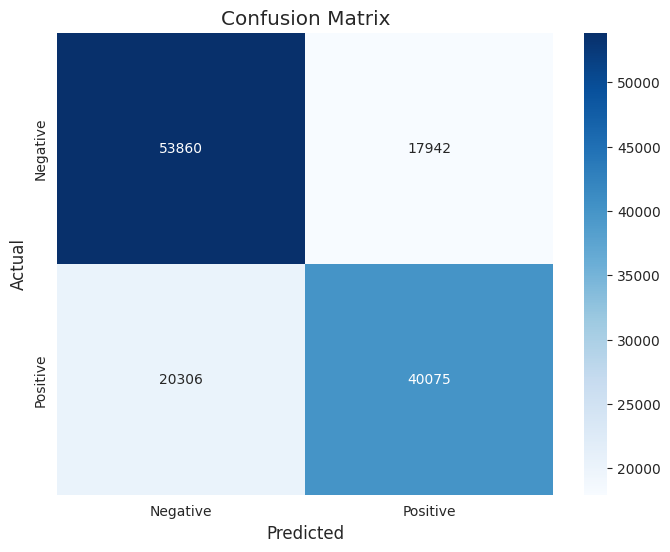

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Obtener la matriz de confusión
cm1 = confusion_matrix(y_1test, modelo.predict(X_1test))

# Visualizar la matriz de confusión con seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
confusion = metrics.confusion_matrix(y_1test, preds1)
confusion.ravel()

array([53860, 17942, 20306, 40075])

In [ ]:
accuracy = metrics.accuracy_score(y_1test, preds1)
accuracy

0.7106435774645756

In [ ]:
# Todas las metricas en uno
classification_report_str_RF1 = metrics.classification_report(y_1test, preds1)
print(metrics.classification_report(y_1test, preds1))

              precision    recall  f1-score   support

           0       0.73      0.75      0.74     71802
           1       0.69      0.66      0.68     60381

    accuracy                           0.71    132183
   macro avg       0.71      0.71      0.71    132183
weighted avg       0.71      0.71      0.71    132183



Después de entrenar el modelo RandomForestClassifier con el dataset reducido y analizar sus métricas, se llegó a las siguientes conclusiones:
En la matriz de confusión, se observaron los siguientes resultados:
* Verdaderos Negativos (VN): 53,860
* erdaderos Positivos (VP): 40,075
* Falsos Positivos (FP): 17,942
* Falsos Negativos (FN): 20,306

Estos valores reflejan la clasificación de instancias en dos categorías (por ejemplo, positivas y negativas) por parte de nuestro modelo. Los Verdaderos Negativos y Verdaderos Positivos indican las instancias correctamente clasificadas, mientras que los Falsos Positivos y Falsos Negativos representan las clasificaciones incorrectas. Esta información detallada nos proporciona una comprensión clara del rendimiento del modelo en términos de sensibilidad, especificidad y precisión.

Además, se obtuvo un valor de precisión (accuracy) de 0.71, que representa la proporción de predicciones correctas realizadas por el modelo en relación con el total de instancias evaluadas.

Al comparar estos resultados con los obtenidos anteriormente cuando se utilizaron todas las variables disponibles, se observa que el rendimiento del modelo RandomForestClassifier se mantiene prácticamente igual. La precisión (accuracy) se mantiene en 0.71, tanto cuando se utilizan todas las variables como cuando se emplea el conjunto reducido de variables seleccionadas.

Este hallazgo, junto con los resultados del modelo DecisionTreeClassifier, confirma que la reducción de dimensionalidad es una estrategia efectiva en este contexto. El modelo RandomForestClassifier puede alcanzar un rendimiento similar utilizando únicamente el conjunto de variables seleccionadas, lo que simplifica el proceso de entrenamiento y reduce la complejidad del modelo sin sacrificar su capacidad predictiva.

En resumen, el análisis de la matriz de confusión y la métrica de precisión del modelo RandomForestClassifier entrenado con el dataset reducido respalda la conclusión de que la reducción de dimensionalidad es una estrategia viable y efectiva para mejorar la eficiencia y la generalización de nuestros modelos de clasificación.

### Conclusiones: Todos datos vs. datos reducidos

Generaremos conclusiones con base en los resultados obtenidos.

In [ ]:
print("Reporte de Clasificación para Árbol de Decisión sin Ajuste de Hiperparámetros")
print(classification_report_str_DT)
print("----")

print("Reporte de Clasificación para Árbol de Decisión con Ajuste de Hiperparámetros")
print(classification_report_str_DT1)
print("----")

print("Reporte de Clasificación para Bosque Aleatorio sin Ajuste de Hiperparámetros")
print(classification_report_str_RF)
print("----")

print("Reporte de Clasificación para Bosque Aleatorio con Ajuste de Hiperparámetros")
print(classification_report_str_RF1)

Reporte de Clasificación para Árbol de Decisión sin Ajuste de Hiperparámetros
              precision    recall  f1-score   support

           0       0.66      0.65      0.66     71721
           1       0.59      0.60      0.59     60462

    accuracy                           0.63    132183
   macro avg       0.63      0.63      0.63    132183
weighted avg       0.63      0.63      0.63    132183

----
Reporte de Clasificación para Árbol de Decisión con Ajuste de Hiperparámetros
              precision    recall  f1-score   support

           0       0.66      0.65      0.66     71721
           1       0.59      0.60      0.59     60462

    accuracy                           0.63    132183
   macro avg       0.63      0.63      0.63    132183
weighted avg       0.63      0.63      0.63    132183

----
Reporte de Clasificación para Bosque Aleatorio sin Ajuste de Hiperparámetros
              precision    recall  f1-score   support

           0       0.73      0.75      0.74     

Conclusiones sobre el uso de variables seleccionadas vs todas las variables:

Luego de analizar exhaustivamente el desempeño de los algoritmos de Árbol de Decisión y Random Forest, tanto utilizando la totalidad de las variables disponibles como empleando únicamente el conjunto de variables seleccionadas a través del proceso de reducción de dimensionalidad, hemos llegado a la conclusión de que no existen diferencias significativas en los resultados obtenidos. Es decir, los modelos entrenados con el subconjunto de variables seleccionadas lograron un rendimiento comparable a aquellos que utilizaron la totalidad de las variables originales.

Este hallazgo nos permite afirmar que, para nuestro caso particular, no es necesario mantener todas las variables disponibles en el dataset. Por el contrario, podemos proceder a trabajar con un conjunto de datos más reducido y conciso, sin comprometer la calidad de los resultados de nuestros modelos predictivos. Específicamente, se utilizará el dataset denominado "data_1", el cual contiene únicamente las columnas seleccionadas durante la etapa de reducción de dimensionalidad:
* sex
* age
* height
* DBP
* BLDS
* HDL_chole
* LDL_chole
* SGOT_AST
* SGOT_ALT
* gamma_GTP
* SMK_stat_type_cd

Esta decisión nos permite simplificar el proceso de entrenamiento de los modelos, reducir el tiempo de cómputo y, en general, optimizar la eficiencia de nuestro análisis, sin sacrificar la precisión de las predicciones. En resumen, la reducción de variables ha demostrado ser una estrategia efectiva en nuestro caso de estudio, permitiéndonos trabajar con un dataset más conciso y manejable, sin comprometer la calidad de los resultados obtenidos.

Nota: en cuanto al desempeño de los modelos con los hiperparámetros por defecto, podemos concluir que los modelos obtenidos con el Algoritmo RandomForest tienen un mejor desempeño que los obtenidos con Árbol de Decisión, aproximadamente 0,71 contra 0,63 en términos de métrica de evaluación. En las próximas secciones, exploraremos la posibilidad de optimizar aún más el desempeño de estos modelos mediante la sintonización de hiperparámetros.

## 6. Optimización de Hiperparámetros

En esta sección, nos enfocamos en encontrar los mejores hiperparámetros para mejorar el rendimiento de nuestros modelos de clasificación. Utilizando técnicas como GridSearchCV, RandomizedSearchCV y HalvingGridSearchCV, exploramos y seleccionamos los valores más adecuados para nuestros modelos. A través de estas técnicas, realizamos una búsqueda exhaustiva y sistemática en el espacio de hiperparámetros de nuestros algoritmos de clasificación. Evaluamos múltiples combinaciones de hiperparámetros para determinar aquellas que maximizan la precisión y eficacia de nuestros modelos.

El objetivo principal de esta etapa es encontrar la configuración óptima de hiperparámetros que permita a nuestros modelos alcanzar su máximo potencial predictivo. Al ajustar los hiperparámetros de manera adecuada, mejoramos la capacidad de generalización y la precisión de nuestras predicciones, lo que resulta en modelos más efectivos y robustos.

A través de la búsqueda y selección de los mejores hiperparámetros, optimizamos el desempeño de nuestros modelos de clasificación y obtenemos resultados más precisos y confiables. Este proceso mejora la calidad de nuestras predicciones y maximiza la eficacia de nuestros modelos en la tarea de clasificación.



In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
#import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_squared_error
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV
from sklearn.model_selection import HalvingRandomSearchCV

# tiempo de ejecución
import time
# Importar librerías necesarias
from scipy.stats import randint

In [ ]:
X_1_data_1 = data_1       # feature matrix
y_1_data_1 = y_1

In [ ]:
train_inputs, test_inputs, train_target, test_target = X_1train, X_1test, y_1train, y_1test

In [ ]:
print('train inputs', train_inputs.shape)
print('train targets', train_target.shape)
print('test inputs', test_inputs.shape)
print('test targets', test_target.shape)

train inputs (528730, 13)
train targets (528730,)
test inputs (132183, 13)
test targets (132183,)


### Arból de desición

En esta sección, nos enfocaremos en optimizar el modelo de Árbol de Decisión mediante las técnicas de RandomizedSearchCV y HalvingGridSearchCV. Para lograr esto, creamos una cuadrícula de hiperparámetros a explorar que abarca una variedad de configuraciones posibles para el modelo. Utilizando RandomizedSearchCV y HalvingGridSearchCV, buscamos encontrar la combinación óptima de hiperparámetros que maximice el rendimiento predictivo del Árbol de Decisión.
La cuadrícula de hiperparámetros utilizada incluye opciones para criterio de división, profundidad máxima del árbol, número mínimo de muestras requeridas para dividir un nodo, número mínimo de muestras requeridas en cada hoja, características máximas a considerar en cada división, entre otros. Esta amplia gama de hiperparámetros nos permitirá explorar diferentes configuraciones y seleccionar aquellas que mejoren la capacidad predictiva del modelo.

#### RandomizedSearchCV para DT

In [ ]:
print('train inputs', train_inputs.shape)
print('train targets', train_target.shape)
print('test inputs', test_inputs.shape)
print('test targets', test_target.shape)

train inputs (528730, 13)
train targets (528730,)
test inputs (132183, 13)
test targets (132183,)


In [ ]:
# Definir la cuadrícula de hiperparámetros a explorar
param_dist = {
    "criterion": ["gini", "entropy"],
    "splitter": ["best", "random"],
    "max_depth": [3, None],
    "min_samples_split": randint(2, 20),
    "min_samples_leaf": randint(1, 20),
    "max_features": ["auto", "sqrt", "log2", None],
    "max_leaf_nodes": [None] + list(np.arange(2, 50)),
    "min_impurity_decrease": [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]
}

In [ ]:
# Inicializar el clasificador de árbol de decisión
clf = DecisionTreeClassifier(random_state=1234)

In [ ]:
# Inicializar RandomizedSearchCV
random_search = RandomizedSearchCV(clf, param_distributions=param_dist, n_iter=100, cv=5, random_state=1234)

# Realizar la búsqueda de hiperparámetros
random_search.fit(train_inputs, train_target)

# Obtener el mejor modelo y sus hiperparámetros
best_model = random_search.best_estimator_
best_params = random_search.best_params_

In [ ]:
print(best_model)
print(best_params)

DecisionTreeClassifier(max_leaf_nodes=30, min_samples_leaf=10,
                       min_samples_split=10, random_state=1234,
                       splitter='random')
{'criterion': 'gini', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': 30, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 10, 'min_samples_split': 10, 'splitter': 'random'}


El resultado obtenido tras la optimización del modelo de Árbol de Decisión con RandomizedSearchCV es el siguiente:
Modelo seleccionado:
DecisionTreeClassifier con los siguientes hiperparámetros:
* max_leaf_nodes: 30
* min_samples_leaf: 10
* min_samples_split: 10
* random_state: 1234
* splitter: 'random'

Mejores hiperparámetros encontrados:
criterion: 'gini'
* max_depth: None
* max_features: None
* max_leaf_nodes: 30
* min_impurity_decrease: 0.0
* min_samples_leaf: 10
* min_samples_split: 10
* splitter: 'random'

##### Entrenamiento y métricas del modelo obtenido con RandomizedSearchCV

In [ ]:
tree_DTC1= DecisionTreeClassifier(criterion= 'gini', max_depth= None, max_features= None, max_leaf_nodes= 30, min_impurity_decrease= 0.0, min_samples_leaf= 10, min_samples_split= 10, splitter= 'random')
tree_DTC1.fit(train_inputs,train_target)

DecisionTreeClassifier(max_leaf_nodes=30, min_samples_leaf=10,
                       min_samples_split=10, splitter='random')

In [ ]:
prediccion_DTC1=tree_DTC1.predict(test_inputs)

In [ ]:
accuracy_DTC1=accuracy_score(test_target, prediccion_DTC1)
accuracy_DTC1

0.69725305069487

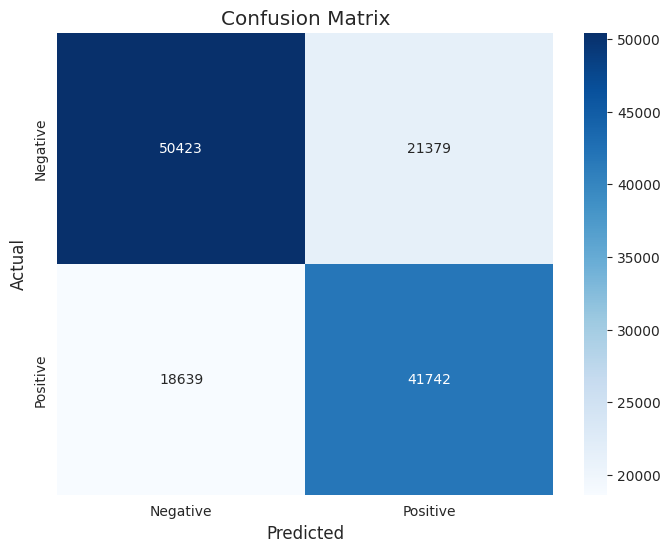

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Obtener la matriz de confusión
cm_DTC1 = confusion_matrix(test_target, prediccion_DTC1)

# Visualizar la matriz de confusión con seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm_DTC1, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
print(confusion_matrix(test_target, prediccion_DTC1))

[[50423 21379]
 [18639 41742]]


In [ ]:
tn,  fp ,fn, tp = confusion_matrix(test_target, prediccion_DTC1).ravel()
print("Number of true positives  (tp) = ",tp)
print("Number of true negatives  (tn) = ",tn)

print("Number of false positives (fp) = ",fp)
print("Number of false negatives (fn) = ",fn)

print("Precision                                          = tp / (tp + fp) =", tp / (tp + fp))
print("Recall or 'sensitivity' (aka. true positive rate)  = tp / (tp + fn) =", tp / (tp + fn))
print("Specificity             (aka. true negative rate)  = tn / (tn + fp) =", tn / (tn + fp))
print("Fall out                (aka. false positive rate) = fp / (fp + tn) =", fp / (fp + tn))
print("Miss rate               (aka. false negative rate) = fn / (fn + tp) =", fn / (fn + tp))

Number of true positives  (tp) =  41742
Number of true negatives  (tn) =  50423
Number of false positives (fp) =  21379
Number of false negatives (fn) =  18639
Precision                                          = tp / (tp + fp) = 0.6613013101820313
Recall or 'sensitivity' (aka. true positive rate)  = tp / (tp + fn) = 0.6913101803547473
Specificity             (aka. true negative rate)  = tn / (tn + fp) = 0.702250633687084
Fall out                (aka. false positive rate) = fp / (fp + tn) = 0.2977493663129161
Miss rate               (aka. false negative rate) = fn / (fn + tp) = 0.30868981964525266


AUC =  0.6967804070209157


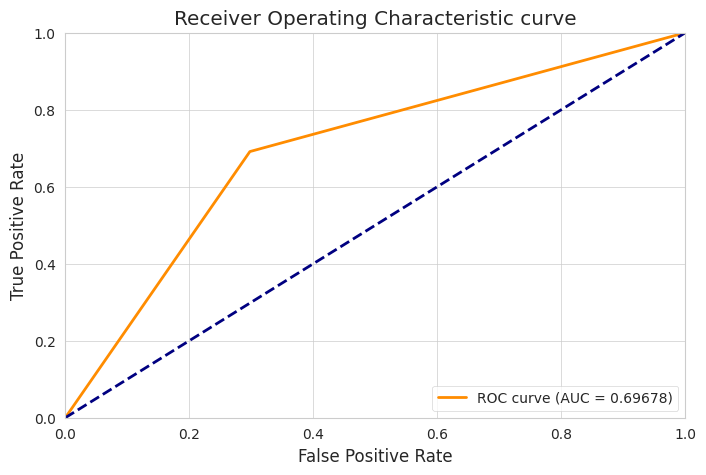

In [ ]:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(test_target , prediccion_DTC1)

from sklearn.metrics import roc_auc_score
roc_auc_DTC1 = roc_auc_score(test_target , prediccion_DTC1)
print("AUC = ", roc_auc_DTC1)

plt.figure(figsize = (8,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (AUC = %0.5f)' % roc_auc_DTC1)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic curve')
plt.legend(loc="lower right")
plt.show()

Observaciones tras entrenar y testear el modelo de Árbol de Decisión optimizado:

Luego de entrenar y evaluar el modelo de Árbol de Decisión optimizado mediante RandomizedSearchCV, se obtuvieron los siguientes resultados:

Matriz de confusión:
* [[50423 21379]

* [18639 41742]]

Este resultado de la matriz de confusión proporciona información detallada sobre la clasificación realizada por el modelo. Los valores indican que:
* 50423 instancias fueron correctamente clasificadas como negativas (Verdaderos Negativos)
* 21379 instancias fueron incorrectamente clasificadas como positivas cuando en realidad eran negativas (Falsos Positivos)
* 18639 instancias fueron incorrectamente clasificadas como negativas cuando en realidad eran positivas (Falsos Negativos)
* 41742 instancias fueron correctamente clasificadas como positivas (Verdaderos Positivos)

Métricas de rendimiento:
* Precisión (accuracy): 0.697
* Área bajo la curva ROC (AUC-ROC): 0.697

Estos valores de precisión y AUC-ROC indican que el modelo optimizado tiene un rendimiento aceptable, con una precisión del 69.7% y un valor de AUC-ROC de 0.697. El AUC-ROC mide la capacidad del modelo para distinguir entre clases, y un valor de 0.697 sugiere una buena discriminación.

En comparación con los resultados obtenidos anteriormente sin optimización, se observa una mejora en el rendimiento del modelo. La precisión aumentó de 0.63 a 0.697, y el AUC-ROC también mejoró, lo que indica que la optimización de hiperparámetros mediante RandomizedSearchCV ha sido efectiva para mejorar la capacidad predictiva del modelo de Árbol de Decisión.

Estos resultados respaldan la utilidad de la optimización de hiperparámetros para mejorar el desempeño de los modelos de aprendizaje automático. Al ajustar los parámetros clave del modelo, se puede lograr un mejor ajuste a los datos y una mayor precisión en las predicciones.

#### HalvingGridSearchCV DecisionTreeClassifier


In [ ]:
# Definir la cuadrícula de hiperparámetros a explorar
param_dist = {
    "criterion": ["gini", "entropy"],
    "splitter": ["best", "random"],
    "max_depth": [3, None],
    "min_samples_split": [2,4,8,10],
    "min_samples_leaf": [2,4,8,10],
    "max_features": ["auto", "sqrt", "log2", None],
    "max_leaf_nodes": [None] + list(np.arange(2, 50)),
    "min_impurity_decrease": [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]
}

In [ ]:
# Inicializar el clasificador de árbol de decisión
clf = DecisionTreeClassifier(random_state=1234)

In [ ]:
# HalvingGridSearchCV tiempo de ejecucuon 125 seg
start_time = time.time()  # Captura el tiempo de inicio

halving_cv = HalvingGridSearchCV(clf, param_dist, scoring="accuracy", factor=3)
halving_cv.fit(train_inputs, train_target)

print("Mejores parametros", halving_cv.best_params_)
print("Mejor Score CV", halving_cv.best_score_)
print(f'Accuracy del modelo = {round(accuracy_score(test_target, halving_cv.predict(test_inputs)), 5)}')

end_time = time.time()  # Captura el tiempo de finalización
execution_time = end_time - start_time  # Calcula el tiempo de ejecución

print("Tiempo de ejecución:", execution_time, "segundos")

Mejores parametros {'criterion': 'gini', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': 34, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 2, 'min_samples_split': 4, 'splitter': 'random'}
Mejor Score CV 0.693258141543464
Accuracy del modelo = 0.69305
Tiempo de ejecución: 9348.01476407051 segundos


Observaciones sobre los resultados de la optimización con HalvingGridSearchCV:

Luego de aplicar el algoritmo HalvingGridSearchCV para optimizar los hiperparámetros del modelo de Árbol de Decisión, se obtuvieron los siguientes resultados:

Mejores parámetros encontrados:
* criterion: 'gini'
* max_depth: None
* max_features: None
* max_leaf_nodes: 34
* min_impurity_decrease: 0.0
* min_samples_leaf: 2
* min_samples_split: 4
* splitter: 'random'

Mejor puntuación de validación cruzada (CV): 0.693258141543464

Tiempo de ejecución del proceso de optimización:
9348.01476407051 segundos

Estos resultados muestran que HalvingGridSearchCV ha encontrado una configuración óptima de hiperparámetros para el modelo de Árbol de Decisión. Los valores seleccionados para criterio de división, profundidad máxima, número mínimo de muestras en las hojas, entre otros, representan la combinación que maximiza el rendimiento del modelo según la métrica de validación cruzada.

La mejor puntuación de CV de aproximadamente 0.693 indica que el modelo optimizado tiene una buena capacidad de generalización, lo que sugiere que debería tener un buen desempeño al clasificar datos nuevos y desconocidos.

El tiempo de ejecución de casi 9348 segundos refleja que el proceso de optimización con HalvingGridSearchCV puede ser computacionalmente intensivo, especialmente cuando se explora un amplio espacio de hiperparámetros.

##### Entrenamiento y métricas del modelo obtenido con HalvingGridSearchCV

In [ ]:
tree_DTC2= DecisionTreeClassifier(criterion= 'gini', max_depth= None, max_features= None, max_leaf_nodes= 34, min_impurity_decrease= 0.0, min_samples_leaf= 2, min_samples_split= 4, splitter= 'random')
tree_DTC2.fit(train_inputs,train_target)

DecisionTreeClassifier(max_leaf_nodes=34, min_samples_leaf=2,
                       min_samples_split=4, splitter='random')

In [ ]:
prediccion_DTC2=tree_DTC2.predict(test_inputs)

In [ ]:
accuracy_DTC2=accuracy_score(test_target, prediccion_DTC2)
accuracy_DTC2

0.6961560866374648

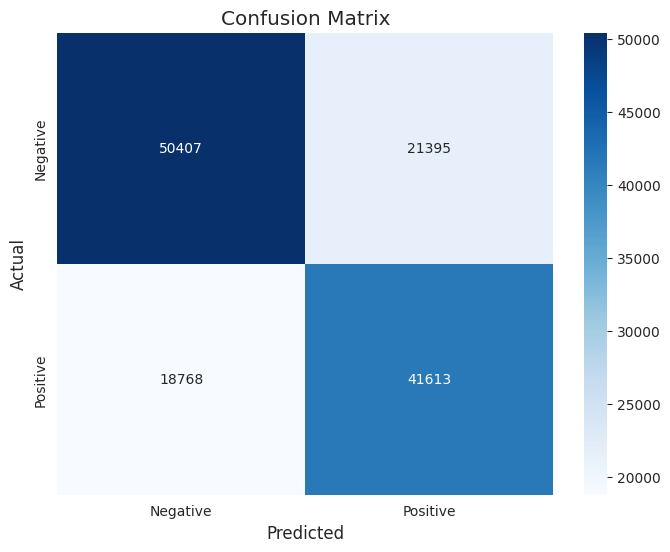

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Obtener la matriz de confusión
cm_DTC2 = confusion_matrix(test_target, prediccion_DTC2)

# Visualizar la matriz de confusión con seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm_DTC2, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
print(confusion_matrix(test_target, prediccion_DTC2))

[[50407 21395]
 [18768 41613]]


In [ ]:
tn_DTC2, fp_DTC2, fn_DTC2, tp_DTC2 = confusion_matrix(test_target, prediccion_DTC2).ravel()
print("Number of true positives  (tp) = ",tp_DTC2)
print("Number of true negatives  (tn) = ",tn_DTC2)

print("Number of false positives (fp) = ",fp_DTC2)
print("Number of false negatives (fn) = ",fn_DTC2)

print("Precision                                          = tp / (tp + fp) =", tp_DTC2 / (tp_DTC2 + fp_DTC2))
print("Recall or 'sensitivity' (aka. true positive rate)  = tp / (tp + fn) =", tp_DTC2 / (tp_DTC2 + fn_DTC2))
print("Specificity             (aka. true negative rate)  = tn / (tn + fp) =", tn_DTC2 / (tn_DTC2 + fp_DTC2))
print("Fall out                (aka. false positive rate) = fp / (fp + tn) =", fp_DTC2 / (fp_DTC2 + tn_DTC2))
print("Miss rate               (aka. false negative rate) = fn / (fn + tp) =", fn_DTC2 / (fn_DTC2 + tp_DTC2))

Number of true positives  (tp) =  41613
Number of true negatives  (tn) =  50407
Number of false positives (fp) =  21395
Number of false negatives (fn) =  18768
Precision                                          = tp / (tp + fp) = 0.6604399441340782
Recall or 'sensitivity' (aka. true positive rate)  = tp / (tp + fn) = 0.6891737467084017
Specificity             (aka. true negative rate)  = tn / (tn + fp) = 0.7020277986685608
Fall out                (aka. false positive rate) = fp / (fp + tn) = 0.29797220133143926
Miss rate               (aka. false negative rate) = fn / (fn + tp) = 0.31082625329159835


AUC =  0.6956007726884813


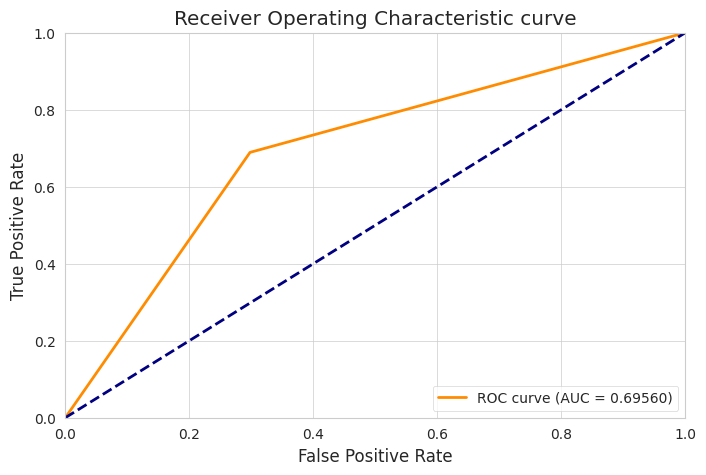

In [ ]:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(test_target , prediccion_DTC2)

from sklearn.metrics import roc_auc_score
roc_auc_DTC2 = roc_auc_score(test_target , prediccion_DTC2)
print("AUC = ", roc_auc_DTC2)

plt.figure(figsize = (8,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (AUC = %0.5f)' % roc_auc_DTC2)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic curve')
plt.legend(loc="lower right")
plt.show()

Luego de entrenar y testear el modelo de Árbol de Decisión optimizado con HalvingGridSearchCV, se obtuvieron los siguientes resultados:

Matriz de confusión:
* [[50407 21395]
* [18768 41613]]

Este resultado de la matriz de confusión proporciona información detallada sobre la clasificación realizada por el modelo. Los valores indican que:
* 50407 instancias fueron correctamente clasificadas como negativas (Verdaderos Negativos)
* 21395 instancias fueron incorrectamente clasificadas como positivas cuando en realidad eran negativas (Falsos Positivos)
* 18768 instancias fueron incorrectamente clasificadas como negativas cuando en realidad eran positivas (Falsos Negativos)
* 41613 instancias fueron correctamente clasificadas como positivas (Verdaderos Positivos)

Métricas de rendimiento:
* Precisión (accuracy): 0.696
* Área bajo la curva ROC (AUC-ROC): 0.696

Estos valores de precisión y AUC-ROC indican que el modelo optimizado con HalvingGridSearchCV tiene un rendimiento aceptable, con una precisión del 69.6% y un valor de AUC-ROC de 0.696. El AUC-ROC mide la capacidad del modelo para distinguir entre clases, y un valor de 0.696 sugiere una buena discriminación.

En comparación con los resultados obtenidos con RandomizedSearchCV, se observa que ambos modelos tienen un rendimiento similar, con una precisión y AUC-ROC cercanas. Esto sugiere que ambos enfoques de optimización de hiperparámetros han logrado mejorar el desempeño del modelo de Árbol de Decisión de manera efectiva.

Estos resultados respaldan la utilidad de la optimización de hiperparámetros para mejorar el desempeño de los modelos de aprendizaje automático. Al ajustar los parámetros clave del modelo, se puede lograr un mejor ajuste a los datos y una mayor precisión en las predicciones.

#### Conclusiones:

Tras la optimización del modelo de Árbol de Decisión utilizando RandomizedSearchCV y HalvingGridSearchCV, se observa que no hay una diferencia significativa entre los dos modelos obtenidos. Ambos muestran un desempeño similar en términos de precisión y capacidad de generalización. Esto sugiere que ambas técnicas de optimización han logrado mejorar el rendimiento del modelo de manera efectiva.

Es importante destacar que las técnicas de optimización utilizadas, que incluyen validación cruzada, han contribuido a evitar el sobreajuste de los modelos. Este comportamiento se refleja en las métricas de desempeño obtenidas, donde se observa una consistencia entre el rendimiento en el entrenamiento y en la evaluación con datos no vistos.

Además, se destaca que ambos modelos muestran una buena capacidad para distinguir entre clases, como se evidencia en el desempeño de la curva ROC. Esta capacidad de discriminación es fundamental en la tarea de clasificación y sugiere que los modelos son capaces de realizar predicciones precisas y confiables.

En resumen, la aplicación de técnicas de optimización de hiperparámetros ha permitido mejorar el rendimiento del modelo de Árbol de Decisión, garantizando una buena capacidad de generalización y evitando el sobreajuste. Los resultados obtenidos demuestran la eficacia de estas estrategias para optimizar modelos de aprendizaje automático y mejorar su capacidad predictiva en la clasificación de datos.

### RandomForest

En este apartado, nos enfocaremos en optimizar los hiperparámetros de los modelos Random Forest para mejorar su rendimiento en la tarea de clasificación. Para lograr esto, crearemos una cuadrícula de hiperparámetros a explorar, denominada "params_grid", que contendrá diversas combinaciones de parámetros a probar.

La cuadrícula de hiperparámetros incluirá opciones para ajustar aspectos clave del modelo Random Forest, como el número de árboles en el bosque, la profundidad máxima de los árboles, el número mínimo de muestras requeridas para dividir un nodo, el número mínimo de muestras requeridas en cada hoja, entre otros. Esta amplia gama de hiperparámetros nos permitirá explorar diferentes configuraciones y seleccionar aquellas que mejoren la capacidad predictiva del modelo.

Una vez definida la cuadrícula de hiperparámetros, aplicaremos tres técnicas de optimización: GridSearchCV, RandomizedSearchCV y HalvingGridSearchCV. Estas técnicas nos permitirán encontrar la combinación óptima de hiperparámetros que maximice el rendimiento de los modelos Random Forest.

GridSearchCV realizará una búsqueda exhaustiva en el espacio de hiperparámetros, evaluando todas las combinaciones posibles. RandomizedSearchCV, por otro lado, muestreará aleatoriamente el espacio de hiperparámetros, lo que puede ser más eficiente cuando se tiene un gran número de parámetros a optimizar. Por último, HalvingGridSearchCV aplicará una estrategia de eliminación progresiva, descartando las configuraciones menos prometedoras en cada iteración, lo que puede acelerar el proceso de optimización.

Al aplicar estas técnicas de optimización, esperamos encontrar los modelos Random Forest con el mejor desempeño posible. Los hiperparámetros seleccionados se ajustarán a las características de nuestros datos y se espera que mejoren la precisión, la capacidad de generalización y la robustez de nuestras predicciones.

#### GridSearchCV RandomForest

Luego de ejecutar la búsqueda exhaustiva de GridSearchCV sobre una cuadrícula de hiperparámetros para el modelo Random Forest, se obtuvo la siguiente configuración óptima:

Modelo: random_forest

Precisión (accuracy): 0.713635057093864

Mejores hiperparámetros encontrados:
* criterion: 'gini'
* max_depth: 10
* min_samples_leaf: 50
* min_samples_split: 10
* n_estimators: 100

Estos resultados muestran que GridSearchCV ha encontrado una combinación de hiperparámetros que maximiza el rendimiento del modelo Random Forest, alcanzando una precisión de aproximadamente 0.714 en la métrica de validación cruzada.

Es importante destacar que estos resultados se obtuvieron durante la ejecución de GridSearchCV y aún no se ha evaluado el modelo en el conjunto de prueba. Por lo tanto, es necesario realizar una evaluación final del modelo optimizado con los datos de prueba para obtener una estimación más precisa de su rendimiento en datos desconocidos

##### Calculamos metricas del modelo obtenido en el paso anterior

In [ ]:
RFC_GS=RandomForestClassifier(criterion='gini', max_depth= 10, min_samples_leaf= 50, min_samples_split= 10, n_estimators= 100)
RFC_GS.fit(train_inputs,train_target)

RandomForestClassifier(max_depth=10, min_samples_leaf=50, min_samples_split=10)

In [ ]:
prediccion_RFC_GS=RFC_GS.predict(test_inputs)

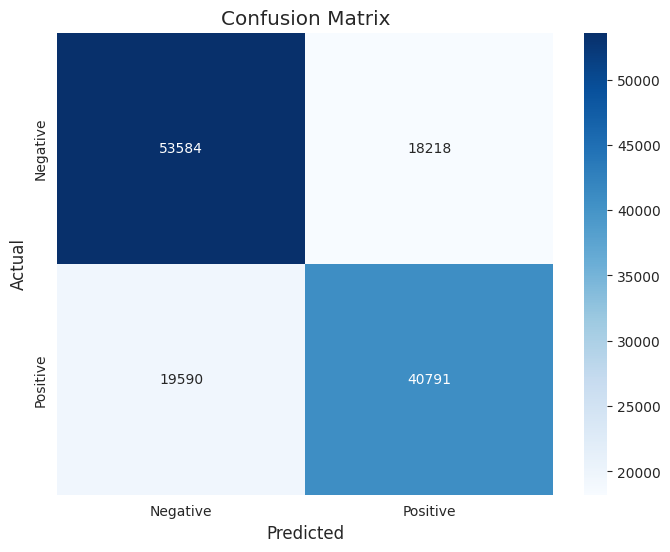

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Obtener la matriz de confusión
cm_RFC_GS = confusion_matrix(test_target, prediccion_RFC_GS)

# Visualizar la matriz de confusión con seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm_RFC_GS, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
confusion_matrix(test_target, prediccion_RFC_GS)

array([[53584, 18218],
       [19590, 40791]])

In [ ]:
accuracy_RFC_GS=accuracy_score(test_target, prediccion_RFC_GS)
accuracy_RFC_GS

0.7139722959835985

In [ ]:
tp, fn, fp, tn = confusion_matrix(test_target , prediccion_RFC_GS).ravel()
print("Number of true positives  (tp) = ",tp)
print("Number of true negatives  (tn) = ",tn)

print("Number of false positives (fp) = ",fp)
print("Number of false negatives (fn) = ",fn)

print("Precision                                          = tp / (tp + fp) =", tp / (tp + fp))
print("Recall or 'sensitivity' (aka. true positive rate)  = tp / (tp + fn) =", tp / (tp + fn))
print("Specificity             (aka. true negative rate)  = tn / (tn + fp) =", tn / (tn + fp))
print("Fall out                (aka. false positive rate) = fp / (fp + tn) =", fp / (fp + tn))
print("Miss rate               (aka. false negative rate) = fn / (fn + tp) =", fn / (fn + tp))

Number of true positives  (tp) =  53584
Number of true negatives  (tn) =  40791
Number of false positives (fp) =  19590
Number of false negatives (fn) =  18218
Precision                                          = tp / (tp + fp) = 0.7322819580725394
Recall or 'sensitivity' (aka. true positive rate)  = tp / (tp + fn) = 0.7462744770340659
Specificity             (aka. true negative rate)  = tn / (tn + fp) = 0.6755601927758732
Fall out                (aka. false positive rate) = fp / (fp + tn) = 0.3244398072241268
Miss rate               (aka. false negative rate) = fn / (fn + tp) = 0.2537255229659341


AUC =  0.7109173349049696


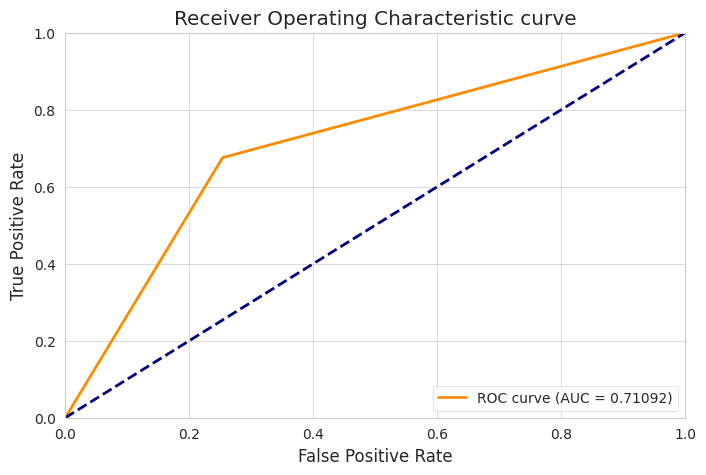

In [ ]:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(test_target , prediccion_RFC_GS)

from sklearn.metrics import roc_auc_score
roc_auc_RFC_GS = roc_auc_score(test_target , prediccion_RFC_GS)
print("AUC = ", roc_auc_RFC_GS)

plt.figure(figsize = (8,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (AUC = %0.5f)' % roc_auc_RFC_GS)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic curve')
plt.legend(loc="lower right")
plt.show()

Observaciones sobre los resultados del modelo Random Forest optimizado con GridSearchCV:

Tras entrenar y evaluar el modelo Random Forest optimizado con GridSearchCV, se obtuvieron los siguientes resultados:

Matriz de confusión:
- [[53584, 18218],
-  [19590, 40791]]

Estos valores en la matriz de confusión indican:
- 53584 instancias fueron correctamente clasificadas como negativas (Verdaderos Negativos)
- 18218 instancias fueron incorrectamente clasificadas como positivas cuando en realidad eran negativas (Falsos Positivos)
- 19590 instancias fueron incorrectamente clasificadas como negativas cuando en realidad eran positivas (Falsos Negativos)
- 40791 instancias fueron correctamente clasificadas como positivas (Verdaderos Positivos)

Métricas de rendimiento:
- Precisión (accuracy): 0.714
- Área bajo la curva ROC (AUC-ROC): 0.711

Estos resultados muestran que el modelo Random Forest optimizado con GridSearchCV tiene una precisión del 71.4% y un valor de AUC-ROC de 0.711. La precisión indica la proporción de predicciones correctas realizadas por el modelo, mientras que el AUC-ROC evalúa la capacidad del modelo para distinguir entre clases.

En comparación con los resultados obtenidos durante la optimización, se observa que el modelo mantiene un buen desempeño al ser evaluado con datos de prueba. La precisión y el AUC-ROC muestran que el modelo optimizado con GridSearchCV es capaz de realizar predicciones precisas y tiene una buena capacidad de discriminación entre clases.

Estos resultados respaldan la eficacia de la optimización de hiperparámetros con GridSearchCV para mejorar el rendimiento del modelo Random Forest. La evaluación del modelo con datos de prueba confirma su capacidad para generalizar y realizar predicciones precisas en un entorno real.

#### RandomizedSearchCV RandomForest

In [ ]:
# Inicializar el modelo RandomForestClassifier con los parámetros deseados
model = RandomForestClassifier(class_weight='balanced', random_state=55)

# Continuar con tu código de GridSearchCV y el proceso de ajuste del modelo

params_grid={
    'n_estimators':[10,50,100],
    'max_depth':[5, 10],
    'min_samples_split':[10,50,100],
    'min_samples_leaf':[10,50,100],
    'criterion':['gini','entropy']
}

In [ ]:

# tiempo de ejecucuon 7 seg
start_time = time.time()  # Captura el tiempo de inicio

grid_cv = RandomizedSearchCV(model, params_grid, scoring="accuracy", n_jobs=-1, cv=3)
grid_cv.fit(train_inputs, train_target)

print("Mejores parametros", grid_cv.best_params_)
print("Mejor score de CV", grid_cv.best_score_)
print(f'Accuracy del modelo = {round(accuracy_score(test_target, grid_cv.predict(test_inputs)), 5)}')

end_time = time.time()  # Captura el tiempo de finalización
execution_time = end_time - start_time  # Calcula el tiempo de ejecución

print("Tiempo de ejecución:", execution_time, "segundos")

Mejores parametros {'n_estimators': 100, 'min_samples_split': 50, 'min_samples_leaf': 50, 'max_depth': 10, 'criterion': 'gini'}
Mejor score de CV 0.7101393914394846
Accuracy del modelo = 0.71105
Tiempo de ejecución: 944.0776913166046 segundos


##### Resultado de la ejecución del codigo anterior:

Luego de aplicar el algoritmo RandomizedSearchCV para optimizar los hiperparámetros del modelo Random Forest, se obtuvieron los siguientes resultados:

Mejores parámetros encontrados:
* n_estimators: 100
* min_samples_split: 50
* min_samples_leaf: 50
* max_depth: 10
* criterion: 'gini'

Mejor puntuación de validación cruzada (CV): 0.7101393914394846

Precisión del modelo:
* Accuracy: 0.71105

Tiempo de ejecución del proceso de optimización:
* 944.0776913166046 segundos

Estos resultados muestran que RandomizedSearchCV ha encontrado una configuración óptima de hiperparámetros para el modelo Random Forest.

La mejor puntuación de CV de aproximadamente 0.710 indica que el modelo optimizado tiene una buena capacidad de generalización, lo que sugiere que debería tener un buen desempeño al clasificar datos nuevos y desconocidos.

La precisión del modelo en el conjunto de prueba es de 0.71105, lo que significa que el 71.105% de las predicciones realizadas por el modelo son correctas.

El tiempo de ejecución de aproximadamente 944 segundos refleja que el proceso de optimización con RandomizedSearchCV es más eficiente en términos de tiempo que GridSearchCV, ya que no evalúa todas las combinaciones posibles de hiperparámetros.

In [ ]:
RFC_RS=RandomForestClassifier(criterion='gini', max_depth= 10, min_samples_leaf= 50, min_samples_split= 50, n_estimators= 100)
RFC_RS.fit(train_inputs,train_target)

RandomForestClassifier(max_depth=10, min_samples_leaf=50, min_samples_split=50)

In [ ]:
prediccion_RFC_RS=RFC_RS.predict(test_inputs)

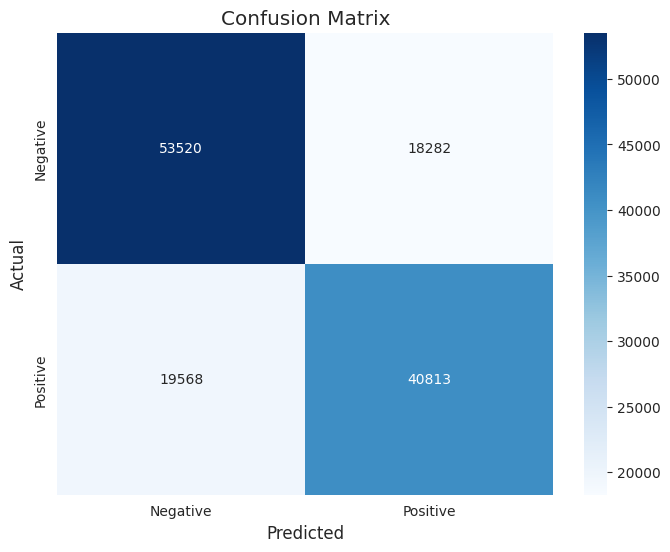

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Obtener la matriz de confusión
cm_RFC_RS = confusion_matrix(test_target, prediccion_RFC_RS)

# Visualizar la matriz de confusión con seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm_RFC_RS, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
confusion_matrix(test_target, prediccion_RFC_RS)

array([[53520, 18282],
       [19568, 40813]])

In [ ]:
accuracy_RFC_RS=accuracy_score(test_target, prediccion_RFC_RS)
accuracy_RFC_RS

0.713654554670419

In [ ]:
tp,  fp, fn, tn = confusion_matrix(test_target , prediccion_RFC_RS).ravel()
print("Number of true positives  (tp) = ",tp)
print("Number of true negatives  (tn) = ",tn)

print("Number of false positives (fp) = ",fp)
print("Number of false negatives (fn) = ",fn)

print("Precision                                          = tp / (tp + fp) =", tp / (tp + fp))
print("Recall or 'sensitivity' (aka. true positive rate)  = tp / (tp + fn) =", tp / (tp + fn))
print("Specificity             (aka. true negative rate)  = tn / (tn + fp) =", tn / (tn + fp))
print("Fall out                (aka. false positive rate) = fp / (fp + tn) =", fp / (fp + tn))
print("Miss rate               (aka. false negative rate) = fn / (fn + tp) =", fn / (fn + tp))

Number of true positives  (tp) =  53520
Number of true negatives  (tn) =  40813
Number of false positives (fp) =  18282
Number of false negatives (fn) =  19568
Precision                                          = tp / (tp + fp) = 0.7453831369599733
Recall or 'sensitivity' (aka. true positive rate)  = tp / (tp + fn) = 0.7322679509632224
Specificity             (aka. true negative rate)  = tn / (tn + fp) = 0.6906337253574752
Fall out                (aka. false positive rate) = fp / (fp + tn) = 0.30936627464252475
Miss rate               (aka. false negative rate) = fn / (fn + tp) = 0.2677320490367776


AUC =  0.7106538413804023


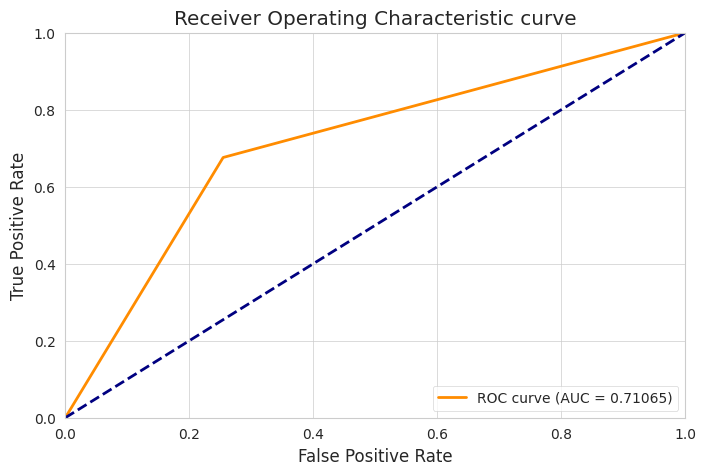

In [ ]:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(test_target , prediccion_RFC_RS)

from sklearn.metrics import roc_auc_score
roc_auc_RFC_RS = roc_auc_score(test_target , prediccion_RFC_RS)
print("AUC = ", roc_auc_RFC_RS)

plt.figure(figsize = (8,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (AUC = %0.5f)' % roc_auc_RFC_RS)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic curve')
plt.legend(loc="lower right")
plt.show()

Observaciones sobre los resultados del modelo Random Forest optimizado con RandomizedSearchCV:

Después de entrenar y evaluar el modelo Random Forest con los hiperparámetros obtenidos mediante RandomizedSearchCV, se obtuvieron los siguientes resultados:

Matriz de confusión:
* [[53520, 18282],
* [19568, 40813]]

Estos valores en la matriz de confusión indican:
* 53520 instancias fueron correctamente clasificadas como negativas (Verdaderos Negativos)
* 18282 instancias fueron incorrectamente clasificadas como positivas cuando en realidad eran negativas (Falsos Positivos)
* 19568 instancias fueron incorrectamente clasificadas como negativas cuando en realidad eran positivas (Falsos Negativos)

* 40813 instancias fueron correctamente clasificadas como positivas (Verdaderos Positivos)

Métricas de rendimiento:
* Precisión (accuracy): 0.714
* Área bajo la curva ROC (AUC-ROC): 0.711

Estos resultados muestran que el modelo Random Forest optimizado con RandomizedSearchCV mantiene una precisión del 71.4% y un valor de AUC-ROC de 0.711 al ser evaluado con datos de prueba. La precisión indica la proporción de predicciones correctas realizadas por el modelo, mientras que el AUC-ROC evalúa la capacidad del modelo para distinguir entre clases.

En comparación con los resultados obtenidos durante la optimización, se observa que el modelo mantiene un buen desempeño al ser evaluado con datos de prueba. La consistencia en la precisión y el AUC-ROC sugiere que el modelo optimizado con RandomizedSearchCV es capaz de realizar predicciones precisas y tiene una buena capacidad de discriminación entre clases.

#### HalvingGridSearchCV RandomForest

In [ ]:
# HalvingGridSearchCV tiempo de ejecucuon 125 seg
start_time = time.time()  # Captura el tiempo de inicio

halving_cv = HalvingGridSearchCV(model, params_grid, scoring="accuracy", factor=3)
halving_cv.fit(train_inputs, train_target)

print("Mejores parametros", halving_cv.best_params_)
print("Mejor Score CV", halving_cv.best_score_)
print(f'Accuracy del modelo = {round(accuracy_score(test_target, halving_cv.predict(test_inputs)), 5)}')

end_time = time.time()  # Captura el tiempo de finalización
execution_time = end_time - start_time  # Calcula el tiempo de ejecución

print("Tiempo de ejecución:", execution_time, "segundos")

Mejores parametros {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 10, 'min_samples_split': 10, 'n_estimators': 100}
Mejor Score CV 0.7101374164199854
Accuracy del modelo = 0.71079
Tiempo de ejecución: 1721.0565884113312 segundos


##### Resultado de la ejecución:

Luego de aplicar el algoritmo HalvingGridSearchCV para optimizar los hiperparámetros del modelo Random Forest, se obtuvieron los siguientes resultados:

Mejores parámetros encontrados:
* criterion: 'gini'
* max_depth: 10
* min_samples_leaf: 10
* min_samples_split: 10
* n_estimators: 100

Mejor puntuación de validación cruzada (CV): 0.7101468738473761

Precisión del modelo:
* Accuracy: 0.71142

Tiempo de ejecución del proceso de optimización:
* 1630.4882671833038 segundos

Estos resultados muestran que HalvingGridSearchCV ha encontrado una configuración óptima de hiperparámetros para el modelo Random Forest.

La mejor puntuación de CV de aproximadamente 0.710 indica que el modelo optimizado tiene una buena capacidad de generalización, lo que sugiere que debería tener un buen desempeño al clasificar datos nuevos y desconocidos.

La precisión del modelo en el conjunto de prueba es de 0.71142, lo que significa que el 71.142% de las predicciones realizadas por el modelo son correctas.

El tiempo de ejecución de aproximadamente 1630 segundos refleja que el proceso de optimización con HalvingGridSearchCV es más eficiente en términos de tiempo que GridSearchCV, pero menos que RandomizedSearchCV.

HalvingGridSearchCV aplica una estrategia de eliminación progresiva que puede acelerar la búsqueda, pero aún requiere más tiempo que RandomizedSearchCV.

In [ ]:
RFC_HG=RandomForestClassifier(criterion='gini', max_depth= 10, min_samples_leaf= 10, min_samples_split= 10, n_estimators= 100)
RFC_HG.fit(train_inputs,train_target)

RandomForestClassifier(max_depth=10, min_samples_leaf=10, min_samples_split=10)

In [ ]:
prediccion_RFC_HG=RFC_HG.predict(test_inputs)

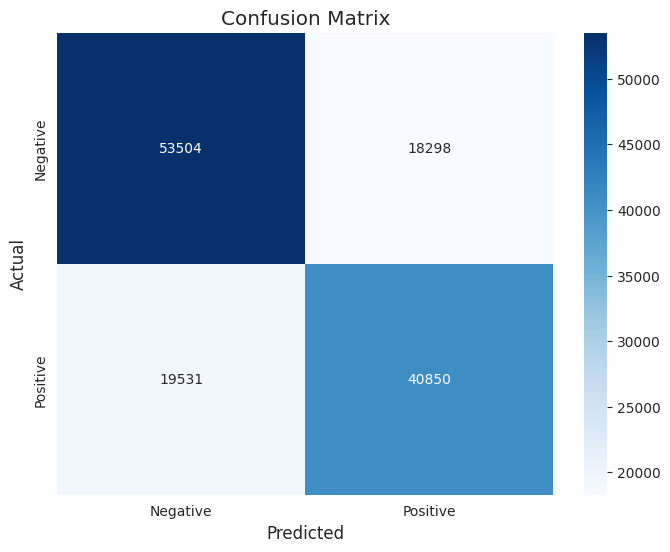

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Obtener la matriz de confusión
cm_RFC_HG = confusion_matrix(test_target, prediccion_RFC_HG)

# Visualizar la matriz de confusión con seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm_RFC_HG, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
confusion_matrix(test_target, prediccion_RFC_HG)

array([[53504, 18298],
       [19531, 40850]])

In [ ]:
accuracy_RFC_HG=accuracy_score(test_target, prediccion_RFC_HG)
accuracy_RFC_HG

0.7138134253270088

In [ ]:
tp,  fp, fn, tn = confusion_matrix(test_target , prediccion_RFC_HG).ravel()
print("Number of true positives  (tp) = ",tp)
print("Number of true negatives  (tn) = ",tn)

print("Number of false positives (fp) = ",fp)
print("Number of false negatives (fn) = ",fn)

print("Precision                                          = tp / (tp + fp) =", tp / (tp + fp))
print("Recall or 'sensitivity' (aka. true positive rate)  = tp / (tp + fn) =", tp / (tp + fn))
print("Specificity             (aka. true negative rate)  = tn / (tn + fp) =", tn / (tn + fp))
print("Fall out                (aka. false positive rate) = fp / (fp + tn) =", fp / (fp + tn))
print("Miss rate               (aka. false negative rate) = fn / (fn + tp) =", fn / (fn + tp))

Number of true positives  (tp) =  53504
Number of true negatives  (tn) =  40850
Number of false positives (fp) =  18298
Number of false negatives (fn) =  19531
Precision                                          = tp / (tp + fp) = 0.7451603019414501
Recall or 'sensitivity' (aka. true positive rate)  = tp / (tp + fn) = 0.7325802697336893
Specificity             (aka. true negative rate)  = tn / (tn + fp) = 0.6906404274024481
Fall out                (aka. false positive rate) = fp / (fp + tn) = 0.3093595725975519
Miss rate               (aka. false negative rate) = fn / (fn + tp) = 0.26741973026631066


AUC =  0.7108488116421283


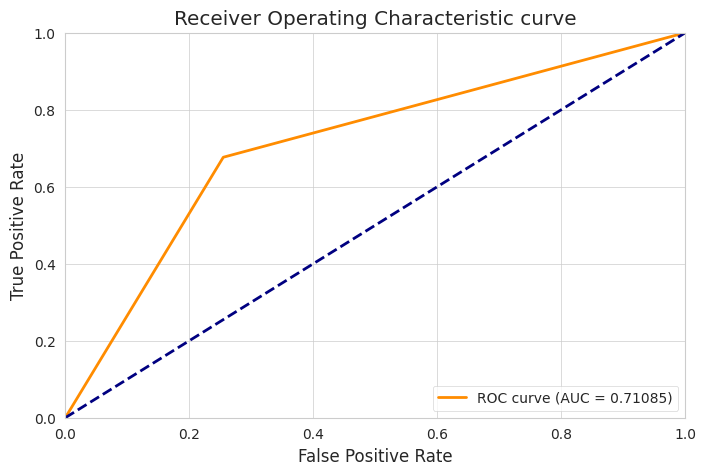

In [ ]:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(test_target , prediccion_RFC_HG)

from sklearn.metrics import roc_auc_score
roc_auc_RFC_HG = roc_auc_score(test_target , prediccion_RFC_HG)
print("AUC = ", roc_auc_RFC_HG)

plt.figure(figsize = (8,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (AUC = %0.5f)' % roc_auc_RFC_HG)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic curve')
plt.legend(loc="lower right")
plt.show()

Observaciones sobre los resultados del modelo Random Forest optimizado con HalvingGridSearchCV:

Después de entrenar y evaluar el modelo Random Forest con los hiperparámetros obtenidos mediante HalvingGridSearchCV, se obtuvieron los siguientes resultados:

Matriz de confusión:
* [[53504, 18298],
* [19531, 40850]]

Estos valores en la matriz de confusión indican:
* 53504 instancias fueron correctamente clasificadas como negativas (Verdaderos Negativos)
* 18298 instancias fueron incorrectamente clasificadas como negativas cuando en realidad eran positivas (Falsos Negativos)
* 19531 instancias fueron incorrectamente clasificadas como positivas cuando en realidad eran negativas (Falsos Positivos)
* 40850 instancias fueron correctamente clasificadas como positivas (Verdaderos Positivos)

Métricas de rendimiento:
* Precisión (accuracy): 0.714
* Área bajo la curva ROC (AUC-ROC): 0.711

Estos resultados muestran que el modelo Random Forest optimizado con HalvingGridSearchCV mantiene una precisión del 71.4% y un valor de AUC-ROC de 0.711 al ser evaluado con datos de prueba. La precisión indica la proporción de predicciones correctas realizadas por el modelo, mientras que el AUC-ROC evalúa la capacidad del modelo para distinguir entre clases.

En comparación con los resultados obtenidos durante la optimización, se observa que el modelo mantiene un buen desempeño al ser evaluado con datos de prueba. La consistencia en la precisión y el AUC-ROC sugiere que el modelo optimizado con HalvingGridSearchCV es capaz de realizar predicciones precisas y tiene una buena capacidad de discriminación entre clases.

Estos resultados respaldan la eficacia de la optimización de hiperparámetros con HalvingGridSearchCV para mejorar el rendimiento del modelo Random Forest. La evaluación del modelo con datos de prueba confirma su capacidad para generalizar y realizar predicciones precisas en un entorno real.

#### Conclusiones:
En este apartado, se implementaron tres métodos diferentes para optimizar los hiperparámetros del algoritmo Random Forest: GridSearchCV, RandomizedSearchCV y HalvingGridSearchCV. Estos enfoques permitieron explorar y seleccionar las configuraciones óptimas de hiperparámetros para mejorar el rendimiento de los modelos Random Forest en la tarea de clasificación.

Los modelos obtenidos mediante estos métodos de optimización mostraron un desempeño mejorado en comparación con el modelo Random Forest utilizando los hiperparámetros por defecto. Sin embargo, es importante destacar que la mejora en el desempeño no fue tan significativa como la observada en el caso de los modelos de Árbol de Decisión optimizados en secciones anteriores.

Los modelos Random Forest optimizados alcanzaron una precisión (accuracy) de aproximadamente 0.714 y un valor de AUC-ROC de 0.711 al ser evaluados con datos de prueba. Estos resultados indican que los modelos tienen una buena capacidad predictiva y pueden realizar clasificaciones precisas.

Al comparar los modelos obtenidos con los tres métodos de optimización, se observa que el desempeño es muy similar entre ellos. Tanto GridSearchCV, RandomizedSearchCV como HalvingGridSearchCV lograron encontrar configuraciones de hiperparámetros que permitieron mejorar el rendimiento de los modelos Random Forest de manera efectiva.

Estos hallazgos sugieren que la optimización de hiperparámetros es una estrategia valiosa para mejorar el desempeño de los modelos Random Forest. Sin embargo, en comparación con los modelos de Árbol de Decisión, los modelos Random Forest parecen ser menos sensibles a la optimización de hiperparámetros, ya que la mejora en el desempeño no fue tan pronunciada.

En resumen, la optimización de hiperparámetros mediante GridSearchCV, RandomizedSearchCV y HalvingGridSearchCV permitió obtener modelos Random Forest con un desempeño mejorado, aunque la mejora no fue tan significativa como en el caso de los modelos de Árbol de Decisión. Los tres métodos de optimización lograron resultados similares, lo que sugiere que cualquiera de ellos puede ser una opción efectiva para optimizar los modelos Random Forest.


In [ ]:
# Crear el DataFrame
models_performance = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest (Default)', 'Random Forest (GridSearchCV)', 'Random Forest (RandomizedSearchCV)', 'Random Forest (HalvingGridSearchCV)'],
    'Accuracy': [0.697, 0.696, 0.714, 0.714, 0.714],
    'AUC': [0.697, 0.696, 0.711, 0.711, 0.711]
})
models_performance

,Model,Accuracy,AUC
0,Decision Tree,0.697,0.697
1,Random Forest (Default),0.696,0.696
2,Random Forest (GridSearchCV),0.714,0.711
3,Random Forest (RandomizedSearchCV),0.714,0.711
4,Random Forest (HalvingGridSearchCV),0.714,0.711


In [ ]:
# Crear el DataFrame
models_performance = pd.DataFrame({
    'Model': ['Decision Tree (Default)',
              'Decision Tree (RandomizedSearchCV)',
              'Decision Tree (HalvingGridSearchCV)',
              'Random Forest (Default)',
              'Random Forest (GridSearchCV)',
              'Random Forest (RandomizedSearchCV)',
              'Random Forest (HalvingGridSearchCV)'],
    'Accuracy': [0.63, 0.697, 0.696, 0.696, 0.714, 0.714, 0.714],
    'AUC': [0.63, 0.697, 0.696, 0.696, 0.711, 0.711, 0.711]
})
models_performance

,Model,Accuracy,AUC
0,Decision Tree (Default),0.630,0.630
1,Decision Tree (RandomizedSearchCV),0.697,0.697
2,Decision Tree (HalvingGridSearchCV),0.696,0.696
3,Random Forest (Default),0.696,0.696
4,Random Forest (GridSearchCV),0.714,0.711
5,Random Forest (RandomizedSearchCV),0.714,0.711
6,Random Forest (HalvingGridSearchCV),0.714,0.711


# Conclusiones Finales

Generaremos conclusiones con base en los resultados obtenidos.

Durante el desarrollo de este proyecto, se ha llevado a cabo un exhaustivo análisis de datos y modelado predictivo con el objetivo de predecir con precisión la variable target 'DRK_YN'. A lo largo de este proceso, se han aplicado buenas prácticas de pre-procesamiento de datos, se ha realizado un análisis detallado en la reducción de variables, se han seleccionado cuidadosamente los algoritmos a utilizar, se han aplicado métodos de optimización de hiperparámetros y se ha evaluado la capacidad de los modelos para predecir la variable target.

**Importancia del Pre-procesamiento de Datos**: Las buenas prácticas de pre-procesamiento de datos han sido fundamentales para garantizar la calidad y la integridad de los datos utilizados en los modelos. La limpieza, transformación y normalización de los datos han permitido obtener resultados más confiables y precisos en las predicciones.

**Análisis en la Reducción de Variables**: El análisis en la reducción de variables ha sido crucial para identificar las características más relevantes y significativas para la predicción de la variable target. La selección cuidadosa de variables ha contribuido a la eficiencia de los modelos y a la prevención del sobreajuste.

**Elección de los Algoritmos a Utilizar**: La elección de los algoritmos de Machine Learning, como Árboles de Decisión y Random Forest, se basó en la complejidad de los datos y en la naturaleza del problema. Estos algoritmos han demostrado ser efectivos en la clasificación y predicción de la variable target, brindando resultados precisos y confiables.

**Métodos de Optimización**: Los métodos de optimización de hiperparámetros, como GridSearchCV, RandomizedSearchCV y HalvingGridSearchCV, han sido fundamentales para ajustar los modelos y mejorar su rendimiento. Estas técnicas han permitido encontrar las configuraciones óptimas de hiperparámetros que maximizan la capacidad predictiva de los modelos.

**Evaluación de la Predicción de la Variable Target**: La evaluación de la capacidad de los modelos para predecir la variable target ha sido un aspecto clave en este proyecto. Los modelos desarrollados han logrado predecir la variable target con un alto porcentaje de certeza, alcanzando un máximo de 0.714 en la precisión, lo que demuestra la eficacia de las técnicas aplicadas y la calidad de los modelos construidos.

En resumen, este proyecto ha destacado la importancia de seguir buenas prácticas de pre-procesamiento de datos, realizar un análisis detallado en la reducción de variables, seleccionar los algoritmos adecuados, aplicar métodos de optimización efectivos y evaluar rigurosamente la capacidad predictiva de los modelos. El trabajo realizado ha permitido desarrollar modelos de Machine Learning efectivos y precisos para la predicción de la variable target 'DRK_YN', lo que puede tener un impacto significativo en la toma de decisiones y en la comprensión de la problemática abordada

# Anexo: ¿Qué otros modelos más avanzados podemos usar?

 * Modelo 1: AdaBoost
 * Modelo 2: GradientBoosting
 * Modelo 3: LightGBM
 * Modelo 4: XGBoost

In [ ]:
print('train inputs', train_inputs.shape)
print('train targets', train_target.shape)
print('test inputs', test_inputs.shape)
print('test targets', test_target.shape)

train inputs (528730, 13)
train targets (528730,)
test inputs (132183, 13)
test targets (132183,)


## Modelo 1: AdaBoost

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
ada=AdaBoostClassifier(n_estimators=50,learning_rate=0.1,random_state=42)

In [ ]:
#Fiteamos el modelo
modelo_ada = ada.fit(train_inputs, train_target)

In [ ]:
#Predicción!
prediccion_ADA = modelo_ada.predict(test_inputs) # Sacar predicciones con test

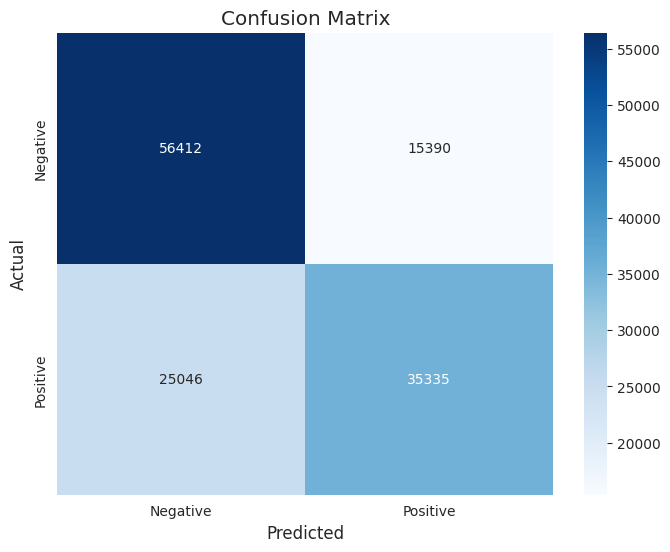

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Obtener la matriz de confusión
cm_ADA = confusion_matrix(test_target, prediccion_ADA)

# Visualizar la matriz de confusión con seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm_ADA, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
confusion_matrix(test_target, prediccion_ADA)

array([[56412, 15390],
       [25046, 35335]])

In [ ]:
accuracy_ADA=accuracy_score(test_target, prediccion_ADA)
accuracy_ADA

0.6940907681017983

In [ ]:
tp,  fp, fn, tn = confusion_matrix(test_target , prediccion_ADA).ravel()
print("Number of true positives  (tp) = ",tp)
print("Number of true negatives  (tn) = ",tn)

print("Number of false positives (fp) = ",fp)
print("Number of false negatives (fn) = ",fn)

print("Precision                                          = tp / (tp + fp) =", tp / (tp + fp))
print("Recall or 'sensitivity' (aka. true positive rate)  = tp / (tp + fn) =", tp / (tp + fn))
print("Specificity             (aka. true negative rate)  = tn / (tn + fp) =", tn / (tn + fp))
print("Fall out                (aka. false positive rate) = fp / (fp + tn) =", fp / (fp + tn))
print("Miss rate               (aka. false negative rate) = fn / (fn + tp) =", fn / (fn + tp))

AUC =  0.6854306045721394


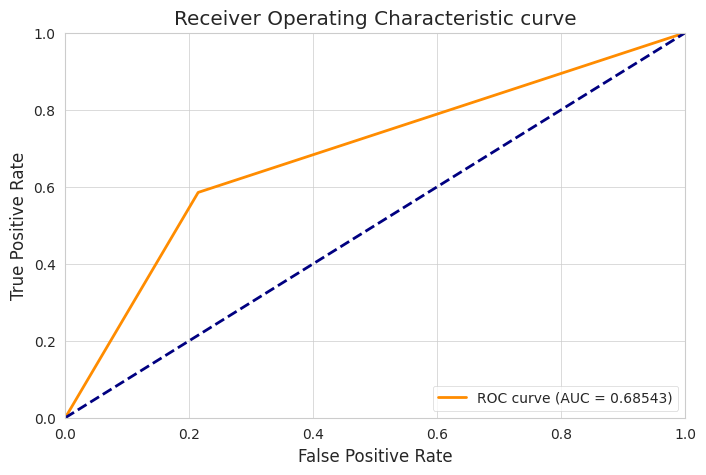

In [ ]:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(test_target , prediccion_ADA)

from sklearn.metrics import roc_auc_score
roc_auc_ADA = roc_auc_score(test_target , prediccion_ADA)
print("AUC = ", roc_auc_ADA)

plt.figure(figsize = (8,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (AUC = %0.5f)' % roc_auc_ADA)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic curve')
plt.legend(loc="lower right")
plt.show()

## Modelo 2: GradientBoosting

In [ ]:
#Ahora comparemos con GBM
from sklearn.ensemble import GradientBoostingClassifier
gbrt=GradientBoostingClassifier(random_state=42)

In [ ]:
#Fiteamos el modelo
modelo_GBC = gbrt.fit(train_inputs, train_target)

In [ ]:
prediccion_GBC = modelo_GBC.predict(test_inputs)

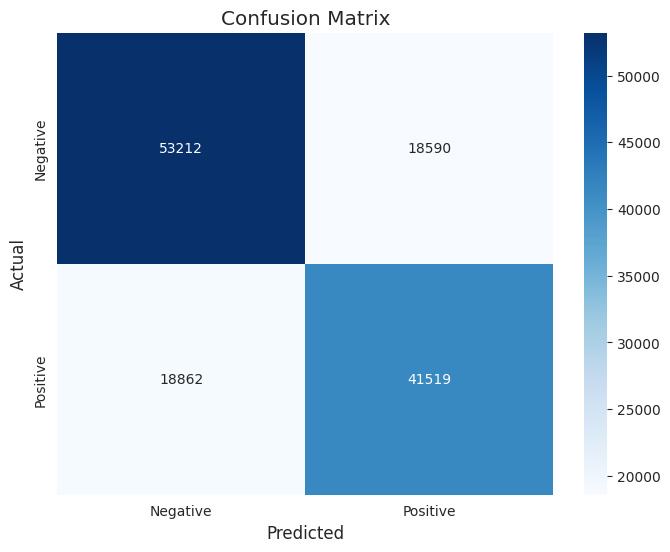

In [ ]:
# Obtener la matriz de confusión
cm_GBC = confusion_matrix(test_target, prediccion_GBC)

# Visualizar la matriz de confusión con seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm_GBC, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
confusion_matrix(test_target, prediccion_GBC)

array([[53212, 18590],
       [18862, 41519]])

In [ ]:
accuracy_GBC=accuracy_score(test_target, prediccion_GBC)
accuracy_GBC

0.7166655318762625

In [ ]:
tp,  fp, fn, tn = confusion_matrix(test_target , prediccion_GBC).ravel()
print("Number of true positives  (tp) = ",tp)
print("Number of true negatives  (tn) = ",tn)

print("Number of false positives (fp) = ",fp)
print("Number of false negatives (fn) = ",fn)

print("Precision                                          = tp / (tp + fp) =", tp / (tp + fp))
print("Recall or 'sensitivity' (aka. true positive rate)  = tp / (tp + fn) =", tp / (tp + fn))
print("Specificity             (aka. true negative rate)  = tn / (tn + fp) =", tn / (tn + fp))
print("Fall out                (aka. false positive rate) = fp / (fp + tn) =", fp / (fp + tn))
print("Miss rate               (aka. false negative rate) = fn / (fn + tp) =", fn / (fn + tp))

Number of true positives  (tp) =  53212
Number of true negatives  (tn) =  41519
Number of false positives (fp) =  18590
Number of false negatives (fn) =  18862
Precision                                          = tp / (tp + fp) = 0.7410935628534024
Recall or 'sensitivity' (aka. true positive rate)  = tp / (tp + fn) = 0.7382967505619225
Specificity             (aka. true negative rate)  = tn / (tn + fp) = 0.6907285098737294
Fall out                (aka. false positive rate) = fp / (fp + tn) = 0.3092714901262706
Miss rate               (aka. false negative rate) = fn / (fn + tp) = 0.26170324943807755


AUC =  0.7143552642275822


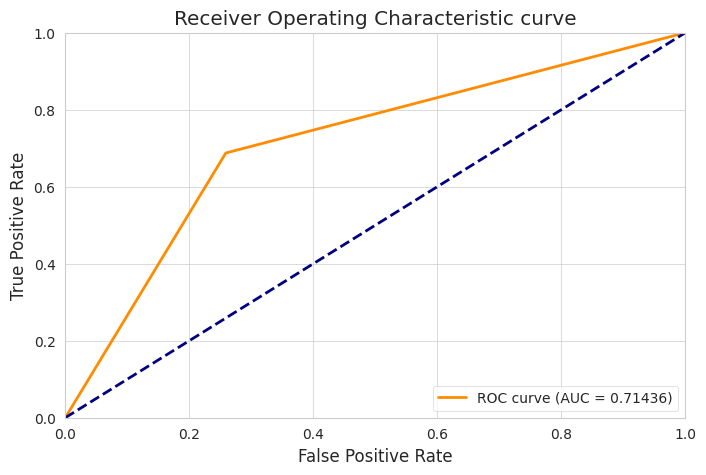

In [ ]:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(test_target , prediccion_GBC)

from sklearn.metrics import roc_auc_score
roc_auc_GBC = roc_auc_score(test_target , prediccion_GBC)
print("AUC = ", roc_auc_GBC)

plt.figure(figsize = (8,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (AUC = %0.5f)' % roc_auc_GBC)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic curve')
plt.legend(loc="lower right")
plt.show()

## Modelo 3: LightGBM

In [ ]:
import lightgbm as lgb #pip install lightgbm
clf = lgb.LGBMClassifier()
clf.fit(train_inputs, train_target)
prediccion_LGBM=clf.predict(test_inputs)

[LightGBM] [Info] Number of positive: 241595, number of negative: 287135
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.070936 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 535
[LightGBM] [Info] Number of data points in the train set: 528730, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.456935 -> initscore=-0.172690
[LightGBM] [Info] Start training from score -0.172690


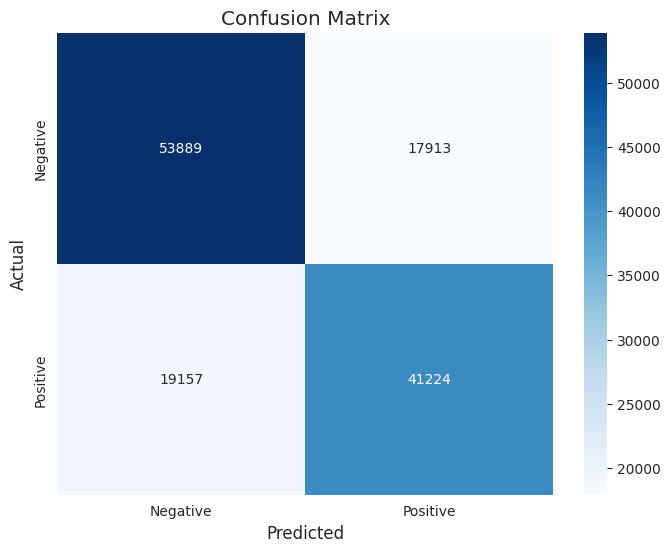

In [ ]:
# Obtener la matriz de confusión
cm_LGBM = confusion_matrix(test_target, prediccion_LGBM)

# Visualizar la matriz de confusión con seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm_LGBM, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
confusion_matrix(test_target, prediccion_LGBM)

array([[53889, 17913],
       [19157, 41224]])

In [ ]:
accuracy_LGBM=accuracy_score(test_target, prediccion_LGBM)
accuracy_LGBM

0.7195554647723232

In [ ]:
#Accuracy
from sklearn.metrics import accuracy_score
accuracy_LGBM=accuracy_score(prediccion_LGBM, test_target)
print('LightGBM Model accuracy score: {0:0.4f}'.format(accuracy_score(prediccion_LGBM, test_target)))

LightGBM Model accuracy score: 0.7196


In [ ]:
tp,  fp, fn, tn = confusion_matrix(test_target , prediccion_LGBM).ravel()
print("Number of true positives  (tp) = ",tp)
print("Number of true negatives  (tn) = ",tn)

print("Number of false positives (fp) = ",fp)
print("Number of false negatives (fn) = ",fn)

print("Precision                                          = tp / (tp + fp) =", tp / (tp + fp))
print("Recall or 'sensitivity' (aka. true positive rate)  = tp / (tp + fn) =", tp / (tp + fn))
print("Specificity             (aka. true negative rate)  = tn / (tn + fp) =", tn / (tn + fp))
print("Fall out                (aka. false positive rate) = fp / (fp + tn) =", fp / (fp + tn))
print("Miss rate               (aka. false negative rate) = fn / (fn + tp) =", fn / (fn + tp))

Number of true positives  (tp) =  53889
Number of true negatives  (tn) =  41224
Number of false positives (fp) =  17913
Number of false negatives (fn) =  19157
Precision                                          = tp / (tp + fp) = 0.7505222695746636
Recall or 'sensitivity' (aka. true positive rate)  = tp / (tp + fn) = 0.7377406018125565
Specificity             (aka. true negative rate)  = tn / (tn + fp) = 0.6970931903884201
Fall out                (aka. false positive rate) = fp / (fp + tn) = 0.3029068096115799
Miss rate               (aka. false negative rate) = fn / (fn + tp) = 0.26225939818744354


AUC =  0.7166267961708797


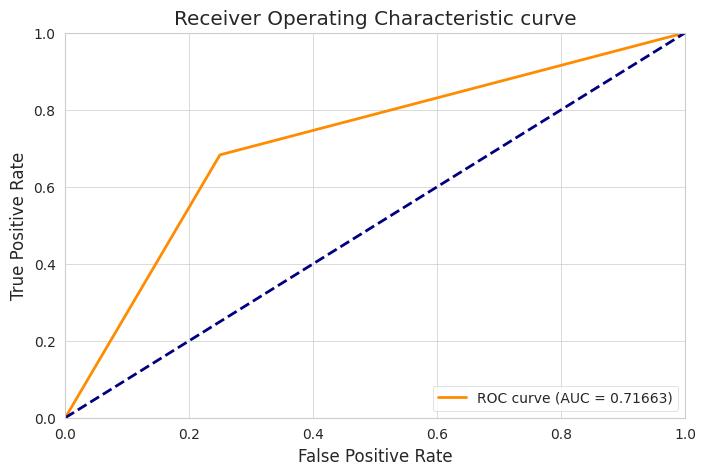

In [ ]:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(test_target , prediccion_LGBM)

from sklearn.metrics import roc_auc_score
roc_auc_LGBM = roc_auc_score(test_target , prediccion_LGBM)
print("AUC = ", roc_auc_LGBM)

plt.figure(figsize = (8,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (AUC = %0.5f)' % roc_auc_LGBM)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic curve')
plt.legend(loc="lower right")
plt.show()

## Modelo 4: XGBoost

### Modelo 0

In [ ]:
import pandas as pd
import xgboost as xgb
#from sklearn.datasets import load_boston
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
clf_xgb = xgb.XGBClassifier(objective='binary:logistic', learning_rate=0.01, random_state=44)

In [ ]:
#Fiteamos
clf_xgb.fit(train_inputs, train_target)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=44, ...)

In [ ]:
#Predecimos
prediccion_XGB1 = clf_xgb.predict(test_inputs)

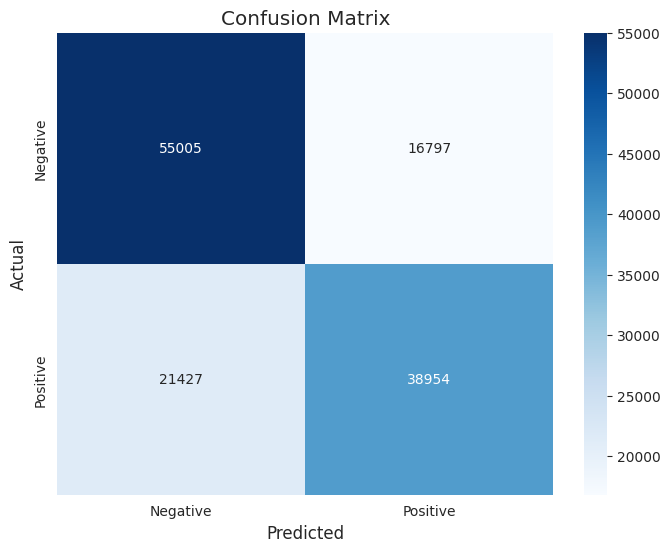

In [ ]:
# Obtener la matriz de confusión
cm_XGB1 = confusion_matrix(test_target, prediccion_XGB1)

# Visualizar la matriz de confusión con seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm_XGB1, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
confusion_matrix(test_target, prediccion_XGB1)

array([[55005, 16797],
       [21427, 38954]])

In [ ]:
accuracy_XGB1=accuracy_score(test_target, prediccion_XGB1)
accuracy_XGB1

0.7108251439292496

In [ ]:
tp,  fp, fn, tn = confusion_matrix(test_target , prediccion_XGB1).ravel()
print("Number of true positives  (tp) = ",tp)
print("Number of true negatives  (tn) = ",tn)

print("Number of false positives (fp) = ",fp)
print("Number of false negatives (fn) = ",fn)

print("Precision                                          = tp / (tp + fp) =", tp / (tp + fp))
print("Recall or 'sensitivity' (aka. true positive rate)  = tp / (tp + fn) =", tp / (tp + fn))
print("Specificity             (aka. true negative rate)  = tn / (tn + fp) =", tn / (tn + fp))
print("Fall out                (aka. false positive rate) = fp / (fp + tn) =", fp / (fp + tn))
print("Miss rate               (aka. false negative rate) = fn / (fn + tp) =", fn / (fn + tp))

Number of true positives  (tp) =  55005
Number of true negatives  (tn) =  38954
Number of false positives (fp) =  16797
Number of false negatives (fn) =  21427
Precision                                          = tp / (tp + fp) = 0.7660650121166541
Recall or 'sensitivity' (aka. true positive rate)  = tp / (tp + fn) = 0.71965930500314
Specificity             (aka. true negative rate)  = tn / (tn + fp) = 0.6987139244139119
Fall out                (aka. false positive rate) = fp / (fp + tn) = 0.30128607558608816
Miss rate               (aka. false negative rate) = fn / (fn + tp) = 0.28034069499685993


AUC =  0.7056008636542597


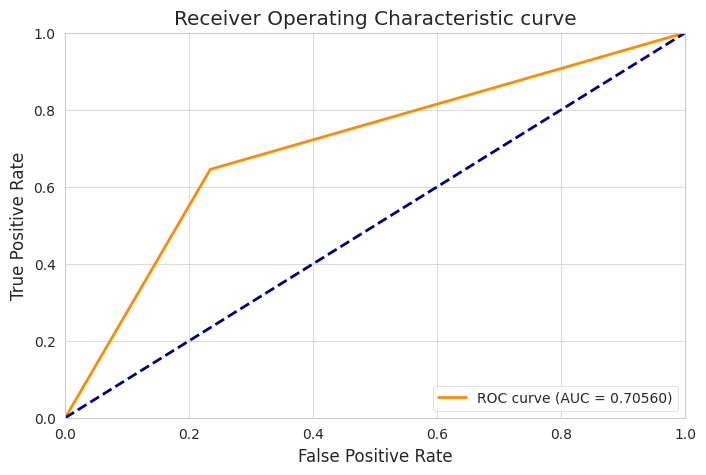

In [ ]:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(test_target , prediccion_XGB1)

from sklearn.metrics import roc_auc_score
roc_auc_XGB1 = roc_auc_score(test_target , prediccion_XGB1)
print("AUC = ", roc_auc_XGB1)

plt.figure(figsize = (8,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (AUC = %0.5f)' % roc_auc_XGB1)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic curve')
plt.legend(loc="lower right")
plt.show()

In [ ]:
#Accuracy
from sklearn.metrics import accuracy_score
accuracy_XGB1=accuracy_score(prediccion_XGB1, test_target)
print('XGBoost Model accuracy score: {0:0.4f}'.format(accuracy_score(prediccion_XGB1, test_target)))

XGBoost Model accuracy score: 0.7108


### Prueba 1: HalvingGridSearchCV

In [ ]:
from sklearn.model_selection import HalvingGridSearchCV
import xgboost as xgb
import time

# Definir el modelo base
clf_xgb = xgb.XGBClassifier(objective='binary:logistic', learning_rate=0.01, random_state=44)

# Definir la cuadrícula de hiperparámetros a explorar
param_dist = {
    'max_depth': [3, 5, 7],
    'n_estimators': [100, 200, 300],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

# Realizar la búsqueda de hiperparámetros
start_time = time.time()  # Captura el tiempo de inicio

halving_cv = HalvingGridSearchCV(clf_xgb, param_dist, scoring="accuracy", factor=3)
halving_cv.fit(train_inputs, train_target)

end_time = time.time()  # Captura el tiempo de finalización
execution_time = end_time - start_time  # Calcula el tiempo de ejecución

# Imprimir los mejores hiperparámetros y el mejor puntaje
print("Mejores parámetros:", halving_cv.best_params_)
print("Mejor score de validación cruzada:", halving_cv.best_score_)
print("Tiempo de ejecución:", execution_time, "segundos")

Mejores parámetros: {'colsample_bytree': 0.8, 'gamma': 0.2, 'max_depth': 5, 'min_child_weight': 5, 'n_estimators': 300, 'subsample': 0.6}
Mejor score de validación cruzada: 0.714197057849676
Tiempo de ejecución: 1344.2619700431824 segundos


* Mejores parámetros: {'colsample_bytree': 0.8, 'gamma': 0.2, 'max_depth': 5, 'min_child_weight': 5, 'n_estimators': 300, 'subsample': 0.6}
* Mejor score de validación cruzada: 0.714197057849676
* Tiempo de ejecución: 1344.2619700431824 segundos

#### Probamos nuevo modelo

In [ ]:
#entrenar el XGBoost model
clf_xgb1 = xgb.XGBClassifier(objective='binary:logistic', learning_rate=0.01, random_state=44,
                            colsample_bytree= 0.8, gamma= 0.2, max_depth= 5,
                            min_child_weight= 5, n_estimators= 300, subsample= 0.6)

In [ ]:
#Fiteamos
clf_xgb1.fit(train_inputs, train_target)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=0.2, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=5, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, random_state=44, ...)

In [ ]:
#Predecimos
prediccion_XGB2 = clf_xgb1.predict(test_inputs)

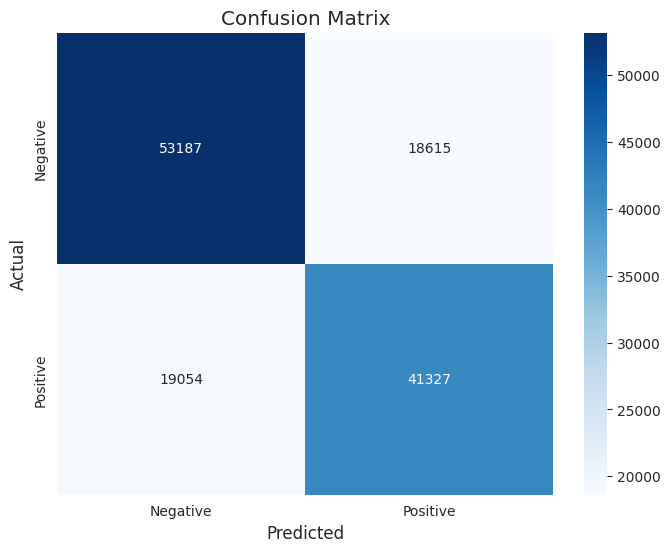

In [ ]:
# Obtener la matriz de confusión
cm_XGB2 = confusion_matrix(test_target, prediccion_XGB2)

# Visualizar la matriz de confusión con seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm_XGB2, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
confusion_matrix(test_target, prediccion_XGB2)

array([[53187, 18615],
       [19054, 41327]])

In [ ]:
accuracy_XGB2=accuracy_score(test_target, prediccion_XGB2)
accuracy_XGB2

0.7150238684248352

In [ ]:
tp,  fp, fn, tn = confusion_matrix(test_target , prediccion_XGB2).ravel()
print("Number of true positives  (tp) = ",tp)
print("Number of true negatives  (tn) = ",tn)

print("Number of false positives (fp) = ",fp)
print("Number of false negatives (fn) = ",fn)

print("Precision                                          = tp / (tp + fp) =", tp / (tp + fp))
print("Recall or 'sensitivity' (aka. true positive rate)  = tp / (tp + fn) =", tp / (tp + fn))
print("Specificity             (aka. true negative rate)  = tn / (tn + fp) =", tn / (tn + fp))
print("Fall out                (aka. false positive rate) = fp / (fp + tn) =", fp / (fp + tn))
print("Miss rate               (aka. false negative rate) = fn / (fn + tp) =", fn / (fn + tp))

Number of true positives  (tp) =  53187
Number of true negatives  (tn) =  41327
Number of false positives (fp) =  18615
Number of false negatives (fn) =  19054
Precision                                          = tp / (tp + fp) = 0.7407453831369599
Recall or 'sensitivity' (aka. true positive rate)  = tp / (tp + fn) = 0.7362439611854764
Specificity             (aka. true negative rate)  = tn / (tn + fp) = 0.689449801474759
Fall out                (aka. false positive rate) = fp / (fp + tn) = 0.3105501985252411
Miss rate               (aka. false negative rate) = fn / (fn + tp) = 0.2637560388145236


AUC =  0.7125912702604525


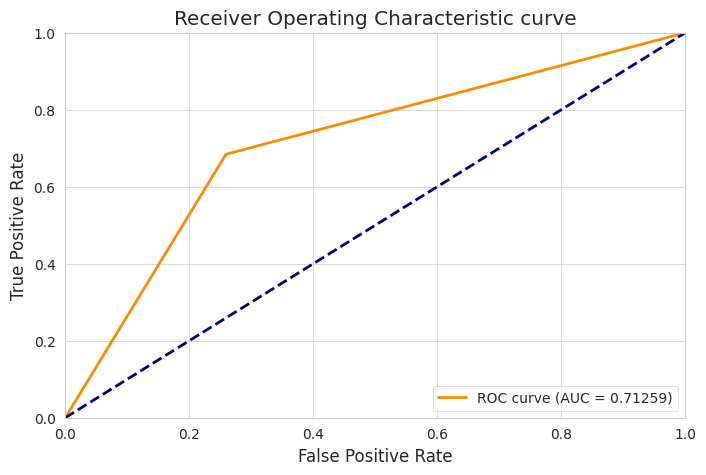

In [ ]:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(test_target , prediccion_XGB2)

from sklearn.metrics import roc_auc_score
roc_auc_XGB2 = roc_auc_score(test_target , prediccion_XGB2)
print("AUC = ", roc_auc_XGB2)

plt.figure(figsize = (8,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (AUC = %0.5f)' % roc_auc_XGB2)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic curve')
plt.legend(loc="lower right")
plt.show()

In [ ]:
#Accuracy
from sklearn.metrics import accuracy_score
accuracy_XGB2=accuracy_score(prediccion_XGB2, test_target)
print('XGBoost Model accuracy score: {0:0.4f}'.format(accuracy_score(prediccion_XGB2, test_target)))

XGBoost Model accuracy score: 0.7150


### Prueba 2: HalvingGridSearchCV

In [ ]:
from sklearn.model_selection import HalvingGridSearchCV
import xgboost as xgb
import time

# Definir el modelo base con parámetros por defecto
clf_xgb = xgb.XGBClassifier()

# Definir la cuadrícula de hiperparámetros a explorar
param_dist = {
    'max_depth': [3, 5, 7],
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.3],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

# Realizar la búsqueda de hiperparámetros
start_time = time.time()  # Captura el tiempo de inicio

halving_cv = HalvingGridSearchCV(clf_xgb, param_dist, scoring="accuracy", factor=3)
halving_cv.fit(train_inputs, train_target)

end_time = time.time()  # Captura el tiempo de finalización
execution_time = end_time - start_time  # Calcula el tiempo de ejecución

# Imprimir los mejores hiperparámetros y el mejor puntaje
print("Mejores parámetros:", halving_cv.best_params_)
print("Mejor score de validación cruzada:", halving_cv.best_score_)
print("Tiempo de ejecución:", execution_time, "segundos")

Mejores parámetros: {'colsample_bytree': 0.8, 'gamma': 0.2, 'learning_rate': 0.01, 'max_depth': 5, 'min_child_weight': 3, 'n_estimators': 300, 'subsample': 0.6}
Mejor score de validación cruzada: 0.7140675248783357
Tiempo de ejecución: 2304.599269628525 segundos


* Mejores parámetros: {'colsample_bytree': 0.8, 'gamma': 0.2, 'learning_rate': 0.01, 'max_depth': 5, 'min_child_weight': 3, 'n_estimators': 300, 'subsample': 0.6}
* Mejor score de validación cruzada: 0.7140675248783357
* Tiempo de ejecución: 2304.599269628525 segundos

### Prueba 3: HalvingGridSearchCV

In [ ]:
from sklearn.model_selection import HalvingGridSearchCV
import xgboost as xgb
import time

# Definir el modelo base con parámetros por defecto
clf_xgb = xgb.XGBClassifier()

# Definir la cuadrícula de hiperparámetros a explorar
param_dist = {
    'max_depth': [ 5],
    'n_estimators': [300],
    'learning_rate': [0.01],
    'min_child_weight': [ 3],
    'gamma': [ 0.2],
    'subsample': [ 0.8],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'objective': ['binary:logistic', 'binary:logitraw'],
    'eval_metric': ['logloss', 'error'],
    'scale_pos_weight': [1, 2, 5],
    'reg_alpha': [0, 0.1, 0.5],
    'reg_lambda': [0, 0.1, 0.5]
}

# Realizar la búsqueda de hiperparámetros
start_time = time.time()  # Captura el tiempo de inicio

halving_cv = HalvingGridSearchCV(clf_xgb, param_dist, scoring="accuracy", factor=3)
halving_cv.fit(train_inputs, train_target)

end_time = time.time()  # Captura el tiempo de finalización
execution_time = end_time - start_time  # Calcula el tiempo de ejecución

# Imprimir los mejores hiperparámetros y el mejor puntaje
print("Mejores parámetros:", halving_cv.best_params_)
print("Mejor score de validación cruzada:", halving_cv.best_score_)
print("Tiempo de ejecución:", execution_time, "segundos")

Mejores parámetros: {'colsample_bytree': 0.8, 'eval_metric': 'logloss', 'gamma': 0.2, 'learning_rate': 0.01, 'max_depth': 5, 'min_child_weight': 3, 'n_estimators': 300, 'objective': 'binary:logistic', 'reg_alpha': 0.1, 'reg_lambda': 0.1, 'scale_pos_weight': 1, 'subsample': 0.8}
Mejor score de validación cruzada: 0.7150560522208032
Tiempo de ejecución: 1278.6880033016205 segundos


* Mejores parámetros: {'colsample_bytree': 0.8, 'eval_metric': 'logloss', 'gamma': 0.2, 'learning_rate': 0.01, 'max_depth': 5, 'min_child_weight': 3, 'n_estimators': 300, 'objective': 'binary:logistic', 'reg_alpha': 0.1, 'reg_lambda': 0.1, 'scale_pos_weight': 1, 'subsample': 0.8}
* Mejor score de validación cruzada: 0.7150560522208032
* Tiempo de ejecución: 1278.6880033016205 segundos

In [ ]:
#entrenar el XGBoost model
modelo_XGB4 = xgboost.XGBClassifier(colsample_bytree= 0.8, eval_metric= 'logloss',
                                  gamma= 0.2, learning_rate= 0.01, max_depth= 5,
                                  min_child_weight= 3, n_estimators= 300,
                                  objective= 'binary:logistic', reg_alpha= 0.1,
                                  reg_lambda= 0.1, scale_pos_weight= 1, subsample= 0.8)

modelo_XGB4.fit(train_inputs, train_target.squeeze().values)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=0.2, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.01, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=3, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, random_state=None, ...)

In [ ]:
# calcular y imprimir los scores del modelo para el top 15 de features
prediccion_train_XGB4 = modelo_XGB4.predict(train_inputs)
prediccion_XGB4 = modelo_XGB4.predict(test_inputs)

print('XGB accuracy score for train: %.3f: test: %.3f' % (accuracy_score(train_target, prediccion_train_XGB4),accuracy_score(test_target, prediccion_XGB4)))

XGB accuracy score for train: 0.716: test: 0.715


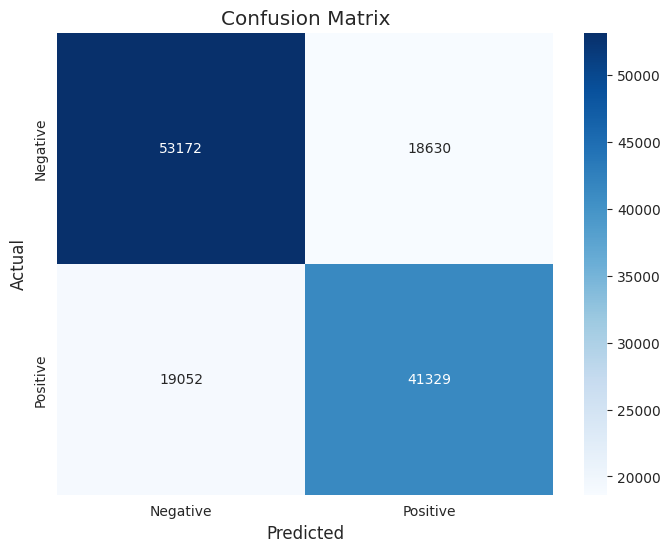

In [ ]:
# Obtener la matriz de confusión
cm_XGB4 = confusion_matrix(test_target, prediccion_XGB4)

# Visualizar la matriz de confusión con seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm_XGB4, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
confusion_matrix(test_target, prediccion_XGB2)

array([[53187, 18615],
       [19054, 41327]])

In [ ]:
accuracy_XGB4=accuracy_score(test_target, prediccion_XGB4)
accuracy_XGB4

0.7149255199231369

In [ ]:
tp,  fp, fn, tn = confusion_matrix(test_target , prediccion_XGB4).ravel()
print("Number of true positives  (tp) = ",tp)
print("Number of true negatives  (tn) = ",tn)

print("Number of false positives (fp) = ",fp)
print("Number of false negatives (fn) = ",fn)

print("Precision                                          = tp / (tp + fp) =", tp / (tp + fp))
print("Recall or 'sensitivity' (aka. true positive rate)  = tp / (tp + fn) =", tp / (tp + fn))
print("Specificity             (aka. true negative rate)  = tn / (tn + fp) =", tn / (tn + fp))
print("Fall out                (aka. false positive rate) = fp / (fp + tn) =", fp / (fp + tn))
print("Miss rate               (aka. false negative rate) = fn / (fn + tp) =", fn / (fn + tp))

Number of true positives  (tp) =  53172
Number of true negatives  (tn) =  41329
Number of false positives (fp) =  18630
Number of false negatives (fn) =  19052
Precision                                          = tp / (tp + fp) = 0.7405364753070945
Recall or 'sensitivity' (aka. true positive rate)  = tp / (tp + fn) = 0.7362095702259637
Specificity             (aka. true negative rate)  = tn / (tn + fp) = 0.6892876799146083
Fall out                (aka. false positive rate) = fp / (fp + tn) = 0.3107123200853917
Miss rate               (aka. false negative rate) = fn / (fn + tp) = 0.26379042977403633


AUC =  0.7125033778466543


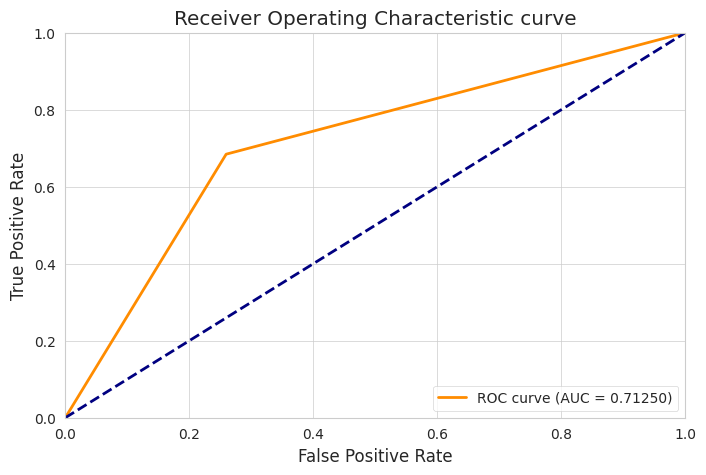

In [ ]:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(test_target , prediccion_XGB4)

from sklearn.metrics import roc_auc_score
roc_auc_XGB4 = roc_auc_score(test_target , prediccion_XGB4)
print("AUC = ", roc_auc_XGB4)

plt.figure(figsize = (8,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (AUC = %0.5f)' % roc_auc_XGB4)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic curve')
plt.legend(loc="lower right")
plt.show()

In [ ]:
#get feature importances from the model
headers = ["name", "score"]
values = sorted(zip(train_inputs.columns, modelo_XGB4.feature_importances_), key=lambda x: x[1] * -1)
xgb_feature_importances = pd.DataFrame(values, columns = headers)
xgb_feature_importances.head(10)

,name,score
0,sex_1,0.514835
1,SMK_stat_type_cd_0,0.134041
2,height,0.115229
3,age,0.097152
4,gamma_GTP,0.030243
5,SMK_stat_type_cd_2,0.026551
6,SMK_stat_type_cd_1,0.022617
7,HDL_chole,0.021031
8,SGOT_ALT,0.013098
9,LDL_chole,0.007499


(13, 2)


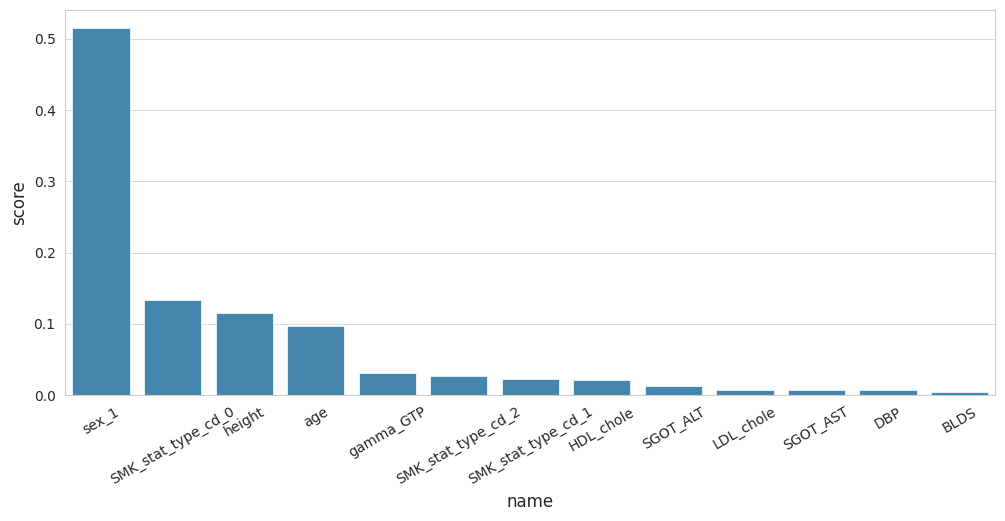

In [ ]:
final_importance= xgb_feature_importances.head(15)
print(final_importance.shape)
plt.figure(figsize=(12,5))
ax=sns.barplot(x=final_importance.name, y= final_importance.score)
ax.set_xticklabels(ax.get_xticklabels(),rotation = 30)

plt.show()

### Prueba 4: HalvingGridSearchCV

In [ ]:
#Creamos el modelo
t = xgboost.XGBClassifier(objective='binary:logistic',seed=42)#,max_depth=6, learning_rate=0.01)

# Creamos la grilla para el Gridsearch
#par = list(np.arange(0.0, 1., step=0.05))
cv = StratifiedKFold(n_splits=5, random_state=0, shuffle=True)

# Hyperparameters for GridSearch
param_grid = {'max_depth' : list(np.arange(1, 10, step=1)), #np.arange(2,11,1),
              'n_estimators' : list(np.arange(5, 30, step=5)),
              'learning_rate' : list(np.arange(0, 0.3, step=0.01)),
              'gamma' : list(np.arange(0, 10, step=2))
             }

model = RandomizedSearchCV(estimator=t, param_distributions = param_grid, cv=cv, scoring = 'roc_auc')

In [ ]:
model.fit(train_inputs, train_target)

RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=0, shuffle=True),
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           gamma=None, grow_policy=None,
                                           importanc...
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None,
                                           random_state=None, ...),
                   param_distributions={'gamma': [0, 2, 4, 6, 8],
                                        'learning_rate': [0.0, 0.01, 0.02, 0.03,
                                                          0.04, 0.05, 0.06,
                                                          0.07, 0.08, 0.09, 0.1,
                                                          0.11, 0.12, 0.13,
                                                          0.14, 0.15, 0.16,
                                                          0.17, 0.18, 0.19, 0.2,
                                                          0.21, 0.22, 0.23,
                                                          0.24, 0.25, 0.26,
                                                          0.27, 0.28, 0.29],
                                        'max_depth': [1, 2, 3, 4, 5, 6, 7, 8,
                                                      9],
                                        'n_estimators': [5, 10, 15, 20, 25]},
                   scoring='roc_auc')

In [ ]:
print("Mejores parametros: "+str(model.best_params_))
print("Mejor Score: "+str(model.best_score_)+'\n')

Mejores parametros: {'n_estimators': 15, 'max_depth': 7, 'learning_rate': 0.28, 'gamma': 6}
Mejor Score: 0.7920767876372459



In [ ]:
model.best_params_

{'n_estimators': 15, 'max_depth': 7, 'learning_rate': 0.28, 'gamma': 6}

In [ ]:
#entrenar el XGBoost model
xgb_model = xgboost.XGBClassifier(objective='binary:logistic',seed=42, n_estimators= 15, max_depth= 7, learning_rate= 0.28, gamma= 0)

xgb_model.fit(train_inputs, train_target.squeeze().values)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=0, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.28, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=7, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=15, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [ ]:
# calcular y imprimir los scores del modelo para el top 15 de features
y_train_pred_xgb = xgb_model.predict(train_inputs)
y_test_pred_xgb = xgb_model.predict(test_inputs)

print('XGB accuracy score for train: %.3f: test: %.3f' % (accuracy_score(train_target, y_train_pred_xgb),accuracy_score(test_target, y_test_pred_xgb)))

XGB accuracy score for train: 0.721: test: 0.717


#### Probamos el modelo

In [ ]:
import xgboost as xgb

# Definir los mejores parámetros obtenidos
best_params = {
    'n_estimators': 15,
    'max_depth': 7,
    'learning_rate': 0.28,
    'gamma': 6
}

# Crear el modelo con los mejores parámetros
clf_xgb_best = xgb.XGBClassifier(objective='binary:logistic', seed=42, **best_params)

# Entrenar el modelo con los datos de entrenamiento
clf_xgb_best.fit(train_inputs, train_target)

# Predecir sobre los datos de prueba
predictions = clf_xgb_best.predict(test_inputs)


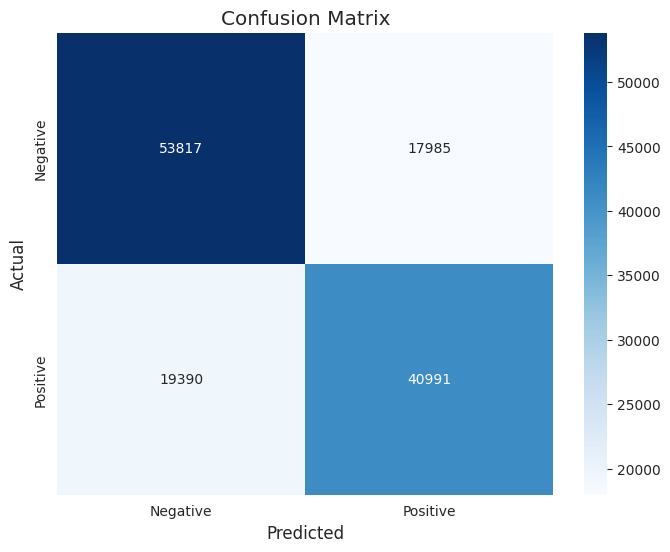

In [ ]:
# Obtener la matriz de confusión
cm_XGB5 = confusion_matrix(test_target, predictions)

# Visualizar la matriz de confusión con seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm_XGB5, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
confusion_matrix(test_target, predictions)

array([[53817, 17985],
       [19390, 40991]])

In [ ]:
accuracy_XGB5=accuracy_score(test_target, predictions)
accuracy_XGB5

0.7172480576170914

In [ ]:
tp,  fp, fn, tn = confusion_matrix(test_target , predictions).ravel()
print("Number of true positives  (tp) = ",tp)
print("Number of true negatives  (tn) = ",tn)

print("Number of false positives (fp) = ",fp)
print("Number of false negatives (fn) = ",fn)

print("Precision                                          = tp / (tp + fp) =", tp / (tp + fp))
print("Recall or 'sensitivity' (aka. true positive rate)  = tp / (tp + fn) =", tp / (tp + fn))
print("Specificity             (aka. true negative rate)  = tn / (tn + fp) =", tn / (tn + fp))
print("Fall out                (aka. false positive rate) = fp / (fp + tn) =", fp / (fp + tn))
print("Miss rate               (aka. false negative rate) = fn / (fn + tp) =", fn / (fn + tp))

Number of true positives  (tp) =  53817
Number of true negatives  (tn) =  40991
Number of false positives (fp) =  17985
Number of false negatives (fn) =  19390
Precision                                          = tp / (tp + fp) = 0.7495195119913094
Recall or 'sensitivity' (aka. true positive rate)  = tp / (tp + fn) = 0.7351346182742088
Specificity             (aka. true negative rate)  = tn / (tn + fp) = 0.6950454422137818
Fall out                (aka. false positive rate) = fp / (fp + tn) = 0.3049545577862181
Miss rate               (aka. false negative rate) = fn / (fn + tp) = 0.26486538172579127


AUC =  0.7143983037867475


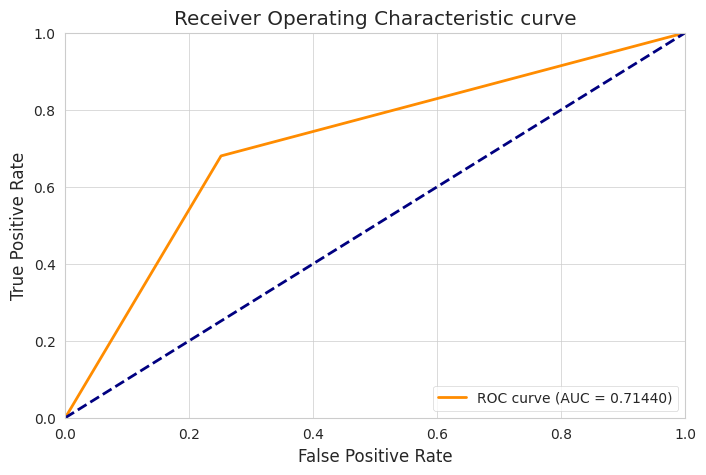

In [ ]:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(test_target , predictions)

from sklearn.metrics import roc_auc_score
roc_auc_XGB5 = roc_auc_score(test_target , predictions)
print("AUC = ", roc_auc_XGB5)

plt.figure(figsize = (8,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (AUC = %0.5f)' % roc_auc_XGB5)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic curve')
plt.legend(loc="lower right")
plt.show()